# [**ĐỀ BÀI 2**](https://docs.google.com/document/d/1M_HPKJwngIMp4RAIH03m-dAEKNRyQOKK/edit)

**Problem statement:**\
Các ngân hàng đều muốn giữ chân khách hàng của mình để duy trì hoạt động kinh doanh và ngân hàng Đa quốc gia ABC cũng muốn điều đó. Dưới đây là dữ liệu khách hàng của các khách hàng tại Ngân hàng Đa quốc gia ABC có phát sinh giao dịch và mục đích của dữ liệu sẽ là dự đoán Tỷ lệ khách hàng rời bỏ.

Giả sử bạn là Data Analyst cho ngân hàng ABC. BOD đang cố gắng tìm hiểu xem *tại sao lại xảy ra vấn đề trên* và liệu người dùng các dịch vụ có rời bỏ ABC hay không (hủy sử dụng dịch vụ) trong vài ngày tới.

**Objective:**\
Bạn được yêu cầu *xây dựng một mô hình dự đoán khách hàng* sẽ rời bỏ hay tiếp tục sử dụng dịch vụ. *Nó sẽ được team Strategy sử dụng* để ước lượng số lượng khách hàng rời bỏ và lên các phương án cải thiện.

[Data dictionary](https://drive.google.com/file/d/1ySPxDLFENLDAPnlXcOChplOLPNPDG1H9/view)


## **Business Understanding**
Xây dựng mô hình phân loại nhị phân để dự đoán xác suất một khách hàng sẽ **hủy sử dụng dịch vụ trong thời gian tới**.
Kết quả sẽ được team Strategy sử dụng để:
- Ước lượng số lượng khách hàng có nguy cơ rời bỏ
- Xác định nhóm ưu tiên cần can thiệp
- Lên phương án giữ chân phù hợp từng phân khúc


| Câu hỏi | Lý do |
|---|---|
| **False Negative nguy hiểm hơn False Positive** | Bỏ sót khách hàng churn = mất doanh thu vĩnh viễn; phân loại nhầm nhưng giữ chân = chỉ tốn chi phí marketing thêm |
| **Metric ưu tiên: Recall + AUC-ROC** | Recall đảm bảo bắt được nhiều churn nhất; AUC-ROC đánh giá khả năng phân biệt tổng thể |
| **Không dùng Accuracy đơn thuần** | Dataset imbalanced (~80/20) — model predict toàn 0 vẫn đạt 80% accuracy |

# **1. Import thư viện và load data**

In [ ]:
# Cài imbalanced-learn (hỗ trợ SMOTE)
!pip install imbalanced-learn --quiet
print("✅ Cài đặt hoàn tất!")

✅ Cài đặt hoàn tất!


In [ ]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# SMOTE — dùng imblearn.pipeline để hỗ trợ resample
from imblearn.over_sampling import SMOTE

# Import thư viện của mô hình dự báo classification cho bài toán
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_recall_curve

# Import permutation importance - đánh giá vai trò của các features
from sklearn.inspection import permutation_importance

# Import clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


In [ ]:
# Load data
link = 'https://drive.google.com/file/d/1Vmvsp_mxgDp1Wi1G64LQ9P9rCpFG70E8/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+link.split('/')[-2]

In [ ]:
df = pd.read_csv(path)
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **2. Data preprocessing / EDA**

## **2.1 Data understanding**

### a. Xem data sample

In [ ]:
# Xem data sample
print(f"📐 Kích thước dataset: {df.shape[0]:,} hàng × {df.shape[1]} cột")
df.sample(5)

📐 Kích thước dataset: 10,000 hàng × 12 cột


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
1878,15641043,648,Spain,Male,35,7,0.00,2,1,1,78436.36,0
5433,15641575,577,France,Male,37,2,127261.35,1,1,0,56185.05,0
7148,15598802,770,Spain,Male,30,8,0.00,2,0,1,50839.85,0
5778,15640377,526,France,Female,36,0,0.00,2,1,0,97767.63,0
6929,15651627,628,Germany,Male,39,1,115341.19,1,1,1,107674.30,1


### b. Check shape, data types, missing values

In [ ]:
# Check shape, dtypes, missing values
df.info()
    ## Nhận xét: dataset không có missing values, wrong datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


### c. Xem thống kê mô tả tập dữ liệu

In [ ]:
# Xem thống kê mô tả tập dữ liệu (numerical columns)
df.describe()
    ## Nhận xét: dataset không có wrong data ở các numerical columns (không có giá trị âm; khoảng giá trị hợp lý với thực tế)

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# Xem thống kê mô tả tập dữ liệu (categorical columns)
df.describe(include='object')

,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


### d. Check missing values

In [ ]:
# Kiểm tra missing values
df.isna().sum()
    ## Nhận xét: dataset không có missing values

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


### e. Check duplicated values

In [ ]:
# Kiểm tra duplicated rows
df.duplicated().sum()
    ## Nhận xét: dataset không có duplicated rows

np.int64(0)

### f. Xem outliers in Numerical columns

In [ ]:
# Chọn các cột là numerical
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols

['customer_id',
 'credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn']

In [ ]:
# Loại trừ các cột 'customer_id', 'churn' (target variable), và các cột 'credit_card', 'active_member' (identifiers)
columns_to_exclude = ['customer_id', 'churn', 'credit_card', 'active_member']
numerical_cols = [col for col in numerical_cols if col not in columns_to_exclude]
numerical_cols

['credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'estimated_salary']

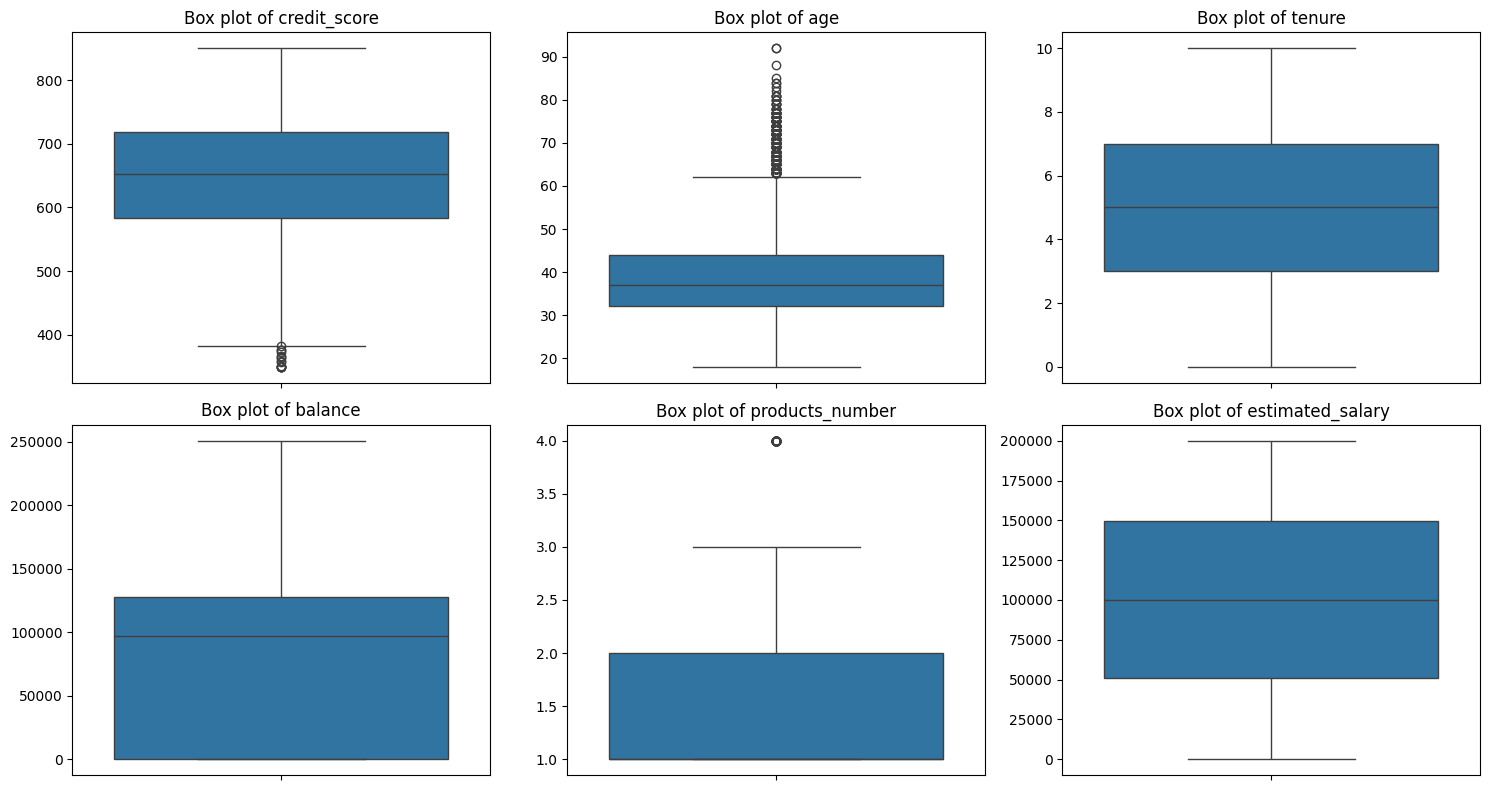

In [ ]:
# Xác định dòng và cột cho chart
num_plot = len(numerical_cols)
num_cols_per_row = 3 # Có thể điều chỉnh được
num_rows = (num_plot + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(num_cols_per_row * 5, num_rows * 4))

# Vẽ chart
for i, col in enumerate(numerical_cols):
  plt.subplot(num_rows, num_cols_per_row, i + 1)
  sns.boxplot(y=df[col])
  plt.title(f'Box plot of {col}')
  plt.ylabel('') # Xóa tên cột y để hạn chế rối grid

plt.tight_layout()
plt.show()
    ## Nhận xét: credit_score, age, products_number có outliers, nhưng khoảng giá trị vẫn hợp lý trên thực tế

### g. Kiểm tra tính unique của cột 'customer_id'

In [ ]:
# Kiểm tra tính unique của cột customer_id
df['customer_id'].nunique() == len(df)
    ## Nhận xét: customer_id consistent

True

### h. Kiểm tra balance vs. churn / active_member vs. churn

In [ ]:
# Kiểm tra balance khi KH rời bỏ
df[(df['churn'] == 1) & (df['balance'] > 0)]
    ## Nhận xét: có 1537 KH rời bỏ nhưng vẫn có balance. Quyết định không drop vì 1. có thể thời điểm capture balance khác với capture churn, 2. mất tính thực tế rằng 'KH có số dư vẫn có thể churn'

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,15737452,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
35,15794171,475,France,Female,45,0,134264.04,1,1,0,27822.99,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9975,15666295,610,Germany,Male,50,1,113957.01,2,1,0,196526.55,1
9981,15672754,498,Germany,Male,42,3,152039.70,1,1,1,53445.17,1
9982,15768163,655,Germany,Female,46,7,137145.12,1,1,0,115146.40,1
9991,15769959,597,France,Female,53,4,88381.21,1,1,0,69384.71,1


In [ ]:
# Kiểm tra active_member và churn
df[(df['churn'] == 1) & (df['active_member'] == 1)]
    ## Nhận xét: tương tự như balance vs. churn, KH có thể vẫn còn hoạt động (active_member = 1) trước khi rời bỏ (churn = 1)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
46,15602280,829,Germany,Female,27,9,112045.67,1,1,1,119708.21,1
47,15771573,637,Germany,Female,39,9,137843.80,1,1,1,117622.80,1
90,15757535,647,Spain,Female,44,5,0.00,3,1,1,174205.22,1
104,15804919,670,Spain,Female,65,1,0.00,1,1,1,177655.68,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9934,15774586,692,Germany,Female,43,10,118588.83,1,1,1,161241.65,1
9947,15732202,615,France,Male,34,1,83503.11,2,1,1,73124.53,1
9960,15681026,795,Germany,Female,33,9,104552.72,1,1,1,120853.83,1
9981,15672754,498,Germany,Male,42,3,152039.70,1,1,1,53445.17,1


### **NHẬN XÉT:**
1.   Tổng quan
- Dataset có 10,000 dòng x 12 cột
2.   Missing values
- Dataset không có missing values
3.   Duplicated rows
- Dataset không có duplicated rows
4.   Outliers
- Các cột có giá trị outliers: credit_score, age, products_number. Cần phân tích đơn biến để rõ hơn sự phân bổ dữ liệu
5.   Consistency
- customer_id unique (primary_key): không có khách hàng bị ghi nhận trùng lặp
6.   Đặc điểm của từng cột dữ liệu

**Categorical features**
- churn (target variable): 2 giá trị: 0-1, 0: không rời bỏ, 1: rời bỏ
- country: ghi nhận KH từ 3 quốc gia: France, Spain, Germany
- gender: 2 giá trị: Female, Male
- credit_card (KH có sở hữu thẻ tín dụng không): 2 giá trị: 0-1, 0: không có sử dụng credit card, 1: có
- active_member (KH có còn hoạt động không): 2 giá trị: 0-1, 0: không còn hoạt động, 1: còn hoạt động

**Numerical features**: không có giá trị âm
- credit_score (điểm tín dụng): range từ 350-850, phù hợp với thang điểm FICO của Mỹ.
- age (tuổi): range từ 18-92, khoảng giá trị hợp lý đối với KH sử dụng dịch vụ ngân hàng
- tenure: rang từ 0-10, khoảng giá trị hợp lý với thời gian sử dụng dịch vụ tại ngân hàng. tenure = 0 đối với những KH mới, chưa sử dụng dịch vụ được 1 năm.
- balance (số dư tài khoản): range từ 0-250,000. Khoảng giá trị hợp lý, số dư = 0 có thể là KH không duy trì số dư hoặc đã rời bỏ dịch vụ
- product_number: range từ 1-4 là hợp lý. Là KH của ngân hàng thì phải sử dụng ít nhất là 1 dịch vụ.
- estimated_salary (lương): range từ 11.58-199,992.48 là hợp lý, độ rộng lớn -> cần phân tích kỹ hơn để đưa ra insights

## **2.3 Univariate analysis**
Vì dataset không có các vấn đề về missing value, duplicated rows, wrong data types nên chuyển sang phân phân tích đơn biến, đa biến

### **Categorical variables**

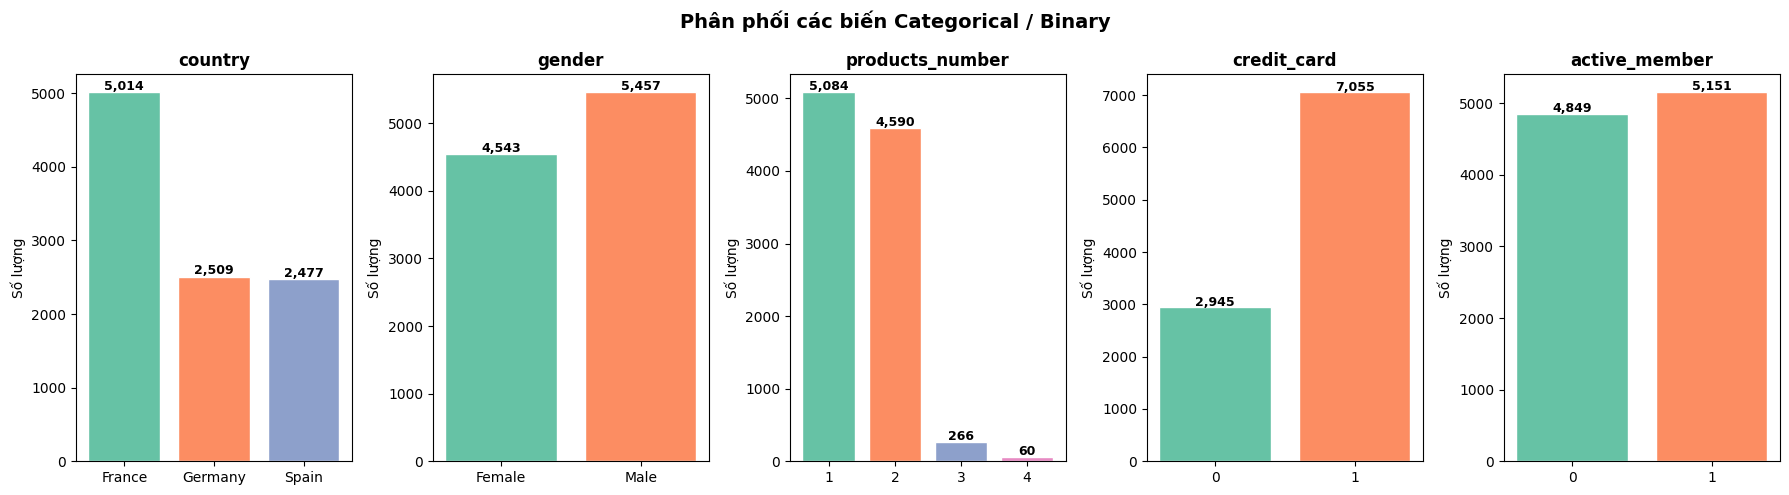

In [ ]:
# Tổng hợp chart phân phối các biến categorical
cat_cols = ['country', 'gender', 'products_number', 'credit_card', 'active_member']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))
fig.suptitle('Phân phối các biến Categorical / Binary', fontsize=14, fontweight='bold')

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=sns.color_palette('Set2', len(counts)),
                edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Số lượng')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 30, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### a. churn (target variable)
- Ở lại (0) - Rời bỏ (1)
- Xác định mức độ mất cân bằng class -> xử lý mất cân bằng như thế nào?

In [ ]:
df.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Xem thống kê của nhóm KH rời bỏ dịch vụ
df[df['churn'] == 1].describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,2.037000e+03,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.0
mean,1.569005e+07,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531,1.0
std,7.269262e+04,100.321503,9.761562,2.936106,58360.794816,0.801521,0.458776,0.480358,57912.418071,0.0
min,1.556571e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,1.0
25%,1.562736e+07,578.000000,38.000000,2.000000,38340.020000,1.000000,0.000000,0.000000,51907.720000,1.0
50%,1.568896e+07,646.000000,45.000000,5.000000,109349.290000,1.000000,1.000000,0.000000,102460.840000,1.0
75%,1.575309e+07,716.000000,51.000000,8.000000,131433.330000,2.000000,1.000000,1.000000,152422.910000,1.0
max,1.581566e+07,850.000000,84.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199808.100000,1.0


In [ ]:
# Tạo df phân tích phân phối target
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Số lượng': churn_counts,
    'Tỷ lệ (%)': churn_pct.round(2)
})

# Set index df churn_summary
churn_summary.index = ['Ở lại (0)', 'Churn (1)']

churn_summary
    ## Nhận xét: có một sự mất cân bằng giữa tỷ lệ ở lại và rời bỏ của KH trong dataset

,Số lượng,Tỷ lệ (%)
Ở lại (0),7963,79.63
Churn (1),2037,20.37


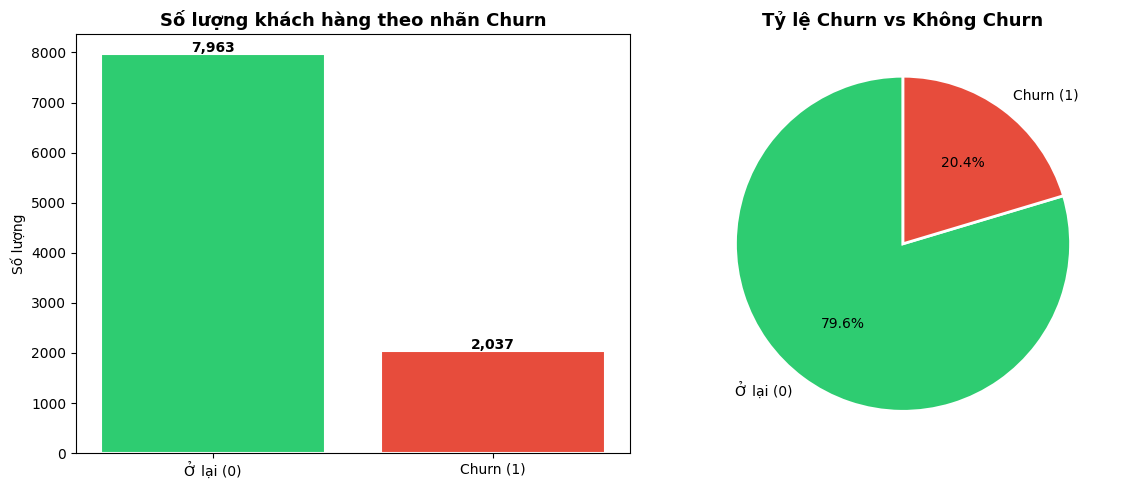

In [ ]:
# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

## Bar chart
axes[0].bar(['Ở lại (0)', 'Churn (1)'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Số lượng khách hàng theo nhãn Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

## Pie chart
axes[1].pie(churn_counts.values, labels=['Ở lại (0)', 'Churn (1)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỷ lệ Churn vs Không Churn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**NHẬN XÉT CHURN (TARGET VARIABLE):**
- Dataset bị mất cân bằng. Chỉ có 20.4% khách hàng churn
- Nếu model predict toàn '0' thì accuracy đơn thuần vẫn đạt 80% -> misleading -> không dùng accuracy làm thang điểm chính

--> Cần dùng SMOTE để cân bằng class trước khi train model

#### b. country

In [ ]:
# Tạo df phân tích phân phối country
country_summary = pd.DataFrame({
    'Số lượng': df['country'].value_counts(),
    'Tỷ lệ (%)': df['country'].value_counts(normalize=True)
})

country_summary
    ## Nhận xét: có sự chênh lệch nhẹ giữa country của KH, France chiếm nhiều nhất, Germany và Spain gần bằng nhau

,Số lượng,Tỷ lệ (%)
country,,
France,5014,0.5014
Germany,2509,0.2509
Spain,2477,0.2477


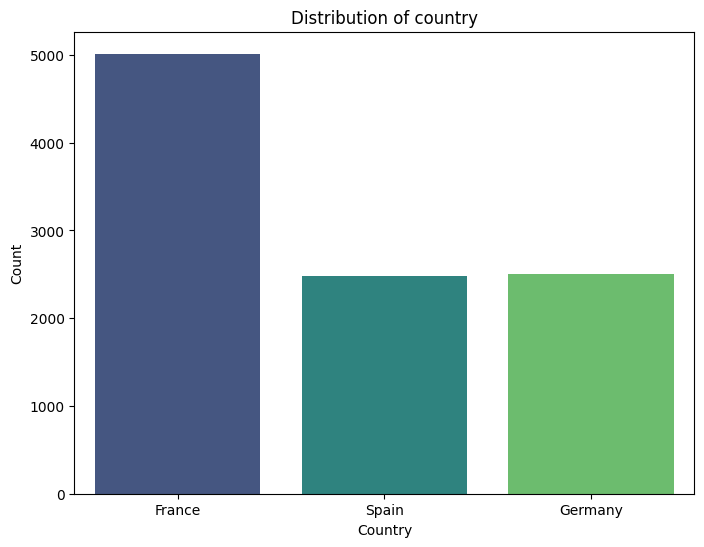

In [ ]:
# Vẽ chart
plt.figure(figsize=(8, 6))
sns.countplot(x='country', data=df, hue='country', legend=False, palette='viridis')
plt.title('Distribution of country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

**NHẬN XÉT COUNTRY:**
- Dataset cho thấy KH chủ yếu đến từ France (50%). Trong khi đó Spain và Germany chỉ chiếm khoảng 25% KH mỗi quốc gia.

#### c. gender

In [ ]:
# Tạo df phân tích phân phối gender
gender_summary = pd.DataFrame({
    'Số lượng': df['gender'].value_counts(),
    'Tỷ lệ (%)': df['gender'].value_counts(normalize=True)
})

gender_summary
    ## Nhận xét: không có sự chênh lệch quá lớn về số lượng KH nam và nữ

,Số lượng,Tỷ lệ (%)
gender,,
Male,5457,0.5457
Female,4543,0.4543


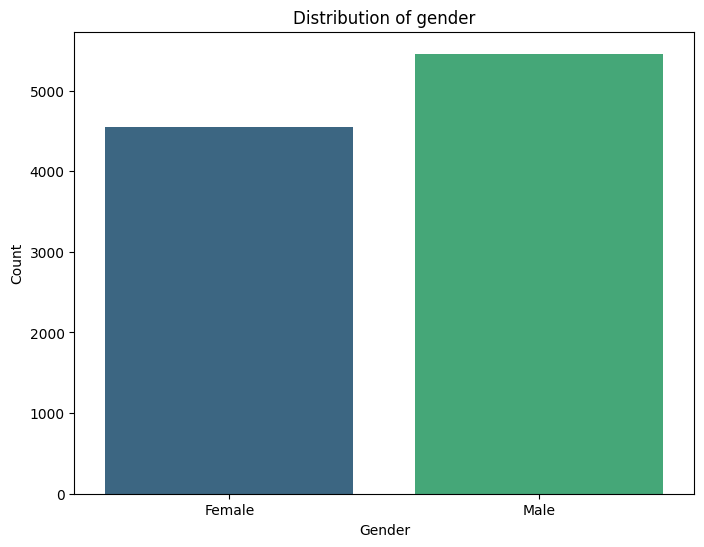

In [ ]:
# Vẽ chart
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', data=df, hue='gender', legend=False, palette='viridis')
plt.title('Distribution of gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

**NHẬN XÉT GENDER:**
- KH Male nhiều hơn Female, nhưng không có sự chênh lệch quá lớn


#### d. credit_card
- 0: không có credit card, 1: có credit card

In [ ]:
# Tạo df phân tích phân phối credit_card
credit_card_summary = pd.DataFrame({
    'Số lượng': df['credit_card'].value_counts(),
    'Tỷ lệ (%)': df['credit_card'].value_counts(normalize=True)
})

credit_card_summary
    ## Nhận xét: có sự chênh lệch lớn giữa việc sở hữu credit card của KH -> cần phân tích kỹ hơn

,Số lượng,Tỷ lệ (%)
credit_card,,
1,7055,0.7055
0,2945,0.2945


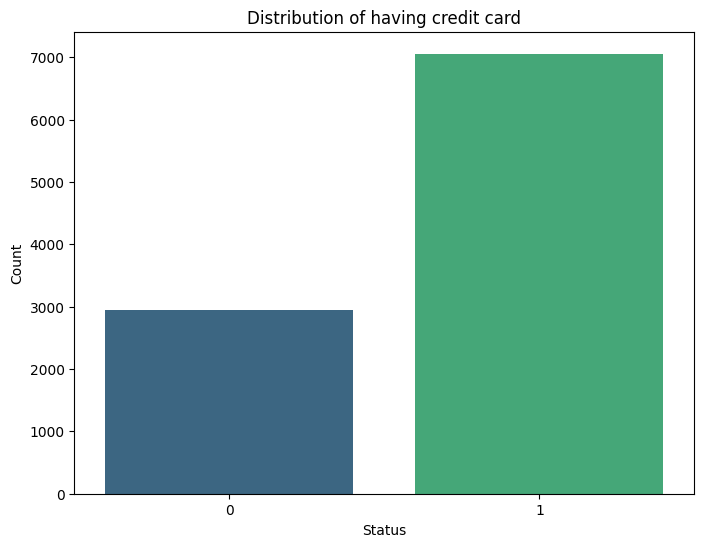

In [ ]:
# Vẽ chart
plt.figure(figsize=(8, 6))
sns.countplot(x='credit_card', data=df, hue='credit_card', legend=False, palette='viridis')
plt.title('Distribution of having credit card')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

**NHẬN XÉT CREDIT_CARD:**
- Dataset cho thấy KH có sở hữu credit card (1) nhiều hơn so với KH không sử dụng card (0). Tỷ lệ 70-30.

-> Cần phân tích đặc điểm này có ảnh hưởng đến kết quả không hay chỉ là đặc điểm thông thường của ngân hàng

#### e. active_member
- 0: không còn hoạt động, 1: hoạt động

In [ ]:
# Tạo df phân tích phân phối active_member
active_member_summary = pd.DataFrame({
    'Số lượng': df['active_member'].value_counts(),
    'Tỷ lệ (%)': df['active_member'].value_counts(normalize=True)
})

active_member_summary
    ## Nhận xét: khá cân bằng giữa hai trạng thái hoạt động của KH

,Số lượng,Tỷ lệ (%)
active_member,,
1,5151,0.5151
0,4849,0.4849


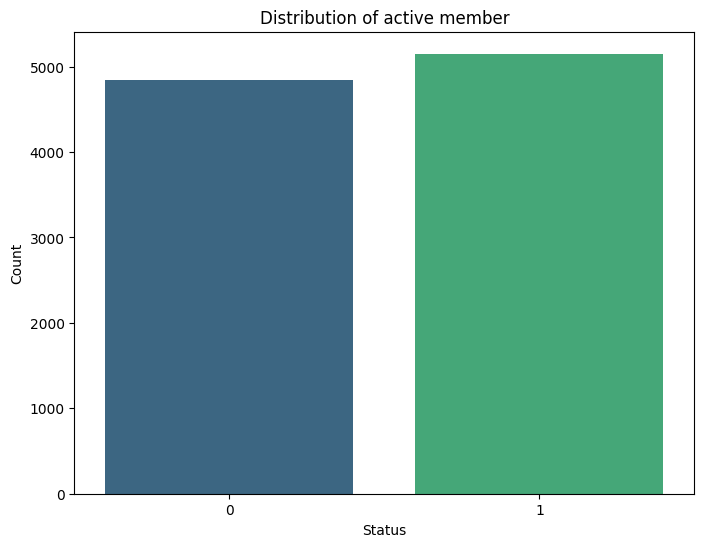

In [ ]:
# Vẽ chart
plt.figure(figsize=(8, 6))
sns.countplot(x='active_member', data=df, hue='active_member', legend=False, palette='viridis')
plt.title('Distribution of active member')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

**NHẬN XÉT ACTIVE_MEMBER**
- Dataset cho thấy phân phối trạng thái hoạt động khá cân bằng (51-49). KH còn hoạt động vẫn nhiều hơn so với KH dừng hoạt động
- Đây là một biến có thể có mức độ ảnh hưởng đến việc KH rời bỏ hay tiếp tục sử dụng dịch vụ (target). -> Cần phân tích đa biến kỹ hơn

#### f. products_number

In [ ]:
# Tạo df phân tích phân phối products_number
products_number_summary = pd.DataFrame({
    'Số lượng': df['products_number'].value_counts(),
    'Tỷ lệ (%)': df['products_number'].value_counts(normalize=True)
})

products_number_summary
    ## Nhận xét: có sự chênh lệch lớn giữa nhóm sử dụng 1-2 với 3-4 sp/dv

,Số lượng,Tỷ lệ (%)
products_number,,
1,5084,0.5084
2,4590,0.4590
3,266,0.0266
4,60,0.0060


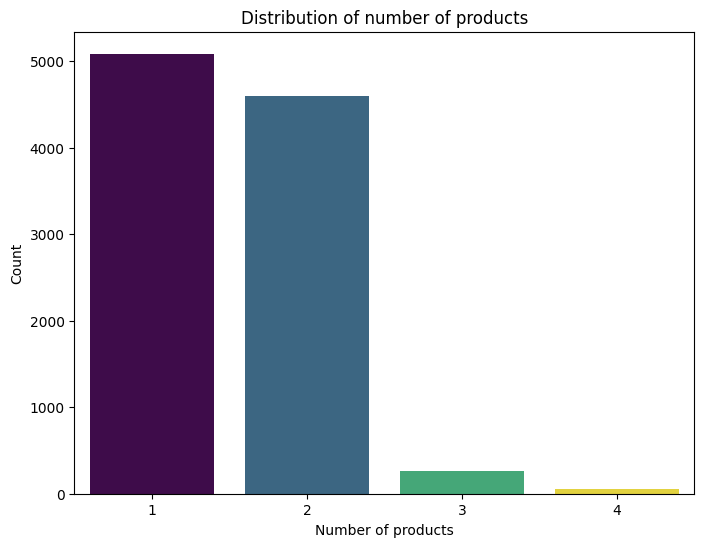

In [ ]:
# Vẽ chart
plt.figure(figsize=(8, 6))
sns.countplot(x='products_number', data=df, hue='products_number', legend=False, palette='viridis')
plt.title('Distribution of number of products')
plt.xlabel('Number of products')
plt.ylabel('Count')
plt.show()

In [ ]:
# Xem các KH sử dụng 3-4 sản phẩm
df[df['products_number'] >= 3].describe()

    ## Nhận xét: Hơn 75% trong 326 KH có xu hướng rời bỏ (churn = 1)

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,3.260000e+02,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000
mean,1.569495e+07,649.113497,43.653374,5.058282,78821.789571,3.184049,0.708589,0.435583,104400.141503,0.858896
std,7.333764e+04,96.200413,10.148108,2.889713,62283.191084,0.388120,0.455111,0.496595,55759.764947,0.348664
min,1.556631e+07,358.000000,21.000000,0.000000,0.000000,3.000000,0.000000,0.000000,3440.470000,0.000000
25%,1.563353e+07,587.250000,37.000000,3.000000,0.000000,3.000000,0.000000,0.000000,64344.800000,1.000000
50%,1.569226e+07,650.000000,43.000000,5.000000,101628.675000,3.000000,1.000000,0.000000,103874.670000,1.000000
75%,1.575770e+07,711.000000,50.000000,8.000000,128743.610000,3.000000,1.000000,1.000000,151150.967500,1.000000
max,1.581549e+07,850.000000,77.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199357.240000,1.000000


**NHẬN XÉT PRODUCTS_NUMBER:**
- Phần lớn KH chỉ sử dụng 1-2 sản phẩm của ngân hàng (95%).
- KH sử dụng 3-4 rất ít (chỉ 5%), phân tích sơ bộ cho thấy nhóm KH này có tỷ lệ rời bỏ dịch vụ rất cao (75%) -> Phân tích kỹ nhóm này trong phân tích đa biến

#### TÓM TẮT NHẬN XÉT TỔNG QUAN CATEGORICAL VARIABLES

**1. churn (target variable)**
- Phân phối: dataset cho thấy khoảng 20% KH rời bỏ dịch vụ (churn = 1), trong khi khoảng 80% vẫn duy trì (churn = 0)
- Nhận xét: Có sự mất cân bằng trong biến target. Cần phải xử lý để hạn chế ảnh hưởng đến kết quả training mô hình

**2. country**
- Phân phối: KH đến từ France nhiều nhất, tiếp sau là Germany rồi đến Spain.
- Nhận xét: Có sự chênh lệch nhẹ trong country của KH có thể ảnh hưởng đến churn rates.

**3. gender**
- Phân phối: Có nhiều KH Male hơn Female trong dataset.
- Nhận xét: Cần phân tích đa biến để xem mức độ ảnh hưởng của gender đến churn rates như thế nào

**4. credit_card**
- Phân phối: Phần lớn KH sở hữu credit card (70%)
- Quan sát: Đặc điểm này có phân phối lệch. Cho thấy đặc điểm phổ biến trong KH của ngân hàng ABC là có sở hữu credit card (Có thể có chương trình khuyến khích KH sử dụng credit card hoặc nhu cầu tự nhiên).

**5. active_member**
- Phân phối: Có nhiều KH còn hoạt động hơn KH ngừng hoạt động (51-49%).
- Quan sát: Đặc điểm này có thể có sự liên quan lớn đến với mục tiêu (KH có rời bỏ hay không).

**6. products_number**
- Phân phối: Phần lớn KH sử dụng 1-2 sản phẩm/dịch vụ (95%). Chỉ một số ít sử dụng hơn 3 sp/dv.
- Quan sát: Điều này cho thấy KH thường giới hạn số lượng sp/dv sử dụng. Và phần lớn những KH sử dụng nhiều sp/dv đã rời bỏ.




### **Numerical variables**

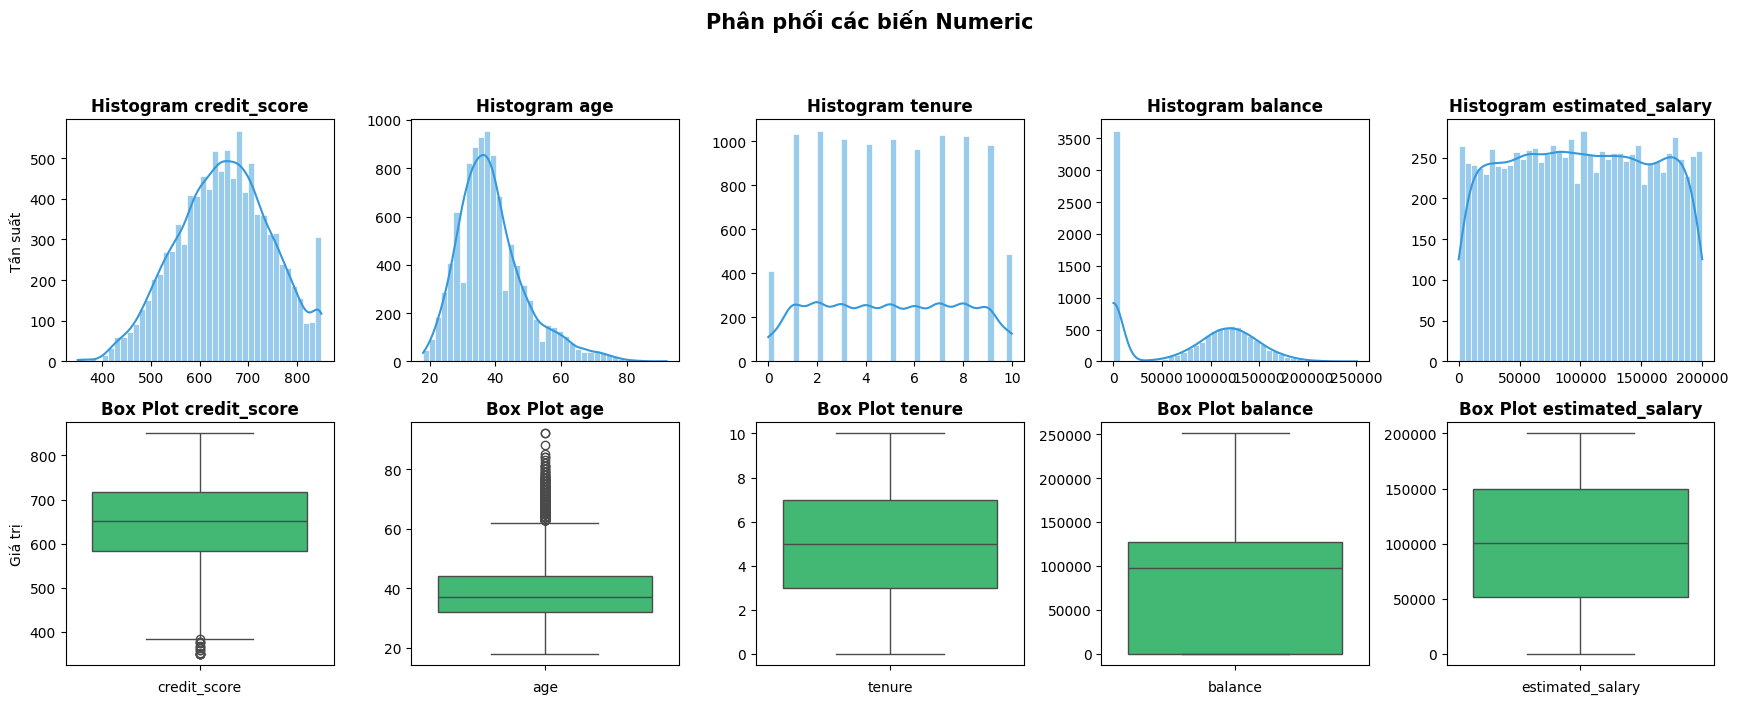

In [ ]:
# Tổng hợp chart phân phối các biến numerical
numeric_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

# User wants 2 rows and 5 columns for presentation.
# Row 0: Histograms, Row 1: Boxplots.
# Adjusted figsize for better visual clarity with 5 columns.
fig, axes = plt.subplots(2, len(numeric_cols), figsize=(len(numeric_cols) * 3.5, 7))
fig.suptitle('Phân phối các biến Numeric', fontsize=15, fontweight='bold', y=1.03) # Adjusted y for suptitle

for i, col in enumerate(numeric_cols):
    # Histogram in the first row
    sns.histplot(df[col], bins=40, kde=True, color='#3498db', edgecolor='white', linewidth=0.5, ax=axes[0, i])
    axes[0, i].set_title(f'Histogram {col}', fontweight='bold')
    axes[0, i].set_xlabel('') # Remove x-label for histograms in the top row
    axes[0, i].set_ylabel('Tần suất' if i == 0 else '') # Only show y-label for the first histogram

    # Box plot in the second row
    sns.boxplot(y=df[col], ax=axes[1, i], color='#2ecc71')
    axes[1, i].set_title(f'Box Plot {col}', fontweight='bold')
    axes[1, i].set_xlabel(col) # Place x-label here for each column
    axes[1, i].set_ylabel('Giá trị' if i == 0 else '') # Only show y-label for the first boxplot

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

#### a. credit_score

In [ ]:
# Xem các chỉ số thống kê cột credit_score
df['credit_score'].describe()
    # Nhận xét: range (350-850) là range của thang điểm FICO Mỹ

,credit_score
count,10000.000000
mean,650.528800
std,96.653299
min,350.000000
25%,584.000000
50%,652.000000
75%,718.000000
max,850.000000


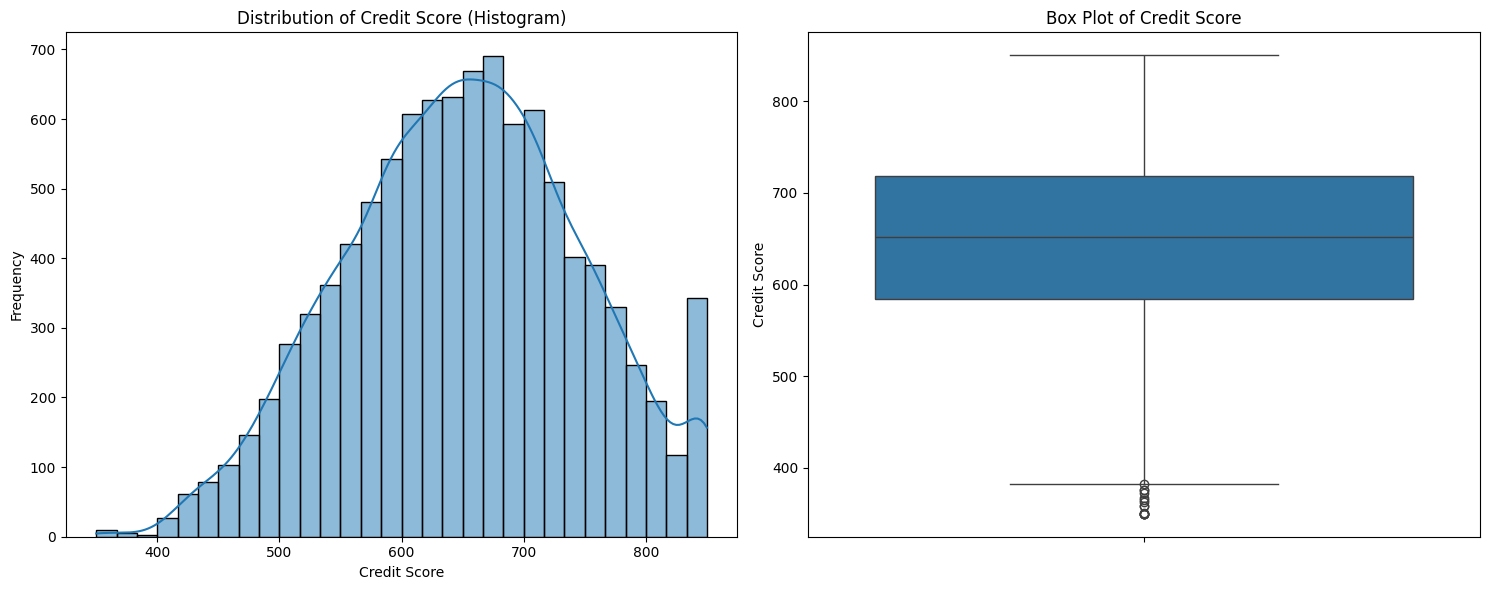

In [ ]:
# Tạo figure và axes để hiển thị 2 biểu đồ trên 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Vẽ Histogram
sns.histplot(df['credit_score'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of Credit Score (Histogram)')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Frequency')

# Vẽ Box Plot
sns.boxplot(y=df['credit_score'], ax=axes[1])
axes[1].set_title('Box Plot of Credit Score')
axes[1].set_xlabel('')
axes[1].set_ylabel('Credit Score')

plt.tight_layout()
plt.show()

In [ ]:
# Kiểm tra các KH có credit_score là outliers dưới
creditscore_Q1 = df['credit_score'].quantile(0.25)
creditscore_Q3 = df['credit_score'].quantile(0.75)
creditscore_IQR = creditscore_Q3 - creditscore_Q1

creditscore_lowerbound = creditscore_Q1 - 1.5*creditscore_IQR

df[df['credit_score'] < creditscore_lowerbound]

## Nhận xét: toàn bộ KH có điểm credit_score < lower bound (376) đều rời bỏ dịch vụ

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,15804586,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,15779947,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1405,15612494,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,15685372,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,15758813,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,15692416,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,15679249,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,15597896,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1
8154,15791533,367,Spain,Male,42,6,93608.28,1,1,0,168816.73,1


**NHẬN XÉT CREDIT_SCORE:**
- credit_score có phạm vi từ 350-850, phù hợp với thang điểm FICO của Mỹ. *Tuy nhiên dataset ghi nhận KH chỉ từ France, Spain, Germany -> có thể ngân hàng ABC có trụ sở ở Tây Âu và sử dụng thang điểm tín dụng của Mỹ; hoặc có trụ sở ở Mỹ và ghi nhận những KH khu vực Tây Âu*.
- Điểm tín dụng phân bổ từ 580-720 -> KH có mức tín dụng tốt.
- credit_score có phân phối gần chuẩn, lệch trái nhẹ.
- Các KH có credit_score thấp hơn lower bound (outlier dưới của credit_score) đều rời bỏ dịch vụ.

**-> credit_score có thể là một trong những đặc điểm có ảnh hưởng đến target.**

#### b. age

In [ ]:
# Xem các chỉ số thống kê cột age
df['age'].describe()
    ## Nhận xét: range 18-92 là thực tế

,age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


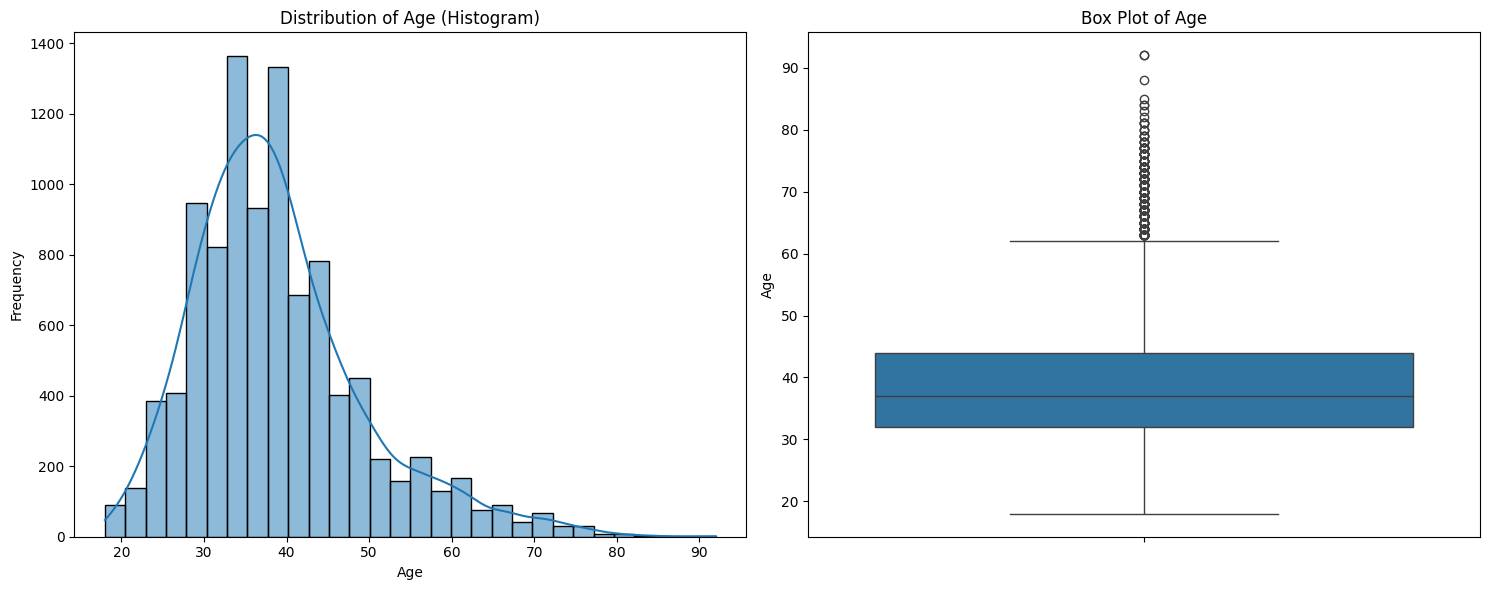

In [ ]:
# Tạo figure và axes để hiển thị 2 biểu đồ trên 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Vẽ Histogram
sns.histplot(df['age'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of Age (Histogram)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Vẽ Box Plot
sns.boxplot(y=df['age'], ax=axes[1])
axes[1].set_title('Box Plot of Age')
axes[1].set_xlabel('')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

In [ ]:
# Kiểm tra các KH có age là outliers trên
age_Q1 = df['age'].quantile(0.25)
age_Q3 = df['age'].quantile(0.75)
age_IQR = age_Q3 - age_Q1

age_upperbound = age_Q3 + 1.5*age_IQR

# Xem thống kê của các KH cao tuổi (outlier trên)
df[df['age'] > age_upperbound].describe()
    ## Nhận xét: Hơn 75% KH cao tuổi chọn ở lại (churn = 0).

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,3.590000e+02,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,1.569174e+07,657.005571,69.270195,4.944290,74477.573649,1.509749,0.713092,0.835655,97883.247354,0.203343
std,7.439883e+04,95.515713,5.237059,2.982671,62335.296038,0.583085,0.452950,0.371106,57499.034723,0.403047
min,1.556669e+07,408.000000,63.000000,0.000000,0.000000,1.000000,0.000000,0.000000,502.700000,0.000000
25%,1.562937e+07,596.000000,65.000000,2.000000,0.000000,1.000000,0.000000,1.000000,49530.100000,0.000000
50%,1.568477e+07,657.000000,68.000000,5.000000,95039.120000,1.000000,1.000000,1.000000,97893.400000,0.000000
75%,1.575990e+07,720.000000,72.000000,8.000000,126389.985000,2.000000,1.000000,1.000000,145873.755000,0.000000
max,1.581563e+07,850.000000,92.000000,10.000000,187013.130000,4.000000,1.000000,1.000000,199493.380000,1.000000


**NHẬN XÉT AGE:**
- age từ 18-92 là hợp lý.
- Phần lớn KH của dataset từ 30-45 tuổi, cho thấy tệp KH của NH chủ yếu là người trẻ và trung niên.
- age có phân phối gần chuẩn, lệch phải nhẹ.
- Có 359 outliers trên, những KH 62 tuổi trở lên. 75% KH lớn tuổi này cho thấy có tỷ lệ ở lại nhiều hơn (churn = 0)

#### c. tenure

In [ ]:
# Xem các chỉ số thống kê cột tenure
df['tenure'].describe()

,tenure
count,10000.000000
mean,5.012800
std,2.892174
min,0.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,10.000000


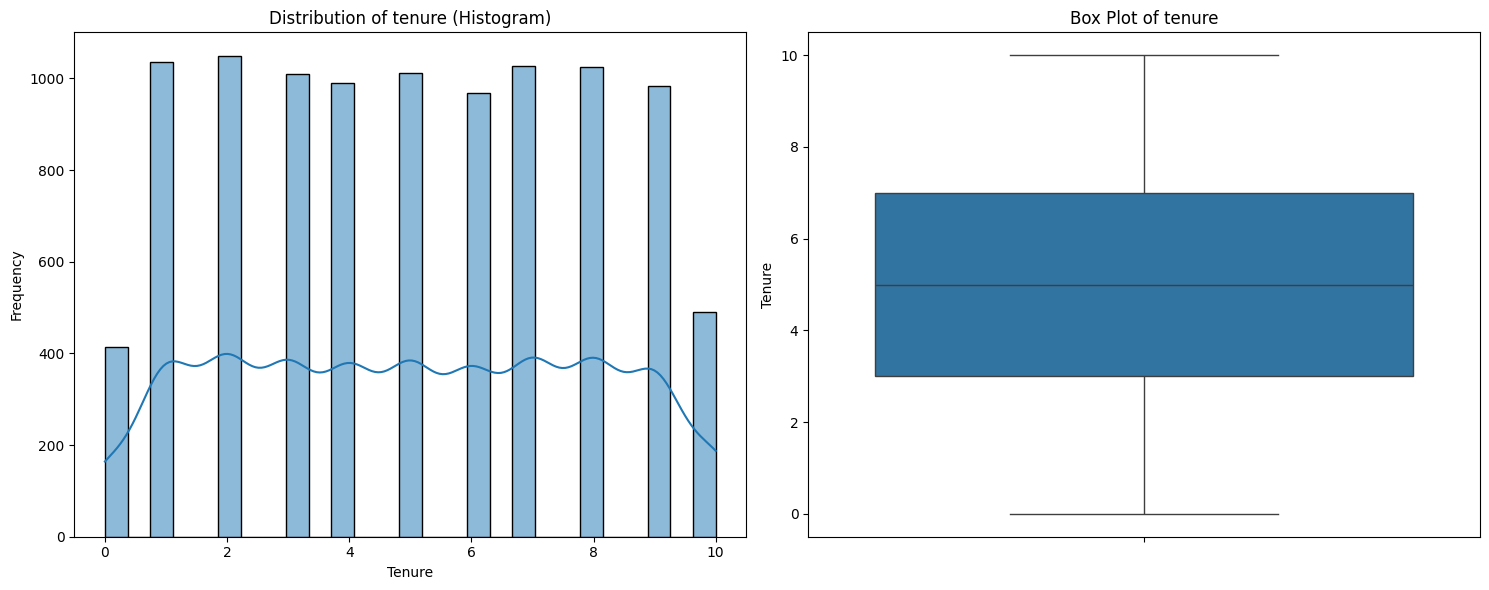

In [ ]:
# Tạo figure và axes để hiển thị 2 biểu đồ trên 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Vẽ Histogram
sns.histplot(df['tenure'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of tenure (Histogram)')
axes[0].set_xlabel('Tenure')
axes[0].set_ylabel('Frequency')

# Vẽ Box Plot
sns.boxplot(y=df['tenure'], ax=axes[1])
axes[1].set_title('Box Plot of tenure')
axes[1].set_xlabel('')
axes[1].set_ylabel('Tenure')

plt.tight_layout()
plt.show()

**NHẬN XÉT TENURE:**
- tenure từ 0-10 hợp lý.
- KH gắn bó chủ yếu từ 3-7 năm, cho thấy tệp KH khá trung thành.
- Phân phối tenure khá đồng đều, ít KH mới (tenure = 0). Không có giá trị outliers

#### d. balance

In [ ]:
# Xem các chỉ số thống kê cột balance
df['balance'].describe()
    ## Nhận xét: khoảng 25% KH trong dataset không duy trì số dư

,balance
count,10000.000000
mean,76485.889288
std,62397.405202
min,0.000000
25%,0.000000
50%,97198.540000
75%,127644.240000
max,250898.090000


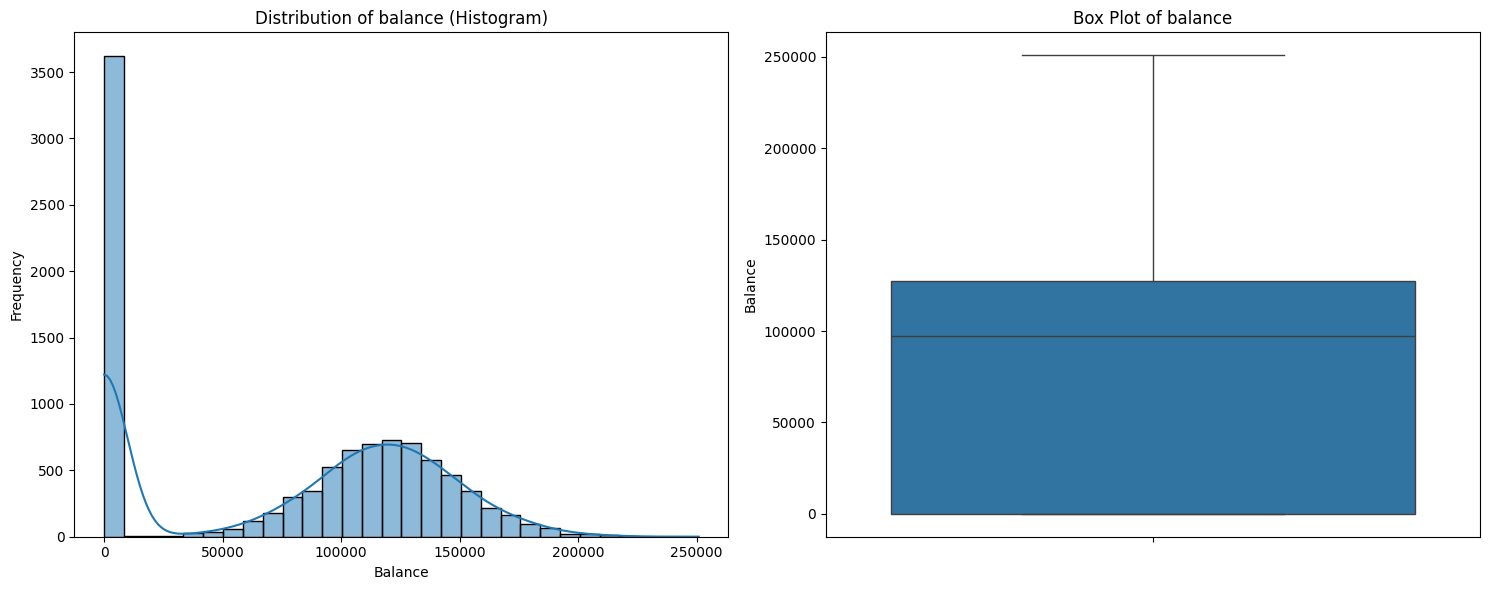

In [ ]:
# Tạo figure và axes để hiển thị 2 biểu đồ trên 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Vẽ Histogram
sns.histplot(df['balance'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of balance (Histogram)')
axes[0].set_xlabel('Balance')
axes[0].set_ylabel('Frequency')

# Vẽ Box Plot
sns.boxplot(y=df['balance'], ax=axes[1])
axes[1].set_title('Box Plot of balance')
axes[1].set_xlabel('')
axes[1].set_ylabel('Balance')

plt.tight_layout()
plt.show()

##### Kiểm tra các khách hàng có balance = 0

In [ ]:
# Xem thống kê các KH có balance = 0
nobalance = df[df['balance'] == 0]

nobalance.describe()
    ## Nhận xét: phân phối các đặc điểm khá giống với tập lớn

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,3.617000e+03,3617.000000,3617.000000,3617.000000,3617.0,3617.000000,3617.000000,3617.000000,3617.000000,3617.000000
mean,1.569195e+07,649.452861,38.434891,5.071330,0.0,1.784628,0.716616,0.517832,98983.559549,0.138236
std,7.194749e+04,96.158798,10.492002,2.860781,0.0,0.496455,0.450704,0.499751,57730.828955,0.345195
min,1.556571e+07,350.000000,18.000000,0.000000,0.0,1.000000,0.000000,0.000000,90.070000,0.000000
25%,1.562952e+07,583.000000,31.000000,3.000000,0.0,1.000000,0.000000,0.000000,49506.820000,0.000000
50%,1.569335e+07,651.000000,37.000000,5.000000,0.0,2.000000,1.000000,1.000000,98618.790000,0.000000
75%,1.575355e+07,717.000000,43.000000,7.000000,0.0,2.000000,1.000000,1.000000,148330.970000,0.000000
max,1.581536e+07,850.000000,88.000000,10.000000,0.0,4.000000,1.000000,1.000000,199992.480000,1.000000


In [ ]:
# Xem thống kê country, gender của nhóm balance = 0
nobalance.describe(include='object')

    ## Nhận xét: trong nhóm balance = 0, KH chỉ đến từ 2 quốc gia

,country,gender
count,3617,3617
unique,2,2
top,France,Male
freq,2418,1963


In [ ]:
# Xem phân bổ quốc gia của KH có balance = 0
nobalance['country'].value_counts()

,count
country,
France,2418
Spain,1199


Xem thống kê churn rate giữa 2 nhóm balance

In [ ]:
# Xem thống kê churn rate của nhóm balance = 0
nobalance['churn'].value_counts()

,count
churn,
0,3117
1,500


In [ ]:
# Xem churn rate giữa 2 nhóm KH
churn_zero = df[df['balance'] == 0]['churn'].mean() * 100
churn_nonzero = df[df['balance'] > 0]['churn'].mean() * 100

print(f"Churn rate khi balance = 0 : {churn_zero:.1f}%")
print(f"Churn rate khi balance > 0 : {churn_nonzero:.1f}%")
    ## Nhận xét: KH có số dư có tỷ lệ rời bỏ cao hơn

Churn rate khi balance = 0 : 13.8%
Churn rate khi balance > 0 : 24.1%


Xem trạng thái hoạt động active_member của các KH này

In [ ]:
# Xem chi tiết số lượng KH active_member theo churn trong df nobalance
nobalance.groupby(['active_member', 'churn']).size().unstack(fill_value=0)

    ## Nhận xét: phần lớn KH có balance = 0 vẫn còn tiếp tục sử dụng dịch vụ (churn = 0). Trong số 500 KH rời bỏ (churn = 1), có 320 KH (64%) ngừng hoạt động.

churn,0,1
active_member,,
0,1424,320
1,1693,180


Xem products_number của các KH có balance = 0

In [ ]:
# Xem products_number của các KH có balance = 0
nobalance['products_number'].value_counts()

,count
products_number,
2,2600
1,905
3,98
4,14


**NHẬN XÉT BALANCE:**
- balance có giá trị từ 0-250k là hợp lý (0 đối với những KH không duy trì/không có số dư trong tài khoản hoặc chỉ sử dụng các dịch vụ khác)
- Phân bổ có 2 đỉnh. Một đỉnh balance = 0 (3617 KH). Những KH còn lại, số dư phân bổ đa dạng và đồng đều, chủ yếu từ 75k-175k.
- Không có outliers.

**Đối với các tài khoản có balance = 0**
- Phân phối các đặc điểm khá giống với dataset lớn.
- Trong đó, không có KH đến từ Germany

#### e. estimated_salary

In [ ]:
# Xem các chỉ số thống kê cột estimated_salary
df['estimated_salary'].describe()

,estimated_salary
count,10000.000000
mean,100090.239881
std,57510.492818
min,11.580000
25%,51002.110000
50%,100193.915000
75%,149388.247500
max,199992.480000


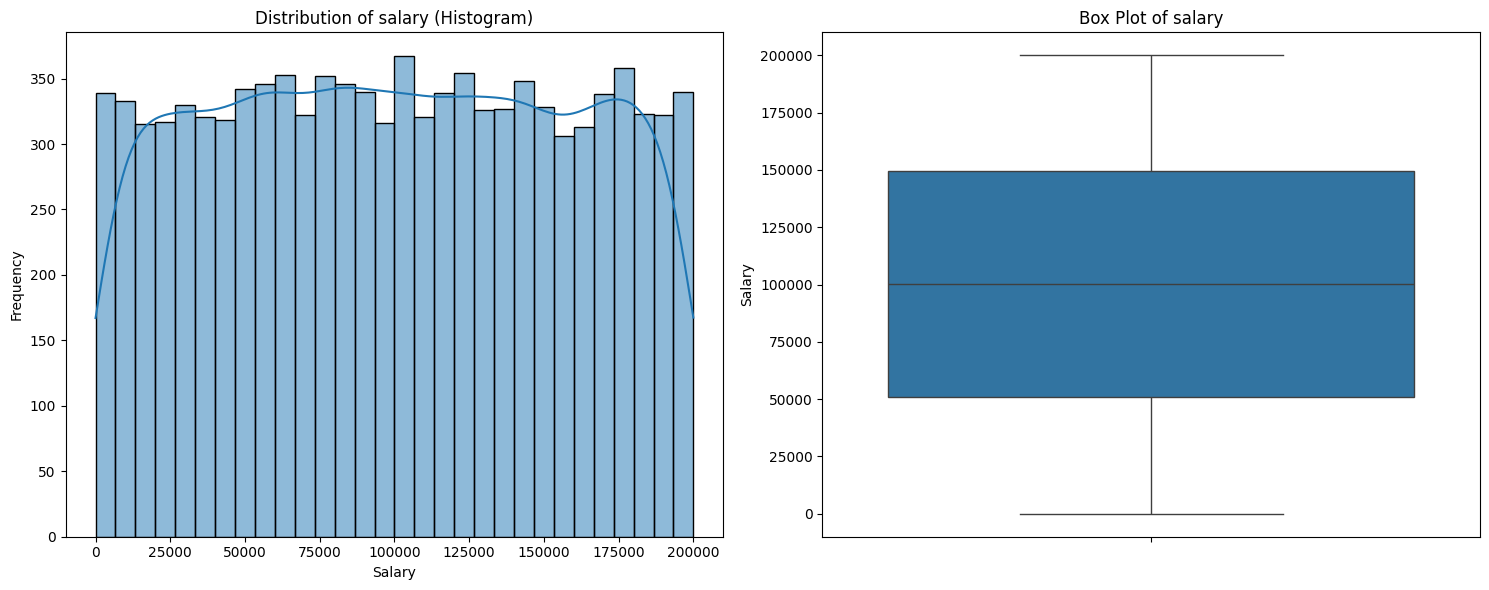

In [ ]:
# Tạo figure và axes để hiển thị 2 biểu đồ trên 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Vẽ Histogram
sns.histplot(df['estimated_salary'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of salary (Histogram)')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

# Vẽ Box Plot
sns.boxplot(y=df['estimated_salary'], ax=axes[1])
axes[1].set_title('Box Plot of salary')
axes[1].set_xlabel('')
axes[1].set_ylabel('Salary')

plt.tight_layout()
plt.show()

**NHẬN XÉT ESTIMATED_SALARY:**
- estimated_salary có giá trị từ 11-200k hợp lý.
- Phân bổ estimated_salary gần dều và phổ IQR khá rộng, cho thấy sự đa dạng về mức thu nhập của các KH, không phụ thuộc vào khoảng nào.
- Không có outliers.

## **2.4 Bivariate analysis**

### Correlation analysis
Chỉ tính những cột numerical

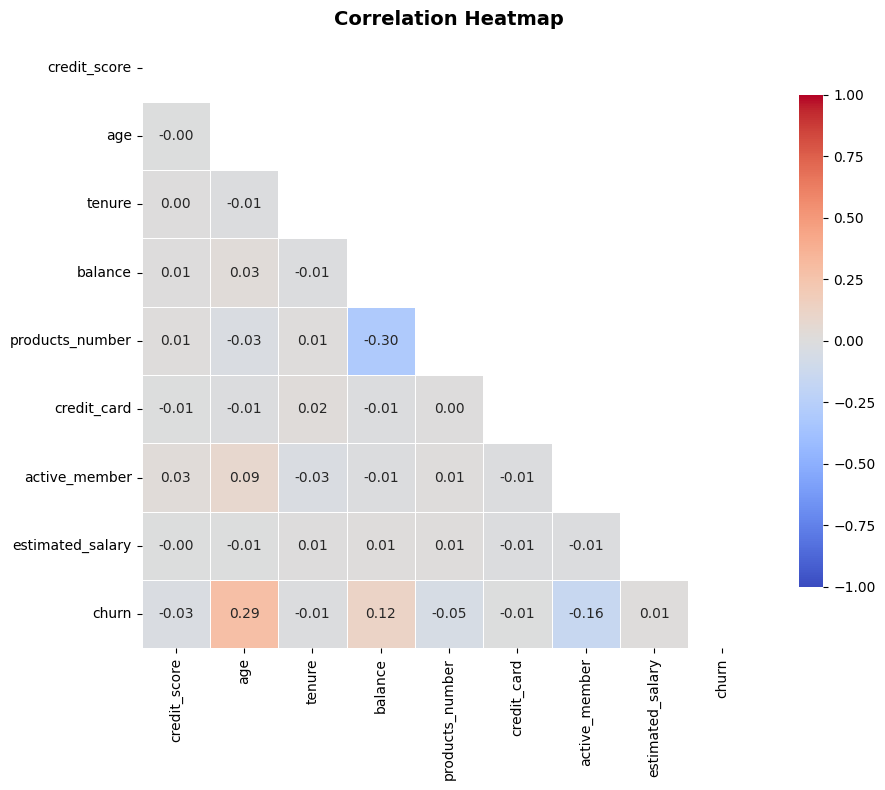

Top features tương quan với churn (theo |correlation|):
age                 0.285323
active_member       0.156128
balance             0.118533
products_number     0.047820
credit_score        0.027094
tenure              0.014001
estimated_salary    0.012097
credit_card         0.007138
Name: churn, dtype: float64


In [ ]:
# Chỉ tính correlation cho numeric (bao gồm target)
numeric_for_corr = ['credit_score', 'age', 'tenure', 'balance',
                    'products_number', 'credit_card', 'active_member',
                    'estimated_salary', 'churn']

corr_matrix = df[numeric_for_corr].corr()

# Vẽ chart
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Ẩn tam giác trên để dễ nhìn
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# In top features tương quan với churn
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
print("Top features tương quan với churn (theo |correlation|):")
print(churn_corr)

**NHẬN XÉT:**
1. không có cặp biến nào tương quan quá cao (>0.8) -> không có multicollinearity nghiêm trọng.

2. age có tương quan với churn nhất (0.29) - KH cao tuổi có xu hướng rời bỏ dịch vụ hơn. Tuy nhiên, khi phân tích đơn biến age, các outliers cho thấy thấy phần lớn KH cao tuổi vẫn tiếp tục sử dụng dịch vụ (churn = 0) -> *CẦN PHÂN TÍCH KỸ HƠN*
3. active_member có tương quan âm với churn (-0.16) - KH không hoạt động (active_member = 0) có xu hướng churn nhiều hơn (churn = 1) -> đúng với giả định ban đầu, đây là yếu tố có thể ảnh hưởng đến kết quả cuối cùng.
4. balance có tương quan với churn (0.12) - KH có số dư càng cao thì có xu hướng rời bỏ dịch vụ. -> *CẦN PHÂN TÍCH KỸ HƠN*
5. product_number có tương quan âm (0.05) - ít tương quan linear, như đã thấy được phi tuyến rõ ràng ở phân tích đơn biến phía trên.

### Categorical variables - Target variable (churn)

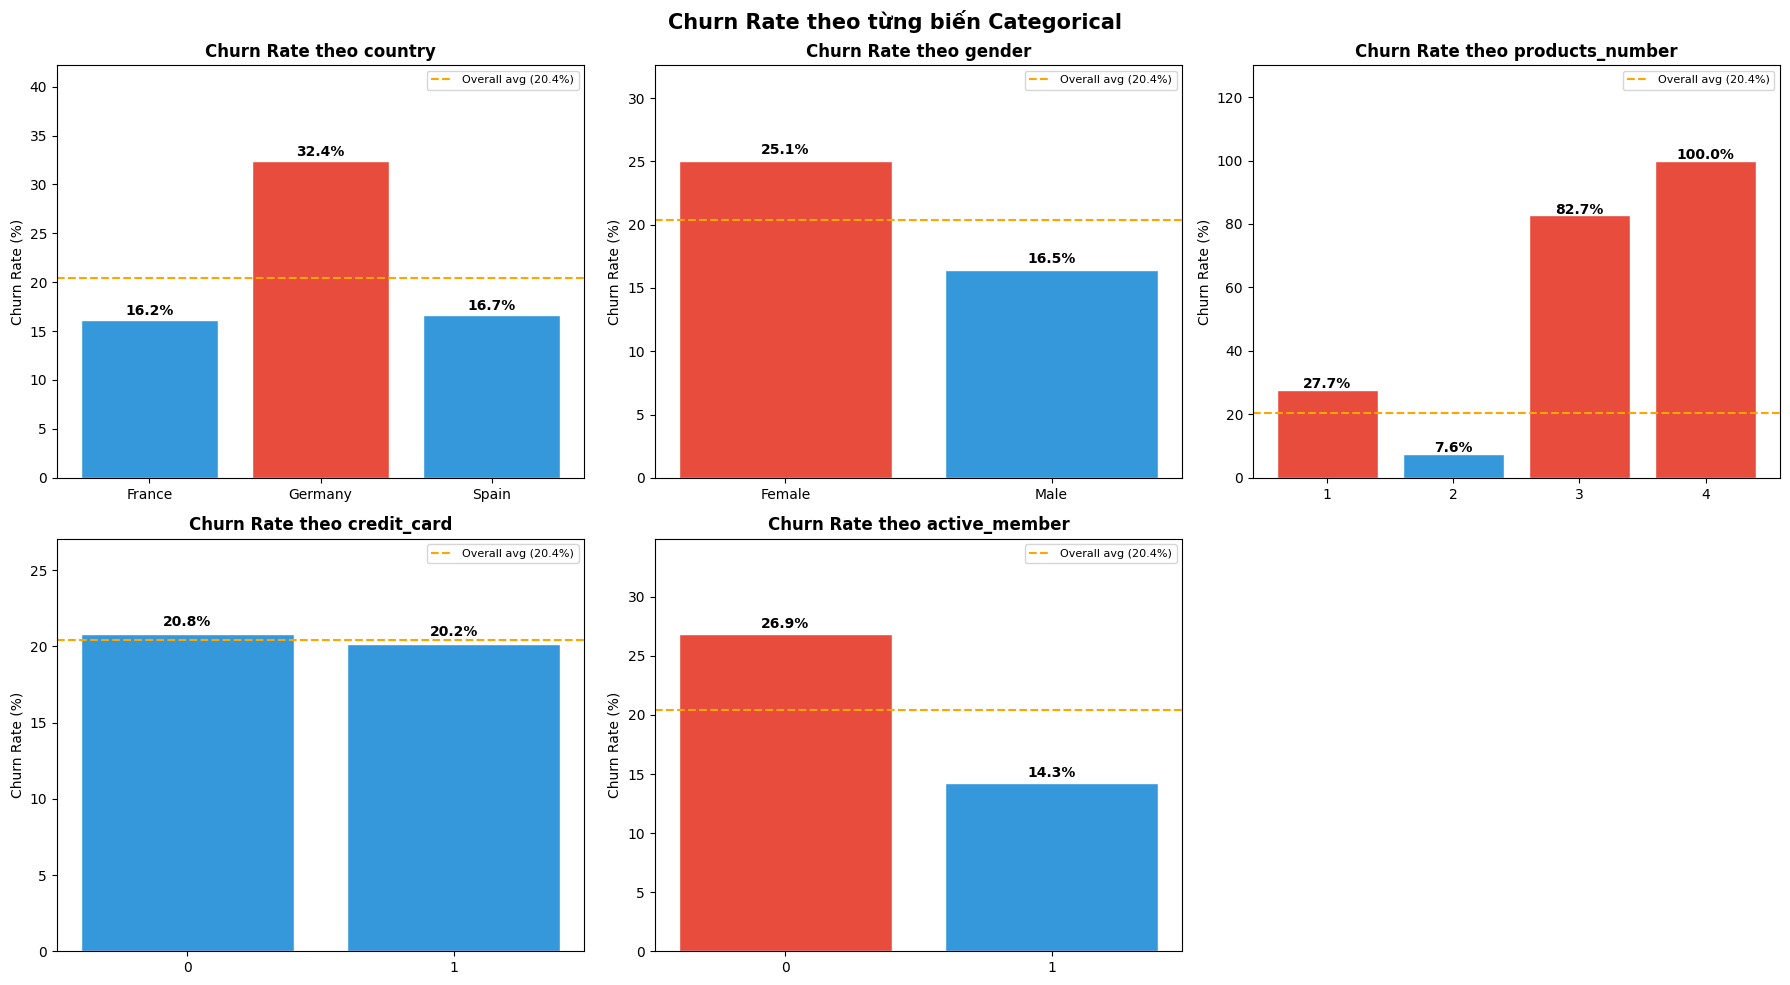

In [ ]:
# Tổng hợp các chart churn rate biến categorical
cat_features = ['country', 'gender', 'products_number', 'credit_card', 'active_member']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Churn Rate theo từng biến Categorical', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['churn'].mean().reset_index()
    churn_rate.columns = [col, 'churn_rate']
    churn_rate['churn_pct'] = churn_rate['churn_rate'] * 100

    bars = axes[i].bar(churn_rate[col].astype(str), churn_rate['churn_pct'],
                       color=['#e74c3c' if v > 25 else '#3498db' for v in churn_rate['churn_pct']],
                       edgecolor='white')
    axes[i].axhline(y=20.4, color='orange', linestyle='--', linewidth=1.5, label='Overall avg (20.4%)')
    axes[i].set_title(f'Churn Rate theo {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, max(churn_rate['churn_pct']) * 1.3)
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, churn_rate['churn_pct']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

#### a. country

In [ ]:
country_summary

,Số lượng,Tỷ lệ (%)
country,,
France,5014,0.5014
Germany,2509,0.2509
Spain,2477,0.2477


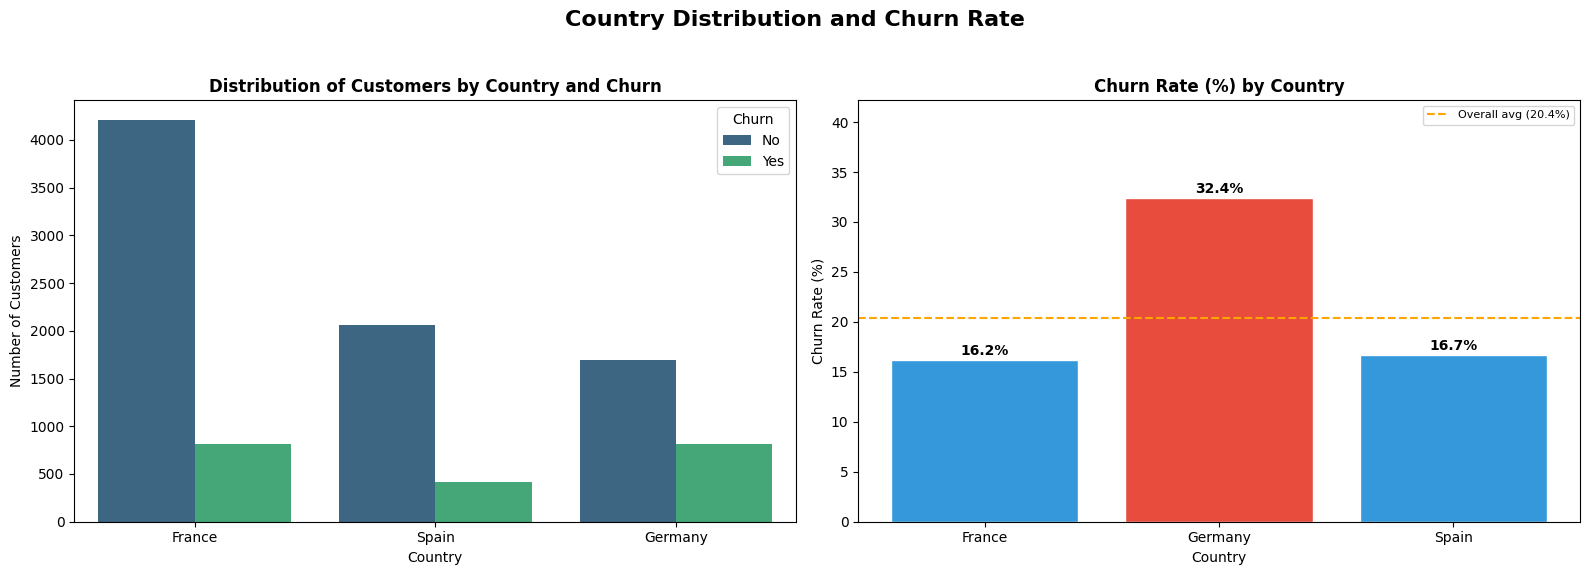

In [ ]:
# Vẽ chart xem phân bổ giá trị và churn rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Country Distribution and Churn Rate', fontsize=16, fontweight='bold')

# Plot 1: Countplot of Country with Churn distribution
sns.countplot(x='country', hue='churn', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Customers by Country and Churn', fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn', labels=['No', 'Yes'])

# Plot 2: Churn Rate by Country
churn_rate_country = df.groupby('country')['churn'].mean().reset_index()
churn_rate_country['churn_pct'] = churn_rate_country['churn'] * 100

bars = axes[1].bar(churn_rate_country['country'], churn_rate_country['churn_pct'],
                   color=['#e74c3c' if v > 20.4 else '#3498db' for v in churn_rate_country['churn_pct']],
                   edgecolor='white')
axes[1].axhline(y=20.4, color='orange', linestyle='--', linewidth=1.5, label='Overall avg (20.4%)')
axes[1].set_title('Churn Rate (%) by Country', fontweight='bold')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, max(churn_rate_country['churn_pct']) * 1.3)
axes[1].legend(fontsize=8)
for bar, val in zip(bars, churn_rate_country['churn_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**NHẬN XÉT:**
- Germany có churn rate = 32.4%, cao gần gấp đôi France (16.2%) và Spain (16.7%) \
-> Có thể thị trường Đức có tính cạnh tranh ngân hàng cao hoặc gặp vấn đề về chất lượng dịch vụ.

#### b. gender


In [ ]:
gender_summary

,Số lượng,Tỷ lệ (%)
gender,,
Male,5457,0.5457
Female,4543,0.4543


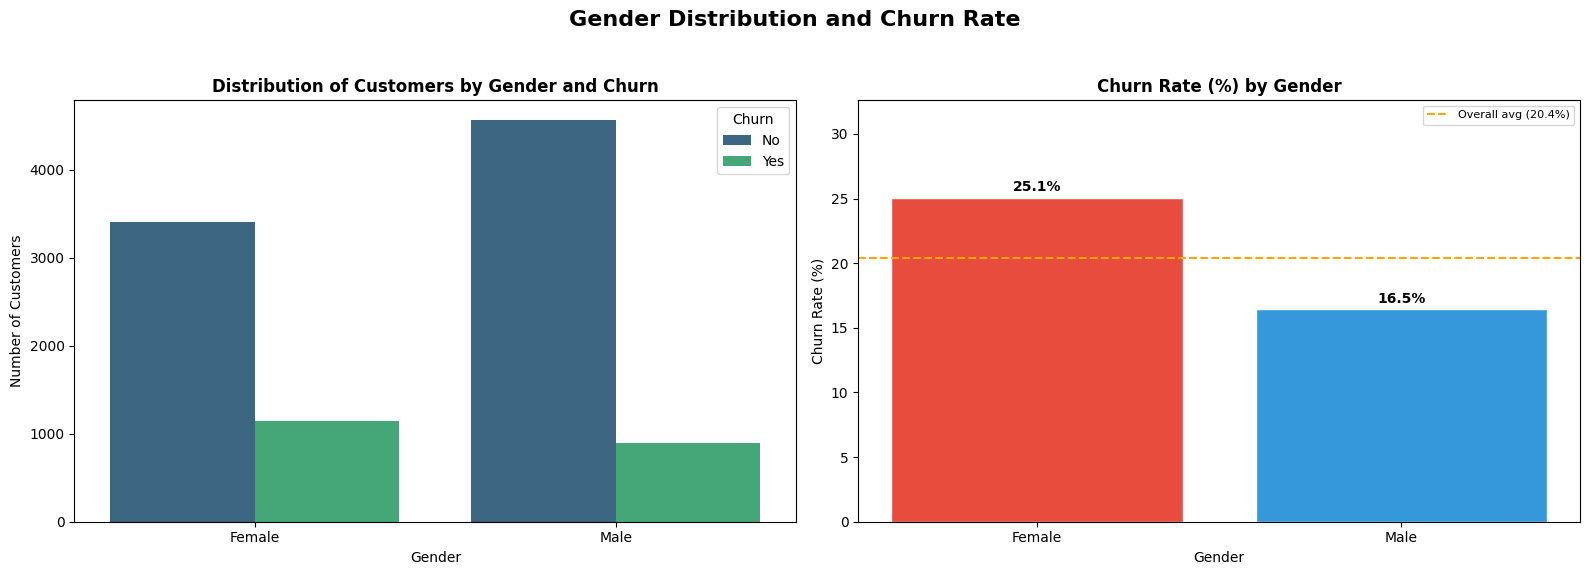

In [ ]:
# Vẽ chart xem phân bổ giá trị và churn rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gender Distribution and Churn Rate', fontsize=16, fontweight='bold')

# Plot 1: Countplot of Gender with Churn distribution
sns.countplot(x='gender', hue='churn', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Customers by Gender and Churn', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn', labels=['No', 'Yes'])

# Plot 2: Churn Rate by Gender
churn_rate_gender = df.groupby('gender')['churn'].mean().reset_index()
churn_rate_gender['churn_pct'] = churn_rate_gender['churn'] * 100

bars = axes[1].bar(churn_rate_gender['gender'], churn_rate_gender['churn_pct'],
                   color=['#e74c3c' if v > 20.4 else '#3498db' for v in churn_rate_gender['churn_pct']],
                   edgecolor='white')
axes[1].axhline(y=20.4, color='orange', linestyle='--', linewidth=1.5, label='Overall avg (20.4%)')
axes[1].set_title('Churn Rate (%) by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, max(churn_rate_gender['churn_pct']) * 1.3)
axes[1].legend(fontsize=8)
for bar, val in zip(bars, churn_rate_gender['churn_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**NHẬN XÉT:**
- Female (churn rate = 25.1%)có churn rate cao hơn so với Male (16.5) trong khi số lượng KH Male nhiều hơn

#### c. credit_card

In [ ]:
credit_card_summary

,Số lượng,Tỷ lệ (%)
credit_card,,
1,7055,0.7055
0,2945,0.2945


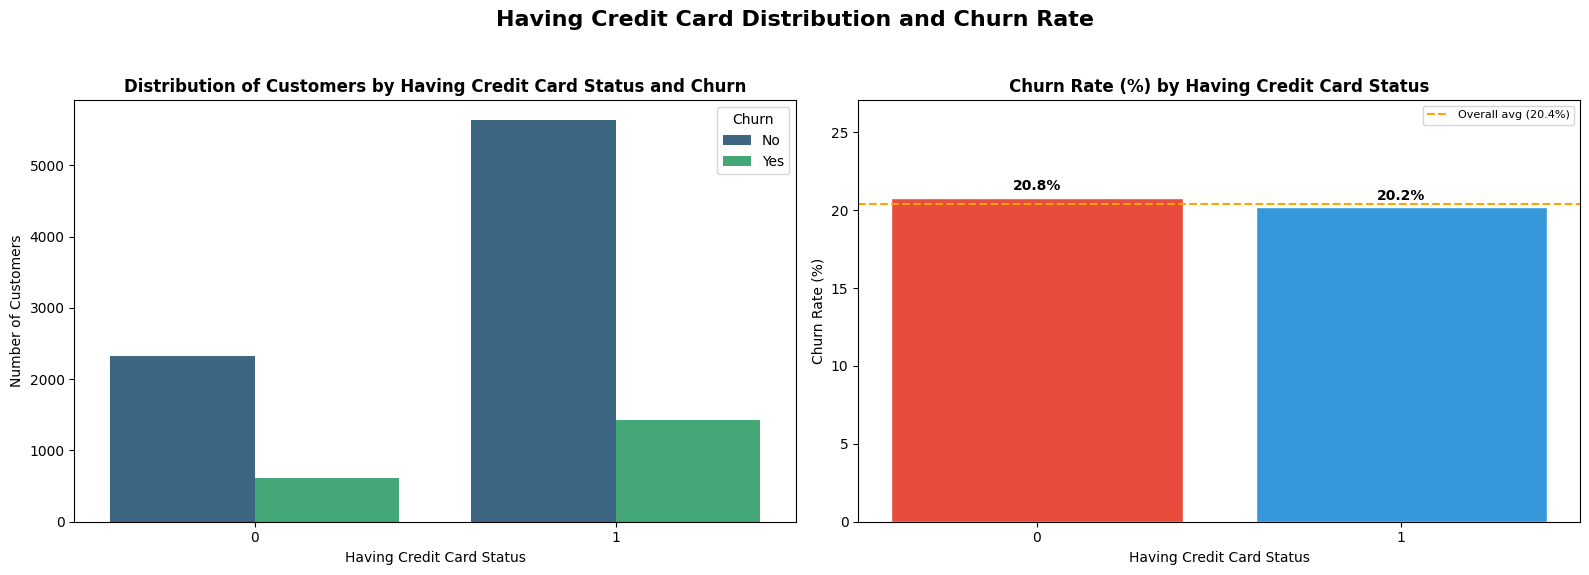

In [ ]:
# Vẽ chart xem phân bổ giá trị và churn rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Having Credit Card Distribution and Churn Rate', fontsize=16, fontweight='bold')

# Plot 1: Countplot of Having Credit Card with Churn distribution
sns.countplot(x='credit_card', hue='churn', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Customers by Having Credit Card Status and Churn', fontweight='bold')
axes[0].set_xlabel('Having Credit Card Status')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn', labels=['No', 'Yes'])

# Plot 2: Churn Rate by Having Credit Card Status
churn_rate_credit_card = df.groupby('credit_card')['churn'].mean().reset_index()
churn_rate_credit_card['churn_pct'] = churn_rate_credit_card['churn'] * 100

bars = axes[1].bar(churn_rate_credit_card['credit_card'].astype(str), churn_rate_credit_card['churn_pct'],
                   color=['#e74c3c' if v > 20.4 else '#3498db' for v in churn_rate_credit_card['churn_pct']],
                   edgecolor='white')
axes[1].axhline(y=20.4, color='orange', linestyle='--', linewidth=1.5, label='Overall avg (20.4%)')
axes[1].set_title('Churn Rate (%) by Having Credit Card Status', fontweight='bold')
axes[1].set_xlabel('Having Credit Card Status')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, max(churn_rate_credit_card['churn_pct']) * 1.3)
axes[1].legend(fontsize=8)
for bar, val in zip(bars, churn_rate_credit_card['churn_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**NHẬN XÉT:**
- Không có sự chênh lệch về churn rate giữa việc sở hữu credit card của KH. --> Khẳng định rõ hơn đây có thể chỉ là một đặc điểm phổ biến của KH ngân hàng ABC.

#### d. active_member

In [ ]:
active_member_summary

,Số lượng,Tỷ lệ (%)
active_member,,
1,5151,0.5151
0,4849,0.4849


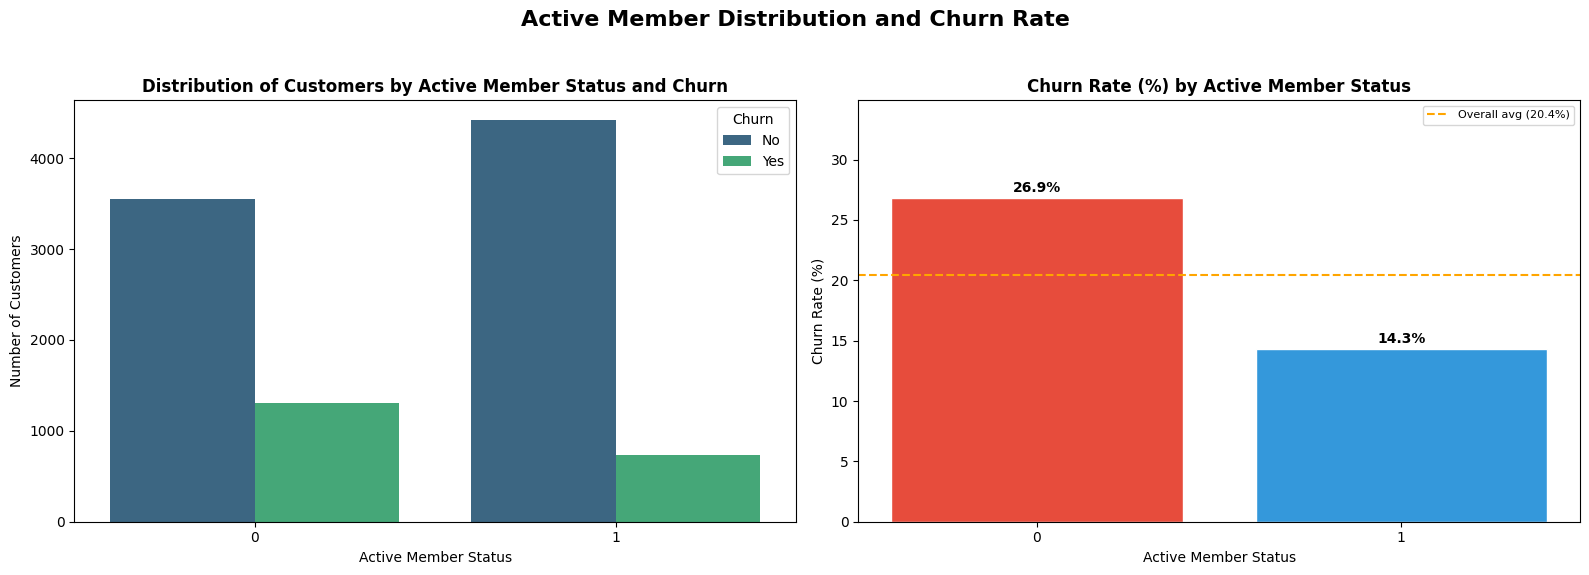

In [ ]:
# Vẽ chart xem phân bổ giá trị và churn rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Active Member Distribution and Churn Rate', fontsize=16, fontweight='bold')

# Plot 1: Countplot of Active Member with Churn distribution
sns.countplot(x='active_member', hue='churn', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Customers by Active Member Status and Churn', fontweight='bold')
axes[0].set_xlabel('Active Member Status')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn', labels=['No', 'Yes'])

# Plot 2: Churn Rate by Active Member Status
churn_rate_active_member = df.groupby('active_member')['churn'].mean().reset_index()
churn_rate_active_member['churn_pct'] = churn_rate_active_member['churn'] * 100

bars = axes[1].bar(churn_rate_active_member['active_member'].astype(str), churn_rate_active_member['churn_pct'],
                   color=['#e74c3c' if v > 20.4 else '#3498db' for v in churn_rate_active_member['churn_pct']],
                   edgecolor='white')
axes[1].axhline(y=20.4, color='orange', linestyle='--', linewidth=1.5, label='Overall avg (20.4%)')
axes[1].set_title('Churn Rate (%) by Active Member Status', fontweight='bold')
axes[1].set_xlabel('Active Member Status')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, max(churn_rate_active_member['churn_pct']) * 1.3)
axes[1].legend(fontsize=8)
for bar, val in zip(bars, churn_rate_active_member['churn_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**NHẬN XÉT:**
- KH ngừng hoạt động (active_member = 0) có churn rate cao hơn (churn rate = 26.9%) so với KH còn hoạt động  (14.3%)

#### e. products_number

In [ ]:
products_number_summary

,Số lượng,Tỷ lệ (%)
products_number,,
1,5084,0.5084
2,4590,0.4590
3,266,0.0266
4,60,0.0060


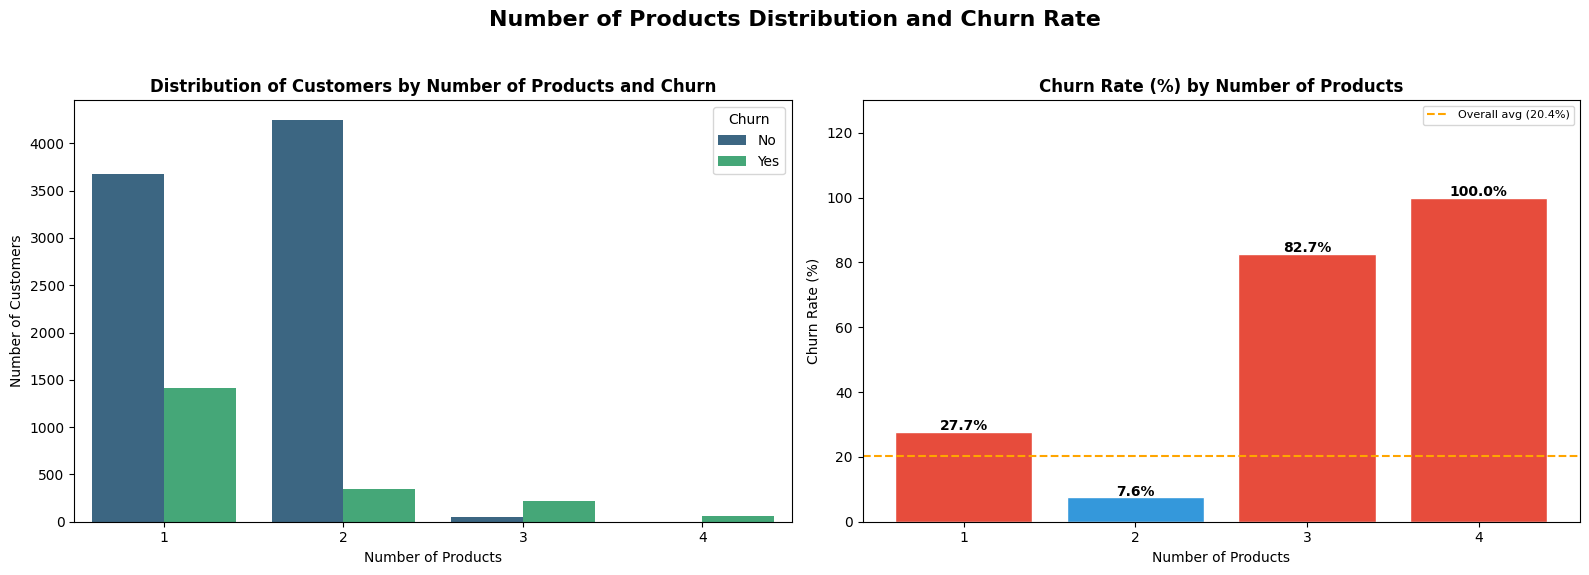

In [ ]:
# Vẽ chart xem phân bổ giá trị và churn rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Number of Products Distribution and Churn Rate', fontsize=16, fontweight='bold')

# Plot 1: Countplot of Active Member with Churn distribution
sns.countplot(x='products_number', hue='churn', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Customers by Number of Products and Churn', fontweight='bold')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn', labels=['No', 'Yes'])

# Plot 2: Churn Rate by Active Member Status
churn_rate_products_number = df.groupby('products_number')['churn'].mean().reset_index()
churn_rate_products_number['churn_pct'] = churn_rate_products_number['churn'] * 100

bars = axes[1].bar(churn_rate_products_number['products_number'].astype(str), churn_rate_products_number['churn_pct'],
                   color=['#e74c3c' if v > 20.4 else '#3498db' for v in churn_rate_products_number['churn_pct']],
                   edgecolor='white')
axes[1].axhline(y=20.4, color='orange', linestyle='--', linewidth=1.5, label='Overall avg (20.4%)')
axes[1].set_title('Churn Rate (%) by Number of Products', fontweight='bold')
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, max(churn_rate_products_number['churn_pct']) * 1.3)
axes[1].legend(fontsize=8)
for bar, val in zip(bars, churn_rate_products_number['churn_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Tìm hiểu sự chênh lệch về churn rate của việc sử dụng 1 và 2 sp/dv**

**NHẬN XÉT:**
- Không có sự chênh lệch nhiều giữa các đặc điểm của 2 nhóm KH.
- Những nhóm KH sử dụng 1 sp/dv thì có độ tuổi cao hơn; và có balance cao hơn. Mà theo correlation matrix, những KH có độ tuổi cao hơn và có balance cao hơn thì có xu hướng rời bỏ

In [ ]:
# Xem thống kê các KH rời bỏ chỉ sử dụng 1 sp/dv
df[(df['products_number'] == 1) & (df['churn'] == 1)].describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.409000e+03,1409.000000,1409.000000,1409.000000,1409.000000,1409.0,1409.000000,1409.000000,1409.000000,1409.0
mean,1.568970e+07,645.716111,44.910575,4.905607,92028.819787,1.0,0.703336,0.344216,100639.827566,1.0
std,7.281630e+04,101.453074,9.642426,2.938823,58077.936738,0.0,0.456949,0.475281,58678.051735,0.0
min,1.556571e+07,350.000000,18.000000,0.000000,0.000000,1.0,0.000000,0.000000,11.580000,1.0
25%,1.562679e+07,576.000000,38.000000,2.000000,45472.280000,1.0,0.000000,0.000000,49833.500000,1.0
50%,1.568933e+07,647.000000,45.000000,5.000000,110022.740000,1.0,1.000000,0.000000,101108.850000,1.0
75%,1.575175e+07,718.000000,51.000000,7.000000,132217.450000,1.0,1.000000,1.000000,152167.790000,1.0
max,1.581566e+07,850.000000,84.000000,10.000000,238387.560000,1.0,1.000000,1.000000,199808.100000,1.0


In [ ]:
# Xem thống kê các KH rời bỏ sử dụng 2 sp/dv
df[(df['products_number'] == 2) & (df['churn'] == 1)].describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,3.480000e+02,348.000000,348.000000,348.000000,348.000000,348.0,348.000000,348.000000,348.000000,348.0
mean,1.568909e+07,643.614943,44.658046,4.913793,90252.357155,2.0,0.678161,0.390805,100883.308879,1.0
std,7.259540e+04,96.915579,10.453452,2.953732,58578.202498,0.0,0.467854,0.488633,56039.921315,0.0
min,1.556671e+07,350.000000,18.000000,0.000000,0.000000,2.0,0.000000,0.000000,91.750000,1.0
25%,1.563093e+07,583.250000,37.000000,2.000000,26115.135000,2.0,0.000000,0.000000,51731.097500,1.0
50%,1.568735e+07,645.000000,44.000000,5.000000,109006.295000,2.0,1.000000,0.000000,101341.900000,1.0
75%,1.575288e+07,716.250000,51.000000,7.000000,129078.572500,2.0,1.000000,1.000000,150344.492500,1.0
max,1.581563e+07,850.000000,74.000000,10.000000,210433.080000,2.0,1.000000,1.000000,197297.770000,1.0


**NHẬN XÉT:**
- products_number = (3,4) có churn rate cực cao (> 80%) -> Dấu hiệu bất thường, cần lưu ý. Nguyên nhân có thể là do họ bị bắt sử dụng những sản phẩm bắt buộc của bank, dẫn tới không còn cảm thấy hài lòng và từ bỏ dịch vụ.
- products_number = 1 (churn rate = 27.7%), cao hơn nhiều so với products_number = 2 (churn rate = 7.6%) -> Nguyên nhân? Có thể chỉ sử dụng 1 sản phẩm khiến KH không có sự gắn bó chặt chẽ, nên dễ rời bỏ hơn so với KH sử dụng 2 dịch vụ.

### Numerical variables - Target variable (churn)

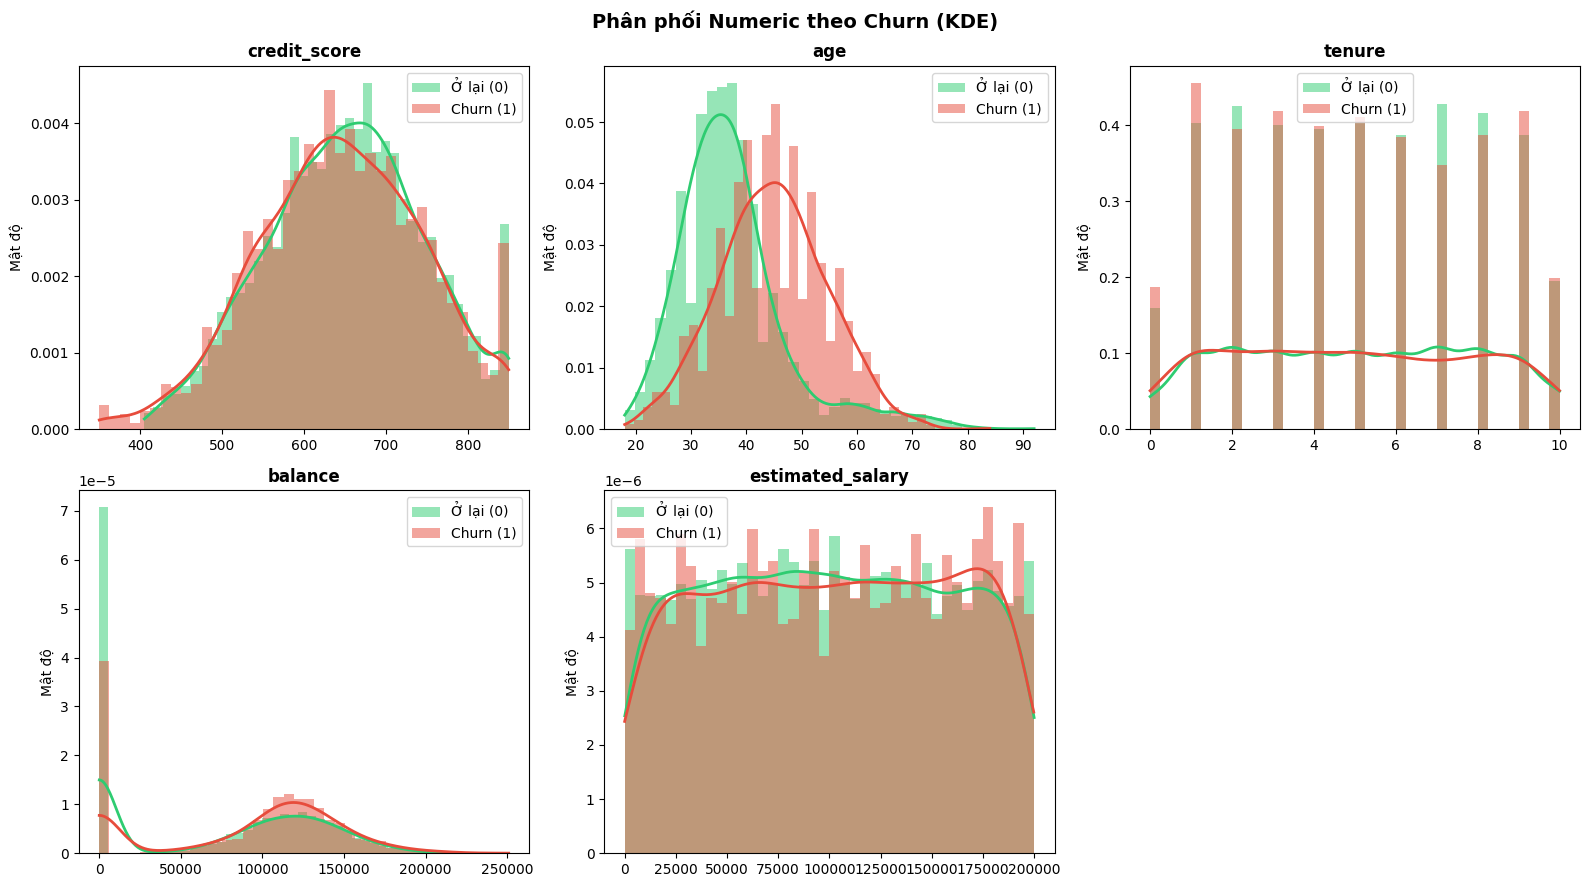

In [ ]:
# Tổng hợp các chart phân tích churn rate biến numeric
numeric_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Phân phối Numeric theo Churn (KDE)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color, name in [(0, '#2ecc71', 'Ở lại (0)'), (1, '#e74c3c', 'Churn (1)')]:
        data = df[df['churn'] == label][col]
        axes[i].hist(data, bins=40, density=True, alpha=0.5, color=color, label=name, edgecolor='none')
        # Vẽ thêm đường KDE
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 300)
        axes[i].plot(x_range, kde(x_range), color=color, linewidth=2)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()
    axes[i].set_ylabel('Mật độ')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

#### a. credit_score

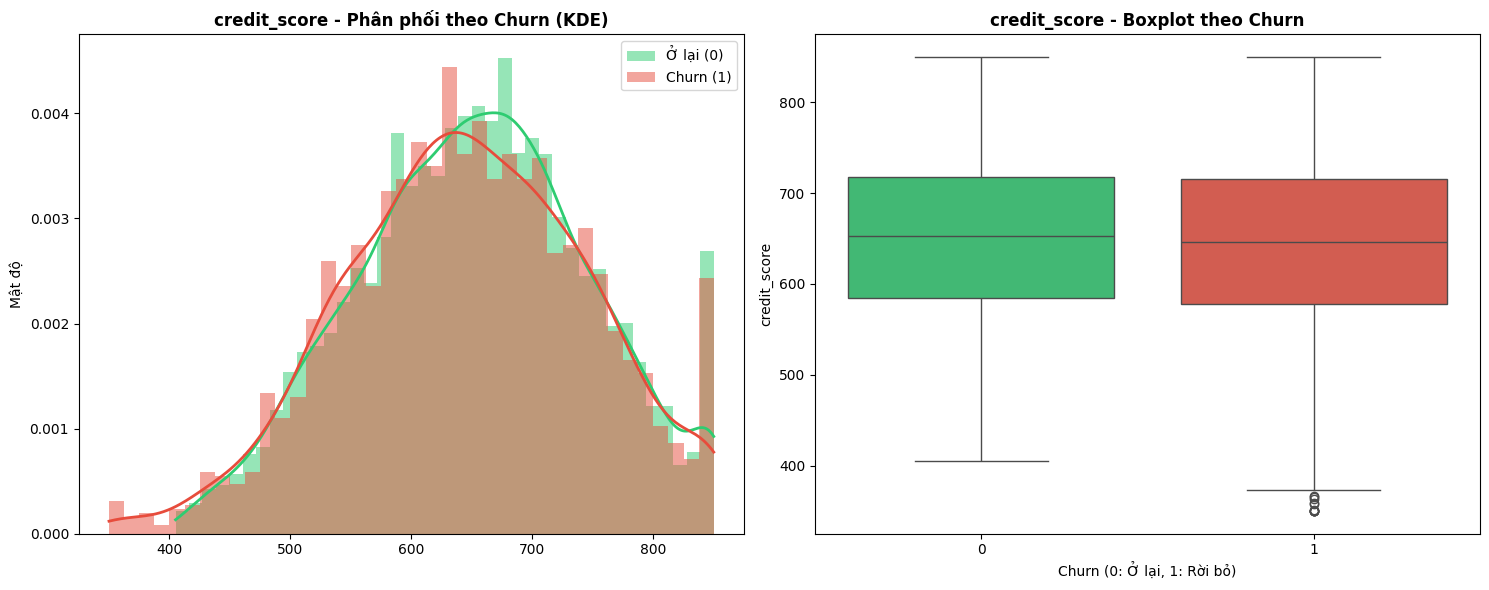

In [ ]:
# Vẽ chart phân phối credit_score theo churn và boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Tạo 1 hàng, 2 cột để chứa 2 biểu đồ
col_name_credit_score = 'credit_score' # xác định tên cột

# Chart Histogram/KDE
for label, color, name in [(0, '#2ecc71', 'Ở lại (0)'), (1, '#e74c3c', 'Churn (1)')]:
    data = df[df['churn'] == label][col_name_credit_score] # chỉ lấy data của credit_score và churn
    axes[0].hist(data, bins=40, density=True, alpha=0.5, color=color, label=name, edgecolor='none') # Dùng chart histogram

    # Vẽ thêm đường KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    axes[0].plot(x_range, kde(x_range), color=color, linewidth=2)

axes[0].set_title(f'{col_name_credit_score} - Phân phối theo Churn (KDE)', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Mật độ')

# Chart Boxplot
sns.boxplot(x='churn', y=col_name_credit_score, data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'{col_name_credit_score} - Boxplot theo Churn', fontweight='bold')
axes[1].set_xlabel('Churn (0: Ở lại, 1: Rời bỏ)')
axes[1].set_ylabel(col_name_credit_score)

plt.tight_layout()
plt.show()

**NHẬN XÉT CREDIT_SCORE VS. CHURN:**
1. Đặc điểm: Những KH rời bỏ có credit_score thấp hơn so với những KH ở lại. Nhưng không có sự chênh lệch quá lớn khi 2 biểu phân phối khá giống nhau.
2. Quan sát: credit_score có thể không phải là yếu tố mạnh để phân biệt KH rời bỏ hay không.

#### b. age

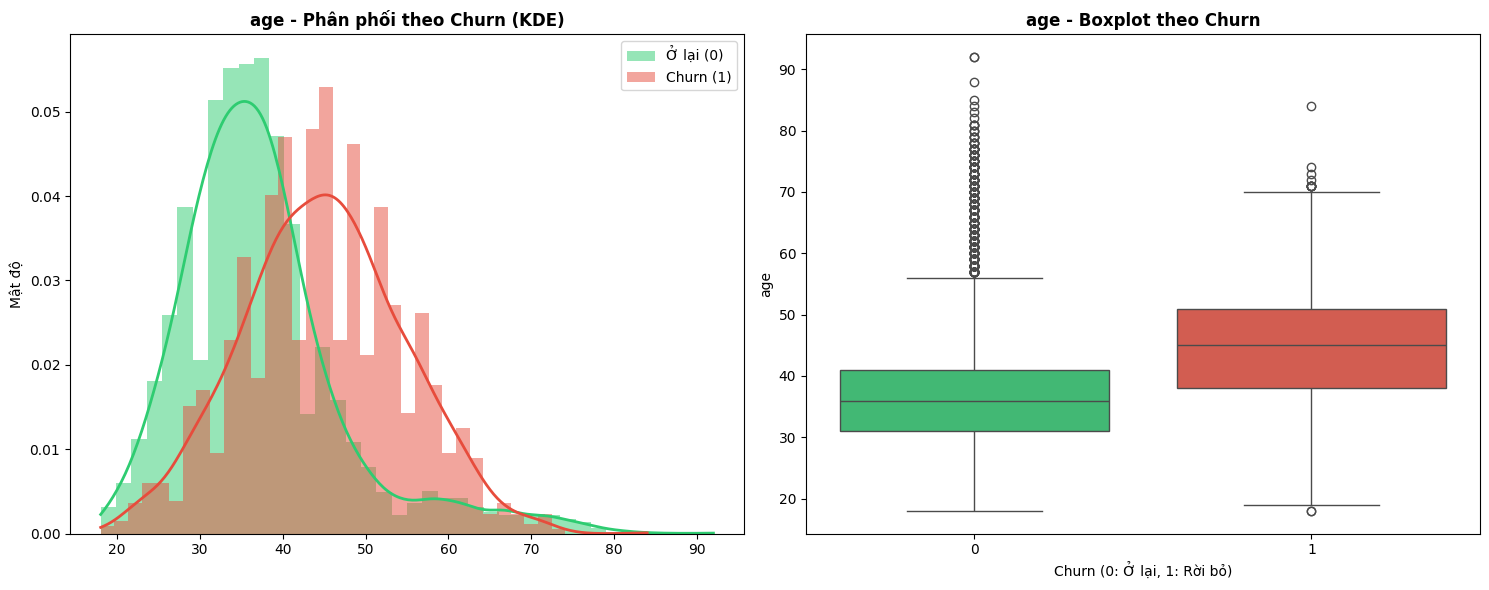

In [ ]:
# Vẽ chart phân phối age theo churn và boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Tạo 1 hàng, 2 cột để chứa 2 biểu đồ
col_name_age = 'age' # xác định tên cột

# Chart Histogram/KDE
for label, color, name in [(0, '#2ecc71', 'Ở lại (0)'), (1, '#e74c3c', 'Churn (1)')]:
    data = df[df['churn'] == label][col_name_age] # chỉ lấy data của age và churn
    axes[0].hist(data, bins=40, density=True, alpha=0.5, color=color, label=name, edgecolor='none') # Dùng chart histogram

    # Vẽ thêm đường KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    axes[0].plot(x_range, kde(x_range), color=color, linewidth=2)

axes[0].set_title(f'{col_name_age} - Phân phối theo Churn (KDE)', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Mật độ')

# Chart Boxplot
sns.boxplot(x='churn', y=col_name_age, data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'{col_name_age} - Boxplot theo Churn', fontweight='bold')
axes[1].set_xlabel('Churn (0: Ở lại, 1: Rời bỏ)')
axes[1].set_ylabel(col_name_age)

plt.tight_layout()
plt.show()

**NHẬN XÉT AGE VS. CHURN:**
1. Đặc điểm: KH rời bỏ (đỉnh ~45) có độ tuổi cao hơn so với những KH ở lại (đỉnh ~35). Phủ hợp với những quan sát từ heatmap. Tuy nhiên, khi phân tích đơn biến age, thống kê trong 359 outliers (là những KH lớn hơn 62 tuổi) cho thấy những KH này có xu hướng ở lại.

-> Giải thích cho điều này, chia dataset thành 3 nhóm tuổi 18-35, 36-62, >62.
- Nhóm 18-35 chiếm phần lớn ở nhóm KH ở lại (churn = 0) và có churn rate thấp -> kéo median nhóm KH ở lại thấp.
- Nhóm 36-62 là nhóm chiếm đa số trong dataset, và nhóm này bắt đầu có churn rate tăng dần -> kéo median nhóm KH rời bỏ (churn = 1) lên cao -> nhìn vào histogram và boxplot thấy nhóm rời bỏ có tuổi cao hơn
- Nhóm >62 tuổi (outliers) có số lượng rất ít, nhưng đa số chọn ở lại vì có thể họ đã gắn bó lâu năm, ít có xu hướng thay đổi thói quen tài chính, hoặc ít tiếp xúc với các ngân hàng cạnh tranh hơn.

=> **Có sự xuất hiện của quan hệ phi tuyến tính giữa age và churn** -> nên tạo age_group để model nắm bắt được mqh này tốt hơn.

2. Quan sát: age có thể là 1 trong những feature quan trọng trong model.

#### c. tenure

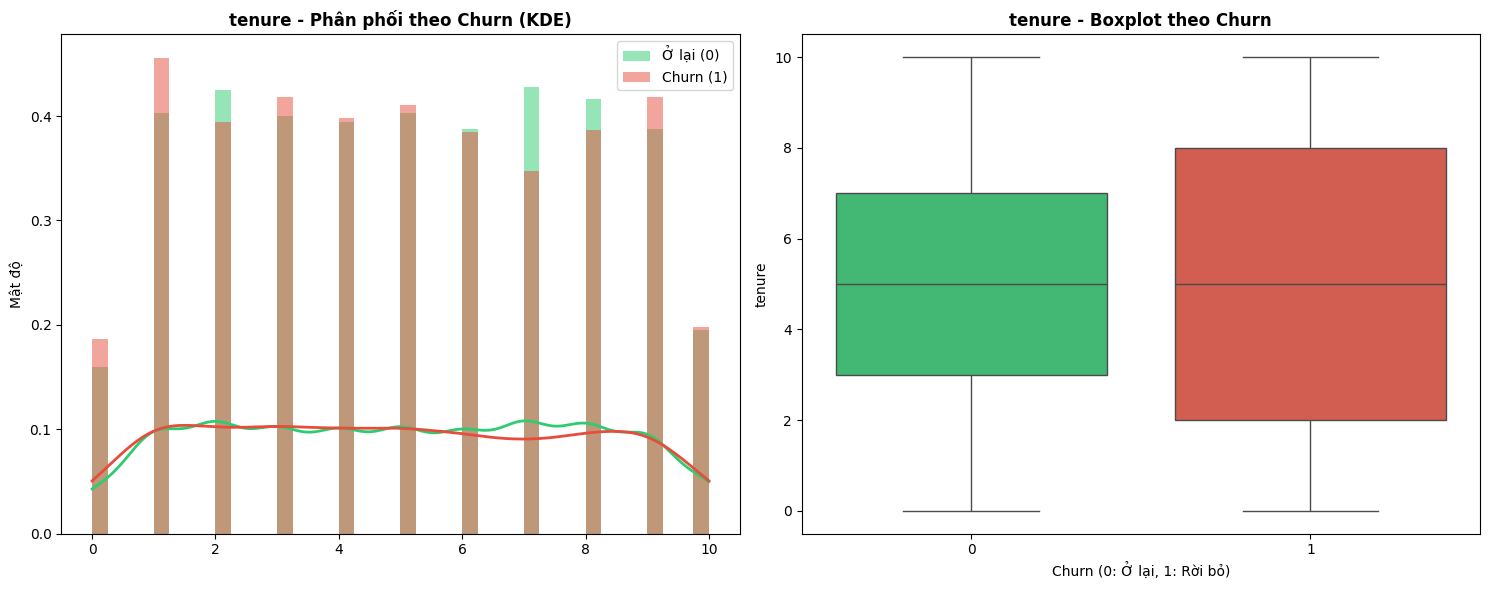

In [ ]:
# Vẽ chart phân phối tenure theo churn và boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Tạo 1 hàng, 2 cột để chứa 2 biểu đồ
col_name_tenure = 'tenure' # xác định tên cột

# Chart Histogram/KDE
for label, color, name in [(0, '#2ecc71', 'Ở lại (0)'), (1, '#e74c3c', 'Churn (1)')]:
    data = df[df['churn'] == label][col_name_tenure] # chỉ lấy data của tenure và churn
    axes[0].hist(data, bins=40, density=True, alpha=0.5, color=color, label=name, edgecolor='none') # Dùng chart histogram

    # Vẽ thêm đường KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    axes[0].plot(x_range, kde(x_range), color=color, linewidth=2)

axes[0].set_title(f'{col_name_tenure} - Phân phối theo Churn (KDE)', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Mật độ')

# Chart Boxplot
sns.boxplot(x='churn', y=col_name_tenure, data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'{col_name_tenure} - Boxplot theo Churn', fontweight='bold')
axes[1].set_xlabel('Churn (0: Ở lại, 1: Rời bỏ)')
axes[1].set_ylabel(col_name_tenure)

plt.tight_layout()
plt.show()

**NHẬN XÉT TENURE VS. CHURN:**
1. Đặc điểm: tương tự credit_score, phân phổi của tenure giữa 2 nhóm KH khá tương đồng.
2. Quan sát: tenure có thể không phải là một feature quan trọng trong model

#### d. balance

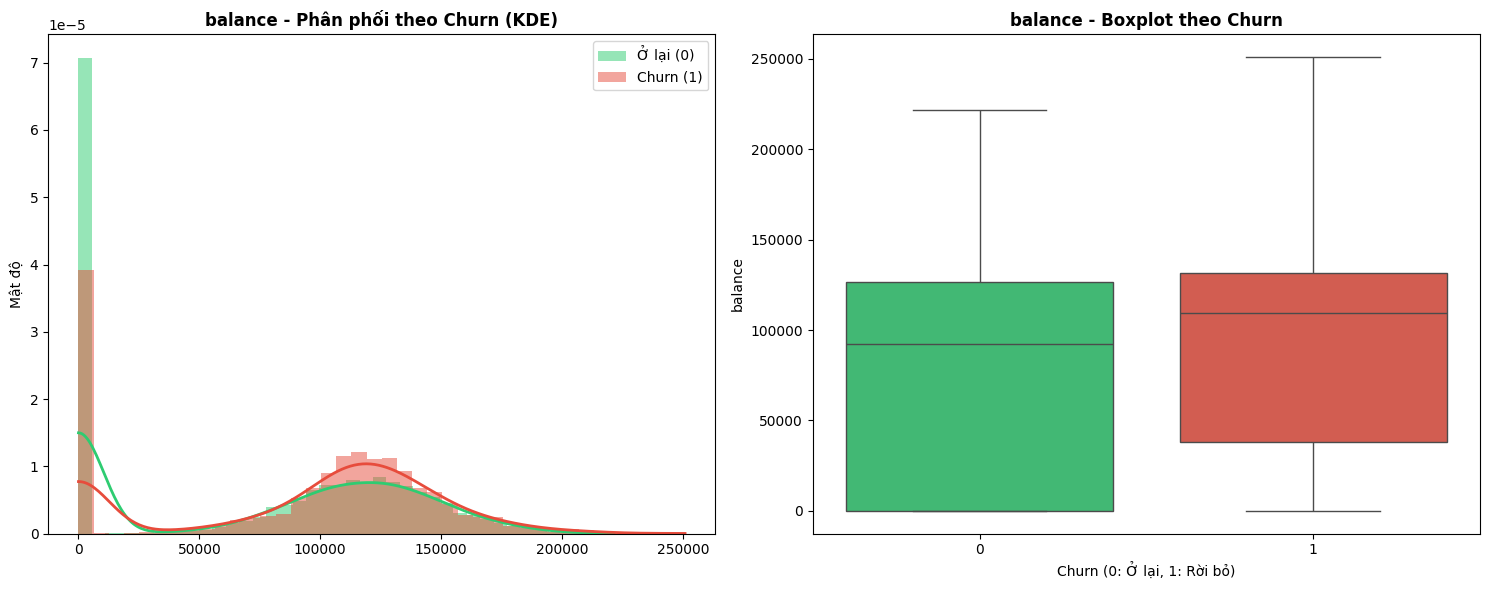

In [ ]:
# Vẽ chart phân phối balance theo churn và boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Tạo 1 hàng, 2 cột để chứa 2 biểu đồ
col_name_balance = 'balance' # xác định tên cột

# Chart Histogram/KDE
for label, color, name in [(0, '#2ecc71', 'Ở lại (0)'), (1, '#e74c3c', 'Churn (1)')]:
    data = df[df['churn'] == label][col_name_balance] # chỉ lấy data của balance và churn
    axes[0].hist(data, bins=40, density=True, alpha=0.5, color=color, label=name, edgecolor='none') # Dùng chart histogram

    # Vẽ thêm đường KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    axes[0].plot(x_range, kde(x_range), color=color, linewidth=2)

axes[0].set_title(f'{col_name_balance} - Phân phối theo Churn (KDE)', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Mật độ')

# Chart Boxplot
sns.boxplot(x='churn', y=col_name_balance, data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'{col_name_balance} - Boxplot theo Churn', fontweight='bold')
axes[1].set_xlabel('Churn (0: Ở lại, 1: Rời bỏ)')
axes[1].set_ylabel(col_name_balance)

plt.tight_layout()
plt.show()

**NHẬN XÉT BALANCE VS. CHURN:**
1. Đặc điểm:
- **Với những KH có balance > 0**, phân phối khá tương đồng nhau.
- **Với KH có balance =0**, có nhiều KH ở lại hơn so với những KH rời bỏ.
2. Quan sát: Những KH có tiền gửi dễ rời bỏ hơn. Có thể là do họ 'đáng giá', nên có nhiều sự lựa chọn về sp/dv tốt hơn nên dễ rời bỏ hơn. *CẦN PHÂN TÍCH KỸ HƠN*

#### e. estimated_salary

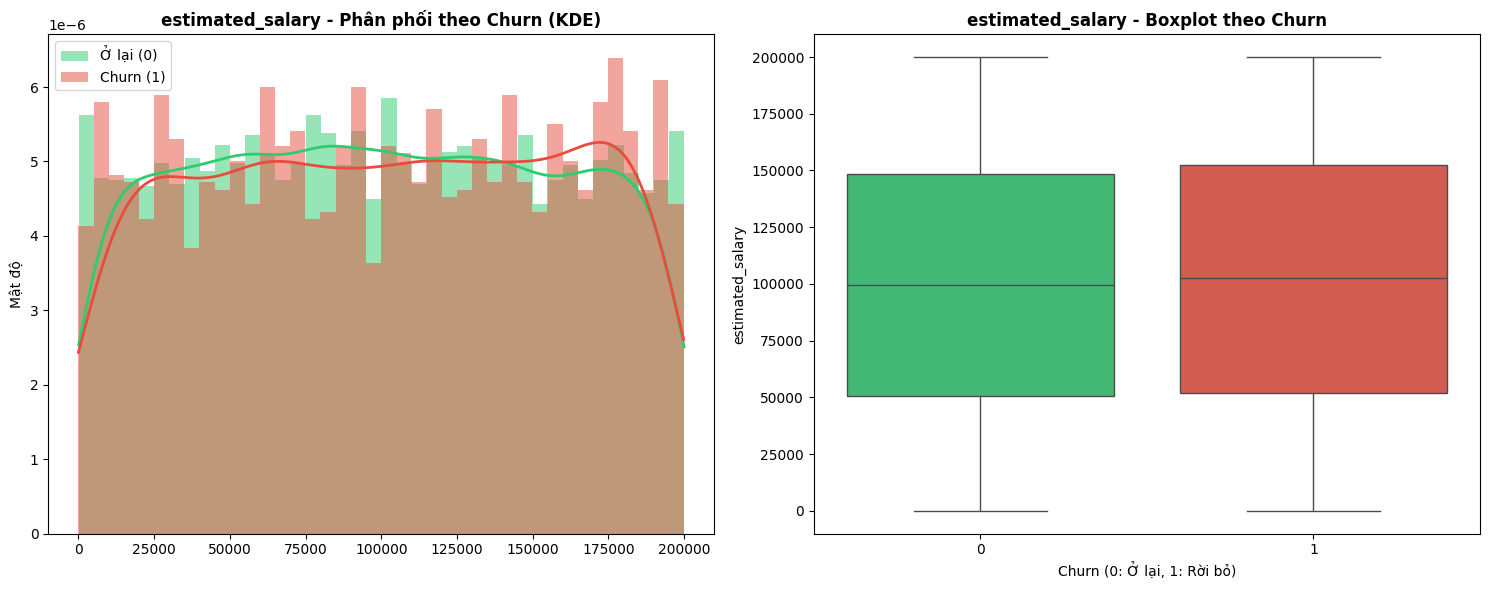

In [ ]:
# Vẽ chart phân phối balance theo churn và boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Tạo 1 hàng, 2 cột để chứa 2 biểu đồ
col_name_estimated_salary = 'estimated_salary' # xác định tên cột

# Chart Histogram/KDE
for label, color, name in [(0, '#2ecc71', 'Ở lại (0)'), (1, '#e74c3c', 'Churn (1)')]:
    data = df[df['churn'] == label][col_name_estimated_salary] # chỉ lấy data của estimated_salary và churn
    axes[0].hist(data, bins=40, density=True, alpha=0.5, color=color, label=name, edgecolor='none') # Dùng chart histogram

    # Vẽ thêm đường KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    axes[0].plot(x_range, kde(x_range), color=color, linewidth=2)

axes[0].set_title(f'{col_name_estimated_salary} - Phân phối theo Churn (KDE)', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Mật độ')

# Chart Boxplot
sns.boxplot(x='churn', y=col_name_estimated_salary, data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'{col_name_estimated_salary} - Boxplot theo Churn', fontweight='bold')
axes[1].set_xlabel('Churn (0: Ở lại, 1: Rời bỏ)')
axes[1].set_ylabel(col_name_estimated_salary)

plt.tight_layout()
plt.show()

**NHẬN XÉT ESTIMATED_SALARY VS. CHURN:**
1. Đặc điểm: phân phối estimated_salary khá tương đồng giữa 2 nhóm KH.
2. Quan sát: tương tự credit_score, tenure, estimated_salary có thể không phải là feature quan trọng trong model.

### Phân tích tương tác giữa các biến
Dựa vào correlation heatmap và các phân tích ở trên, phân tích thêm các tổ hợp quan trọng

#### **a. country * gender * churn**

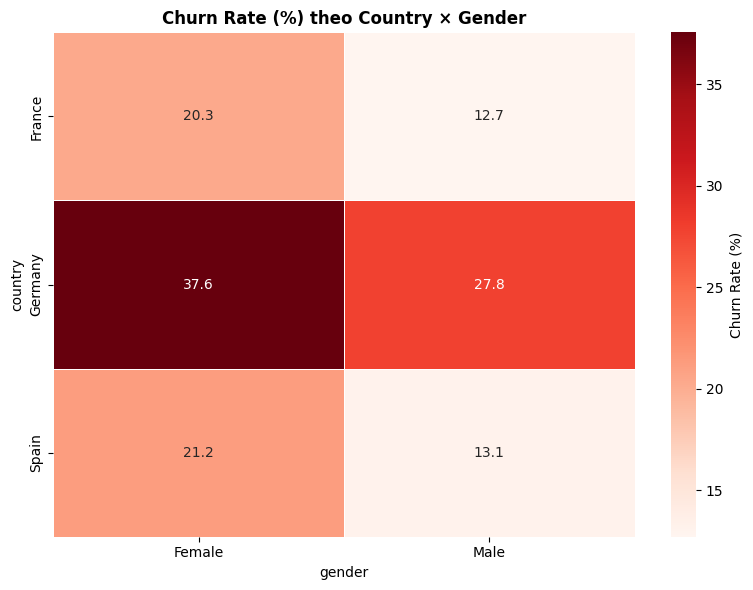

In [ ]:
# Phân tích country * gender vs. churn
# Heatmap: Churn rate theo Country × Gender
pivot = df.groupby(['country', 'gender'])['churn'].mean().unstack() * 100

# Create a figure and a single Axes object, since we're only plotting one heatmap here
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) theo Country × Gender', fontweight='bold')

plt.tight_layout()
plt.show()

**NHẬN XÉT:**
- KH đến từ Germany có churn rate cao; đặc biệt là các KH nữ đến từ Germany.

--> Cần lưu ý để có chiến lược giữ chân KH.

#### **b. age * active_member * churn**
age là feature quan trọng trong numerical variables, active_member là feature quan trọng trong categorical variables

In [ ]:
# Tạo bản sao của DataFrame để thêm cột mới mà không ảnh hưởng đến DataFrame gốc
df_temp = df.copy()

In [ ]:
# Tạo các nhóm tuổi để phân tích tương tác dễ hơn
# Các nhóm được xác định dựa trên quan sát trước đó: 18-35 (trẻ), 36-62 (trung niên), >62 (lớn tuổi)
df_temp['age_group'] = pd.cut(df_temp['age'],
                              bins=[0, 35, 62, df_temp['age'].max() + 1], # Thêm +1 vào max để bao phủ toàn bộ giá trị
                              labels=['18-35', '36-62', '62+'],
                              right=False)

df_temp.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,age_group
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-62
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-62
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-62
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-62
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-62


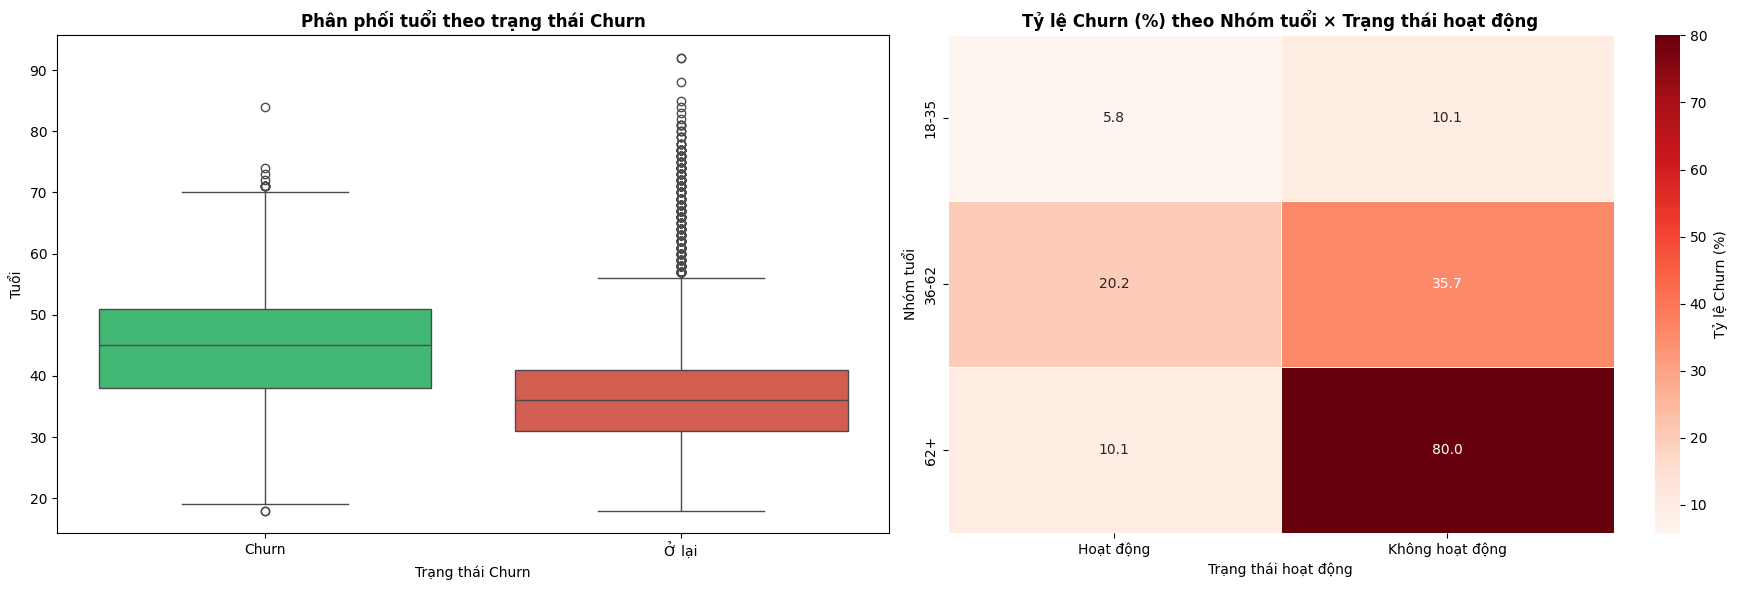

In [ ]:
# Phân tích tương tác giữa tuổi (age), trạng thái hoạt động (active_member) và churn

fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Tạo 2 subplot để hiển thị 2 biểu đồ

# --- Subplot bên trái: Boxplot phân phối tuổi theo trạng thái Churn ---
df_temp['Churn Label'] = df_temp['churn'].map({0: 'Ở lại', 1: 'Churn'})

sns.boxplot(x='Churn Label', y='age', data=df_temp, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Phân phối tuổi theo trạng thái Churn', fontweight='bold')
axes[0].set_xlabel('Trạng thái Churn')
axes[0].set_ylabel('Tuổi')

# --- Subplot bên phải: Heatmap tỷ lệ Churn theo Nhóm tuổi và Trạng thái hoạt động ---
# Ánh xạ cột active_member thành các nhãn dễ đọc hơn cho heatmap
df_temp['active_member_label'] = df_temp['active_member'].map({0: 'Không hoạt động', 1: 'Hoạt động'})

# Tạo bảng pivot để tính tỷ lệ churn cho từng kết hợp nhóm tuổi và trạng thái hoạt động
pivot_table1 = df_temp.groupby(['age_group', 'active_member_label'])['churn'].mean().unstack() * 100

sns.heatmap(pivot_table1, annot=True, fmt='.1f', cmap='Reds',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Tỷ lệ Churn (%)'})
axes[1].set_title('Tỷ lệ Churn (%) theo Nhóm tuổi × Trạng thái hoạt động', fontweight='bold')
axes[1].set_xlabel('Trạng thái hoạt động')
axes[1].set_ylabel('Nhóm tuổi')

plt.tight_layout()
plt.show()

**NHẬN XÉT:**
1. Nhóm 36-62 (nhóm phổ biến) có churn rate cao trong 3 nhóm kể cả còn hoạt động hay không.
2. KH không hoạt động thì có churn rate cao hơn ở mọi độ tuổi.
3. Nhóm >62 tuổi thống kê là có tỷ lệ ở lại cao, tuy nhiên, cứ là nhóm >62 tuổi mà không hoạt động thì có churn rate rất cao (80%) --> Đúng với trực giác thông thường

#### **c. balance * products_number * churn**

In [ ]:
# Phân tích tương tác giữa balance, products_number và churn

# Tạo cột 'has_balance': 0 nếu balance = 0, 1 nếu balance > 0
df_temp['has_balance'] = (df_temp['balance'] > 0).astype(int)

# Ánh xạ cột has_balance thành các nhãn dễ đọc hơn cho heatmap
df_temp['has_balance_label'] = df_temp['has_balance'].map({0: 'No Balance', 1: 'Has Balance'})
df_temp.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,age_group,Churn Label,active_member_label,has_balance,has_balance_label
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-62,Churn,Hoạt động,0,No Balance
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-62,Ở lại,Hoạt động,1,Has Balance
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-62,Churn,Không hoạt động,1,Has Balance
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-62,Ở lại,Không hoạt động,0,No Balance
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-62,Ở lại,Hoạt động,1,Has Balance


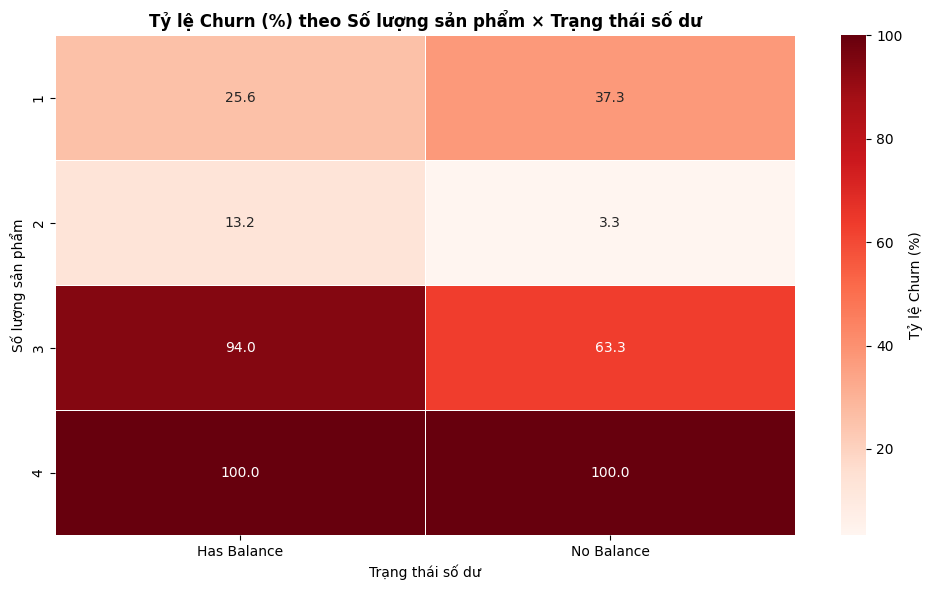

In [ ]:
# Tạo bảng pivot để tính tỷ lệ churn cho từng kết hợp của products_number và has_balance
pivot_table2 = df_temp.groupby(['products_number', 'has_balance_label'])['churn'].mean().unstack() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table2, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': 'Tỷ lệ Churn (%)'})
plt.title('Tỷ lệ Churn (%) theo Số lượng sản phẩm × Trạng thái số dư', fontweight='bold')
plt.xlabel('Trạng thái số dư')
plt.ylabel('Số lượng sản phẩm')
plt.tight_layout()
plt.show()

**NHẬN XÉT:**
1. Nhóm KH sử dụng từ 3-4 sp/dv có churn rate cao nhất.
- Nhóm sử dụng 4 sp/dv churn rate = 100%
- Nhóm sử dụng 3 sp/dv, KH có số dư có churn rate cao hơn so với KH không có số dư. -> *Có thể KH đang tái cơ câu tài chính*, KH đã sử dụng nhiều sp/dv và muốn đóng bớt\
==> Đây là tổ hơp KH nguy hiểm, cần phải có chiến lược giữ chân
2. Nhóm KH sử dụng 2 sp/dv có churn rate thấp nhất.
- Càng không có số dư thì ít rời bỏ nhất. *Có thể không có duy trì số dư nên rời đi hay ở lại không ảnh hưởng quá nhiều đến KH*

#### **d. balance * age * churn**

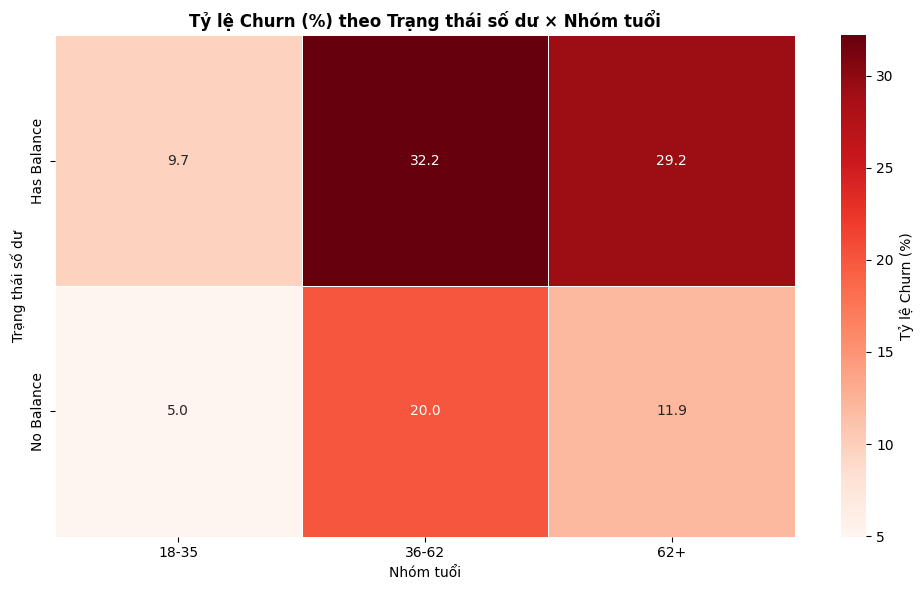

In [ ]:
# Phân tích tương tác giữa balance (có/không có), age (nhóm) và churn

# Tạo bảng pivot để tính tỷ lệ churn cho từng kết hợp của age_group và has_balance_label
pivot_table3 = df_temp.groupby(['has_balance_label', 'age_group'])['churn'].mean().unstack() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table3, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': 'Tỷ lệ Churn (%)'})
plt.title('Tỷ lệ Churn (%) theo Trạng thái số dư × Nhóm tuổi', fontweight='bold')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Trạng thái số dư')
plt.tight_layout()
plt.show()

**NHẬN XÉT:**
1. KH duy trì số dư có churn rate cao hơn ở bất kỳ độ tuổi nào (phù hợp với phân tích đa biến age - churn)
2. Nhóm 36-62 tuổi có churn rate cao nhất.

#### **e. balance * age * products_number * churn**

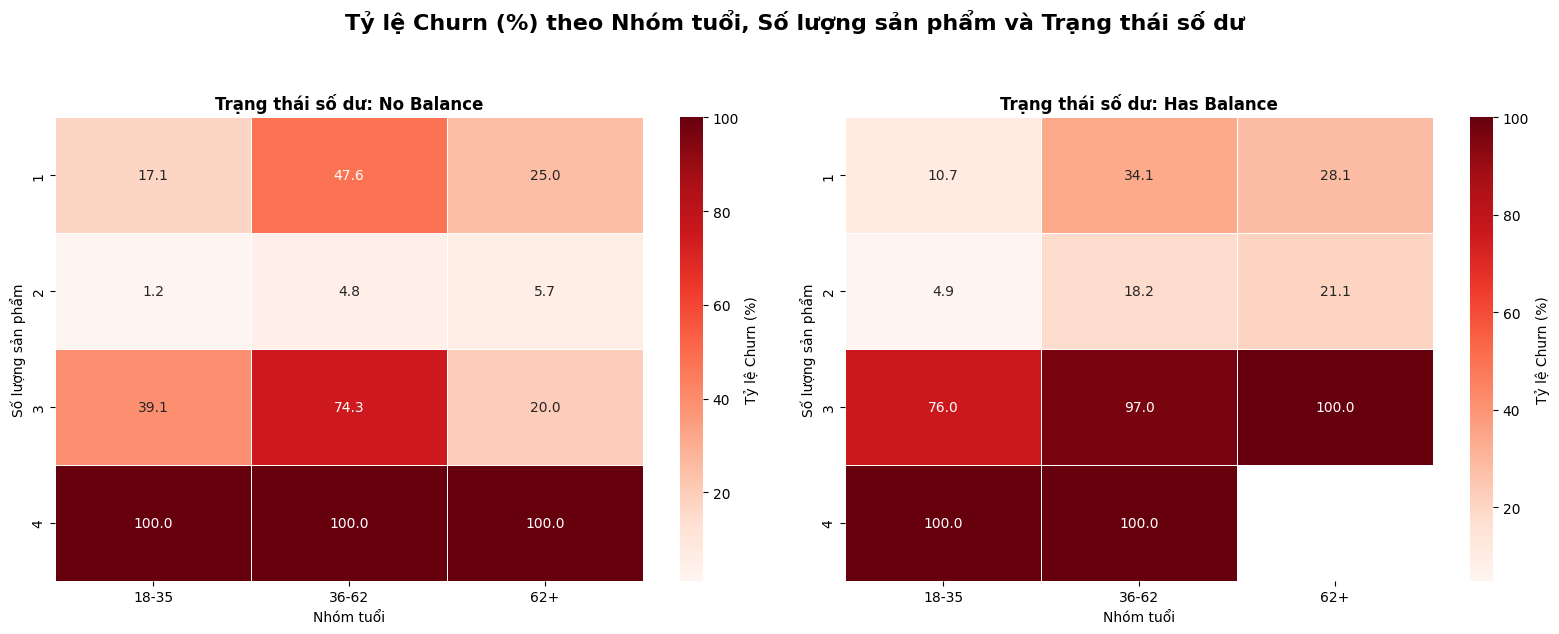

In [ ]:
# Phân tích tương tác giữa balance, age, products_number và churn

# Lấy các giá trị unique của 'has_balance_label' để tạo các biểu đồ riêng biệt
balance_states = df_temp['has_balance_label'].unique()

fig, axes = plt.subplots(1, len(balance_states), figsize=(16, 6))
fig.suptitle('Tỷ lệ Churn (%) theo Nhóm tuổi, Số lượng sản phẩm và Trạng thái số dư', fontsize=16, fontweight='bold', y=1.05)

for i, state in enumerate(balance_states):
    # Lọc dữ liệu theo trạng thái số dư
    subset_df = df_temp[df_temp['has_balance_label'] == state]

    # Tạo bảng pivot
    pivot_table = subset_df.groupby(['products_number', 'age_group'])['churn'].mean().unstack() * 100

    sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='Reds',
                ax=axes[i], linewidths=0.5, cbar_kws={'label': 'Tỷ lệ Churn (%)'})
    axes[i].set_title(f'Trạng thái số dư: {state}', fontweight='bold')
    axes[i].set_xlabel('Nhóm tuổi')
    axes[i].set_ylabel('Số lượng sản phẩm')

plt.tight_layout()
plt.show()

**NHẬN XÉT:**
- Nhóm KH sử dụng từ 3 dv/sp trở lên có churn rate cao (kể cả có số dư hay không)--> *TEAM Marketing cần lưu ý để có chiến dịch giữ chân KH*
- Đối với KH sử dụng 1-2 sp/dv, và không duy trì số dư:
  + Cần chú ý các KH độ tuổi trung niên
  + Có chiến dịch khuyến khích KH sử dụng thêm 1 dv/sp
- Đối với KH sử dụng 1-2 sp/dv, và có số dư:
  + Cần có chiến dịch cải thiện dịch vụ hoặc chiến dịch giữ chân KH đối với nhóm từ trung niên trở lên

# **NHẬN XÉT TỔNG QUAN TRƯỚC TRAINING MÔ HÌNH**
- Có 2037 (20.37%) KH rời bỏ ngân hàng ABC.
- Chân dung KH rời bỏ:
1. Thường là những KH có độ tuổi trung niên (36-62).
2. Thường là những KH không còn hoạt động với ngân hàng.
3. KH có số dư cao có nguy cơ rời bỏ hơn không có số dư
4. Những KH sử dụng 3-4 sp/dv.

# **3. Feature correlation - Transform / Encoding**

## **3.1 Feature engineering**
- Xem xét tạo thêm các features từ dữ liệu như:
  + has_balance: chia KH có balance = 0 với tập còn lại
  + age_group

In [ ]:
# Tạo bản sao df và làm việc trên bản sao này
df_model = df.copy()

### **a. Tạo feature has_balance**
Lý do: EDA cho thấy khách có balance=0 và balance>0 có hành vi churn khác nhau

==> Tạo flag để model dễ nắm bắt sự phân biệt này

In [ ]:
# --- Feature 1: has_balance ---
# Lý do: EDA cho thấy khách có balance=0 và balance>0 có hành vi churn khác nhau
# Tạo flag để model dễ nắm bắt sự phân biệt này

df_model['has_balance'] = (df_model['balance'] > 0).astype(int) # (0: không có số dư, 1: có số dư)
print(f"has_balance: {df_model['has_balance'].value_counts().to_dict()}")

has_balance: {1: 6383, 0: 3617}


### **b. Tạo feature age_group**
Lý do: EDA cho thấy age có quan hệ phi tuyến với churn
==> Binning thành nhóm tuổi giúp model tree-based nắm bắt tốt hơn

In [ ]:
# --- Feature 2: age_group ---
# Lý do: EDA cho thấy age có quan hệ phi tuyến với churn
# Binning thành nhóm tuổi giúp model tree-based nắm bắt tốt hơn
df_model['age_group'] = pd.cut(
    df_model['age'],
    bins=[0, 35, 50, 62, 100],
    labels=['18-35', '36-50', '51-62', '62+'] # Phân nhỏ nhóm trung niên hơn để capture tốt hơn
)

print("\nPhân phối age_group:")
print(df_model['age_group'].value_counts().sort_index())


Phân phối age_group:
age_group
18-35    4153
36-50    4586
51-62     902
62+       359
Name: count, dtype: int64


### **c. Tạo feature balance_per_product**

In [ ]:
# Feature 3: balance_per_product
# Lý do: số dư bình quân mỗi sản phẩm phản ánh "mức độ đầu tư" của KH vào từng sản phẩm — KH có balance lớn nhưng ít sản phẩm khác với
df_model['balance_per_product'] = df_model['balance'] / df_model['products_number']

## **3.1 Lựa chọn X (feature), y (target variable)**

In [ ]:
# Features: drop target và customer_id khỏi X
X = df_model.drop(columns=['churn', 'customer_id'])

# Target
y = df_model['churn']

In [ ]:
# Xem shape của X
print(f'Kích thước X: {X.shape}')
print(f'Kích thước y: {y.shape}')
print(f'\nDanh sách {X.shape[1]} features:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

Kích thước X: (10000, 13)
Kích thước y: (10000,)

Danh sách 13 features:
   1. credit_score
   2. country
   3. gender
   4. age
   5. tenure
   6. balance
   7. products_number
   8. credit_card
   9. active_member
  10. estimated_salary
  11. has_balance
  12. age_group
  13. balance_per_product


## **3.2 Train/test split**
Thực hiện TRƯỚC khi Scale và Encode One-hot

**Lý do tránh data leakage**:
- StandardScaler học mean/std → nếu fit trên toàn bộ data, thông tin của test set "rò rỉ" vào quá trình training
- OneHotEncoder học danh sách categories → ít leakage hơn nhưng về nguyên tắc vẫn nên fit sau split để nhất quán

In [ ]:
# Split train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # đảm bảo tỷ lệ churn ~20% được giữ nguyên ở cả train lẫn test — quan trọng với imbalanced dataset
)

# Lưu index để ghép customer_id sau này phục vụ clustering
train_index = X_train.index
test_index  = X_test.index

In [ ]:
# Xem tập X_train
X_train.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,has_balance,age_group,balance_per_product
2151,753,France,Male,57,7,0.00,1,1,0,159475.08,0,51-62,0.000
8392,739,Germany,Male,32,3,102128.27,1,1,0,63981.37,1,18-35,102128.270
5006,755,Germany,Female,37,0,113865.23,2,1,1,117396.25,1,36-50,56932.615
4117,561,France,Male,37,5,0.00,2,1,0,83093.25,0,36-50,0.000
7182,692,Germany,Male,49,6,110540.43,2,0,1,107472.99,1,36-50,55270.215


In [ ]:
# Xem shape của X, y
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print()

# Kiểm tra tỷ lệ churn trên các tập
print('Kiểm tra stratify — tỷ lệ churn:')
print(f'  Toàn bộ : {y.mean():.4f} ({y.sum():,} / {len(y):,})')
print(f'  Train   : {y_train.mean():.4f} ({y_train.sum():,} / {len(y_train):,})')
print(f'  Test    : {y_test.mean():.4f} ({y_test.sum():,} / {len(y_test):,})')
print('  ✅ Tỷ lệ churn nhất quán giữa train và test')

X_train: (8000, 13) | X_test: (2000, 13)
y_train: (8000,) | y_test: (2000,)

Kiểm tra stratify — tỷ lệ churn:
  Toàn bộ : 0.2037 (2,037 / 10,000)
  Train   : 0.2037 (1,630 / 8,000)
  Test    : 0.2035 (407 / 2,000)
  ✅ Tỷ lệ churn nhất quán giữa train và test


## **3.3 Xây dựng ColumnTransformer**

#### **a. Phân nhóm các cột**

In [ ]:
# Numerical features (6 cột)
numeric_features = ['credit_score', 'age', 'tenure', 'balance',
                    'estimated_salary', 'balance_per_product']

# Categorical features (3 cột)
categorical_features = ['country', 'gender', 'age_group']

# Binary feature - giữ nguyên, không xử lý (4 cột)
binary_features = ['products_number', 'credit_card', 'active_member', 'has_balance']

In [ ]:
# Xem phân loại các cột
print('Phân nhóm cột:')
print(f'  Numeric (StandardScaler) : {numeric_features}')
print(f'  Categorical (OHE)        : {categorical_features}')
print(f'  Binary (passthrough)     : {binary_features}')

Phân nhóm cột:
  Numeric (StandardScaler) : ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'balance_per_product']
  Categorical (OHE)        : ['country', 'gender', 'age_group']
  Binary (passthrough)     : ['products_number', 'credit_card', 'active_member', 'has_balance']


#### **b. Transform**
Lý do scale: các model như Logistic Regression, KNN nhạy cảm với scale — balance (0–200k) vs tenure (0–10) sẽ tạo bias nếu không scale

Random Forest không nhạy cảm với scale nhưng scale vẫn không làm hại

In [ ]:
# OneHotEncoder: biến categorical dạng string
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        drop='first', # tránh dummy variable trap (multicollinearity)
        handle_unknown='ignore', # nếu test set có giá trị không có trong → tạo cột toàn 0 thay vì báo lỗi
        sparse_output=False # trả về dense array cho dễ làm việc
    ))
])


# StandardScaler: các biến liên tục, đơn vị khác nhau
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

#### **c. Fit trên train, transform cả train, test**
tránh data leakage

In [ ]:
# Fitting
X_train_processed = preprocessor.fit_transform(X_train)  # Fit + transform train; học mean/std/categories từ train
X_test_processed  = preprocessor.transform(X_test)       # Chỉ transform test;  chỉ áp dụng, KHÔNG học lại

In [ ]:
# Lấy tên feature sau encode (dùng cho Feature Importance sau này)
cat_encoded_names = list(
    preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + cat_encoded_names + binary_features
all_feature_names

['credit_score',
 'age',
 'tenure',
 'balance',
 'estimated_salary',
 'balance_per_product',
 'country_Germany',
 'country_Spain',
 'gender_Male',
 'age_group_36-50',
 'age_group_51-62',
 'age_group_62+',
 'products_number',
 'credit_card',
 'active_member',
 'has_balance']

In [ ]:
# Xem shape các tập
print(f'X_train sau preprocessing : {X_train_processed.shape}')
print(f'X_test sau preprocessing  : {X_test_processed.shape}')
print(f'Tổng số features          : {len(all_feature_names)}')
print(f'\nTên tất cả features:')
for i, name in enumerate(all_feature_names, 1):
    print(f'  {i:2}. {name}')

X_train sau preprocessing : (8000, 16)
X_test sau preprocessing  : (2000, 16)
Tổng số features          : 16

Tên tất cả features:
   1. credit_score
   2. age
   3. tenure
   4. balance
   5. estimated_salary
   6. balance_per_product
   7. country_Germany
   8. country_Spain
   9. gender_Male
  10. age_group_36-50
  11. age_group_51-62
  12. age_group_62+
  13. products_number
  14. credit_card
  15. active_member
  16. has_balance


## **3.4 Xử lý class imbalance với SMOTE**
**Lý do SMOTE sau Scale**:
- Nếu các feature chưa được scale, khoảng cách bị dominated bởi feature có giá trị lớn (balance >> tenure)\
→ SMOTE cần scale trước để tính khoảng cách công bằng

**SMOTE chỉ áp dụng trên TRAIN SET**
- Test set giữ nguyên phân phối thực tế (80/20), để đánh giá model trên điều kiện thực tế

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train) # chỉ xử lý trên tập train

In [ ]:
# Xem thống kê
print('=== Trước SMOTE ===')
print(f'  Tổng mẫu: {len(y_train):,}')
print(f'  Churn=0 : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'  Churn=1 : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')

print('\n=== Sau SMOTE ===')
print(f'  Tổng mẫu: {len(y_train_smote):,}')
print(f'  Churn=0 : {(y_train_smote==0).sum():,} ({(y_train_smote==0).mean()*100:.1f}%)')
print(f'  Churn=1 : {(y_train_smote==1).sum():,} ({(y_train_smote==1).mean()*100:.1f}%)')

print('\n✅ Train set đã cân bằng 50/50 sau SMOTE')
print('⚠️  Test set KHÔNG áp dụng SMOTE — giữ nguyên phân phối thực tế')

=== Trước SMOTE ===
  Tổng mẫu: 8,000
  Churn=0 : 6,370 (79.6%)
  Churn=1 : 1,630 (20.4%)

=== Sau SMOTE ===
  Tổng mẫu: 12,740
  Churn=0 : 6,370 (50.0%)
  Churn=1 : 6,370 (50.0%)

✅ Train set đã cân bằng 50/50 sau SMOTE
⚠️  Test set KHÔNG áp dụng SMOTE — giữ nguyên phân phối thực tế


## **Tổng kết data preparation**

In [ ]:
print(f"{'Object':<30} {'Shape/Mô tả':<30}")
print('-' * 60)
print(f"{'X_train_smote':<30} {str(X_train_smote.shape):<30} ← Train model")
print(f"{'y_train_smote':<30} {str(y_train_smote.shape):<30} ← Train model")
print(f"{'X_test_processed':<30} {str(X_test_processed.shape):<30} ← Đánh giá model")
print(f"{'y_test':<30} {str(y_test.shape):<30} ← Đánh giá model")
print(f"{'preprocessor':<30} {'ColumnTransformer':<30} ← Dùng lại khi deploy")
print(f"{'all_feature_names':<30} {str(len(all_feature_names)) + ' features':<30} ← Feature importance")
print(f"{'test_index':<30} {'Index của X_test':<30} ← Ghép customer_id cho clustering")

Object                         Shape/Mô tả                   
------------------------------------------------------------
X_train_smote                  (12740, 16)                    ← Train model
y_train_smote                  (12740,)                       ← Train model
X_test_processed               (2000, 16)                     ← Đánh giá model
y_test                         (2000,)                        ← Đánh giá model
preprocessor                   ColumnTransformer              ← Dùng lại khi deploy
all_feature_names              16 features                    ← Feature importance
test_index                     Index của X_test               ← Ghép customer_id cho clustering


# **4. Model Training**


## **4.1 So sánh models bằng cross-validation**

In [ ]:
# Gọi model, truyền tham số bằng dict
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='logloss',
        verbosity=0, n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    )
}

In [ ]:
# CV - So sánh các models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # StratifiedKFold đảm bảo mỗi fold giữ tỷ lệ churn 50/50 (vì X đã được xử lý smote 50/50)
cv_results = {}

print('Đang chạy Cross-Validation (5-fold)...\n')

for name, model in models.items():
    # Tính 3 metrics qua cross-validation
    auc_scores    = cross_val_score(model, X_train_smote, y_train_smote,
                                    cv=cv, scoring='roc_auc', n_jobs=-1)
    f1_scores     = cross_val_score(model, X_train_smote, y_train_smote,
                                    cv=cv, scoring='f1', n_jobs=-1)
    recall_scores = cross_val_score(model, X_train_smote, y_train_smote,
                                    cv=cv, scoring='recall', n_jobs=-1)

    cv_results[name] = {
        'AUC-ROC Mean'  : auc_scores.mean(),
        'AUC-ROC Std'   : auc_scores.std(),
        'F1 Mean'       : f1_scores.mean(),
        'F1 Std'        : f1_scores.std(),
        'Recall Mean'   : recall_scores.mean(),
        'Recall Std'    : recall_scores.std(),
    }
    print(f'  ✓ {name:<22} AUC={auc_scores.mean():.4f}±{auc_scores.std():.4f} | '
          f'F1={f1_scores.mean():.4f} | Recall={recall_scores.mean():.4f}')

print('\n✅ Cross-Validation hoàn tất!')

Đang chạy Cross-Validation (5-fold)...

  ✓ Logistic Regression    AUC=0.7990±0.0076 | F1=0.7230 | Recall=0.7155
  ✓ Decision Tree          AUC=0.8456±0.0064 | F1=0.8470 | Recall=0.8548
  ✓ Random Forest          AUC=0.9670±0.0042 | F1=0.9094 | Recall=0.9050
  ✓ XGBoost                AUC=0.9635±0.0048 | F1=0.9018 | Recall=0.8813
  ✓ KNN                    AUC=0.9316±0.0043 | F1=0.8667 | Recall=0.9490

✅ Cross-Validation hoàn tất!


In [ ]:
# So sánh kết quả CV
cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df[['AUC-ROC Mean', 'AUC-ROC Std', 'F1 Mean', 'F1 Std', 'Recall Mean', 'Recall Std']]
cv_df = cv_df.sort_values('AUC-ROC Mean', ascending=False)
cv_df

,AUC-ROC Mean,AUC-ROC Std,F1 Mean,F1 Std,Recall Mean,Recall Std
Random Forest,0.966971,0.004243,0.909414,0.008366,0.905024,0.013459
XGBoost,0.963522,0.004803,0.901818,0.007996,0.881319,0.011422
KNN,0.931598,0.004274,0.866660,0.005040,0.948980,0.007413
Decision Tree,0.845604,0.006351,0.846962,0.007224,0.854788,0.014431
Logistic Regression,0.799027,0.007614,0.722962,0.009888,0.715542,0.012672


=== Kết quả Cross-Validation (5-fold) — Sắp xếp theo AUC-ROC ===
                     AUC-ROC Mean  AUC-ROC Std  F1 Mean  F1 Std  Recall Mean  Recall Std
Random Forest              0.9670       0.0042   0.9094  0.0084       0.9050      0.0135
XGBoost                    0.9635       0.0048   0.9018  0.0080       0.8813      0.0114
KNN                        0.9316       0.0043   0.8667  0.0050       0.9490      0.0074
Decision Tree              0.8456       0.0064   0.8470  0.0072       0.8548      0.0144
Logistic Regression        0.7990       0.0076   0.7230  0.0099       0.7155      0.0127


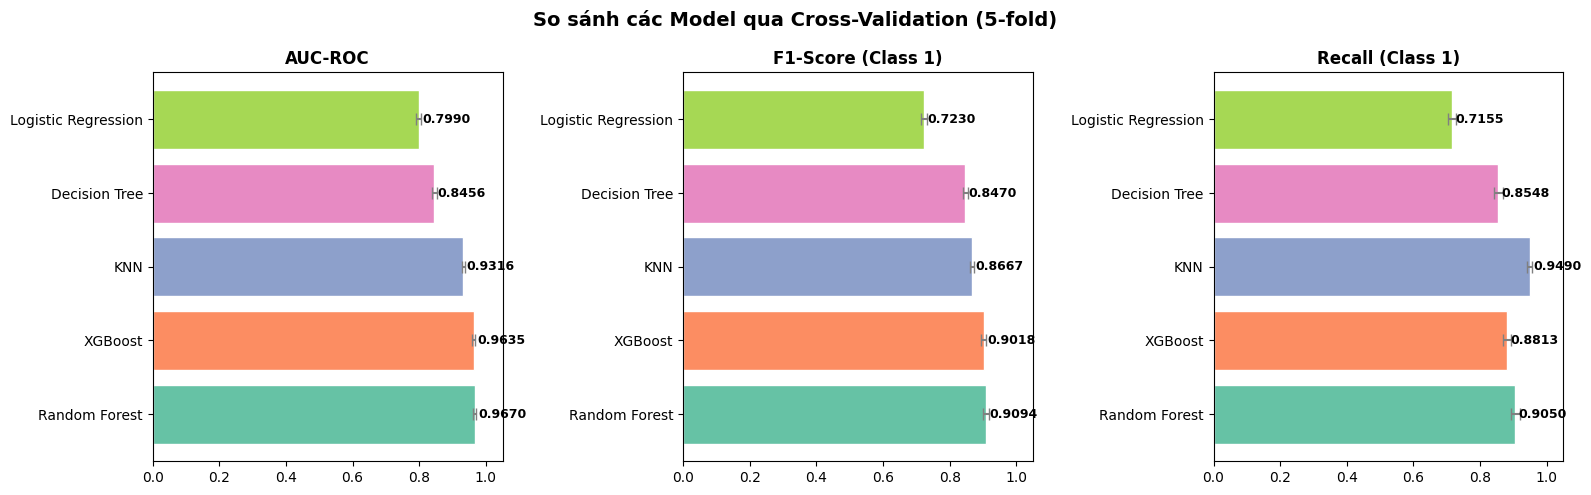


🏆 Model tốt nhất theo AUC-ROC: Random Forest


In [ ]:
print('=== Kết quả Cross-Validation (5-fold) — Sắp xếp theo AUC-ROC ===')
print(cv_df.round(4).to_string())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('So sánh các Model qua Cross-Validation (5-fold)', fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('AUC-ROC Mean', 'AUC-ROC Std', 'AUC-ROC'),
    ('F1 Mean',      'F1 Std',      'F1-Score (Class 1)'),
    ('Recall Mean',  'Recall Std',  'Recall (Class 1)')
]

colors = sns.color_palette('Set2', len(models))
model_names = list(cv_df.index)

for ax, (mean_col, std_col, title) in zip(axes, metrics_to_plot):
    bars = ax.barh(model_names, cv_df[mean_col],
                   xerr=cv_df[std_col],
                   color=colors, edgecolor='white',
                   error_kw={'ecolor': 'gray', 'capsize': 4})
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, cv_df[mean_col]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = cv_df['AUC-ROC Mean'].idxmax()
print(f'\n🏆 Model tốt nhất theo AUC-ROC: {best_model_name}')

## **4.2 Train tất cả models trên toàn bộ train set**

In [ ]:
# TRAIN TẤT CẢ MODEL TRÊN TOÀN BỘ X_train_smote
trained_models = {}

print('Training các model...\n')
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model
    print(f'  ✓ {name} — trained')

Training các model...

  ✓ Logistic Regression — trained
  ✓ Decision Tree — trained
  ✓ Random Forest — trained
  ✓ XGBoost — trained
  ✓ KNN — trained


## **Tổng kết - Objects dùng ở bước tiếp theo**

In [ ]:
print(f"{'Object':<30} {'Mô tả':<30}")
print('-' * 60)
print(f"{'trained_models':<30} {'Dict 5 model đã train':<30}")
print(f"{'cv_df':<30} {'Bảng CV results':<30}")
print(f"{'X_test_processed':<30} {'Dùng để evaluate':<30}")
print(f"{'y_test':<30} {'Ground truth để so sánh':<30}")

Object                         Mô tả                         
------------------------------------------------------------
trained_models                 Dict 5 model đã train         
cv_df                          Bảng CV results               
X_test_processed               Dùng để evaluate              
y_test                         Ground truth để so sánh       


# **5. Model Evaluation & Compare Model's Performance**

## **5.1 Predict và tổng hợp kết quá các models**

In [ ]:
# Predict trên tất cả models
eval_results = {}

for name, model in trained_models.items():
    y_pred       = model.predict(X_test_processed)
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]  # Lấy P(churn=1); trả về xác suất dùng cho thang AUC-ROC

    eval_results[name] = {
        'AUC-ROC'      : roc_auc_score(y_test, y_pred_proba),
        'F1 (class 1)' : f1_score(y_test, y_pred, pos_label=1),
        'Recall (class 1)'    : recall_score(y_test, y_pred, pos_label=1),
        'Precision (class 1)' : precision_score(y_test, y_pred, pos_label=1),
        'y_pred'       : y_pred,        # Lưu lại để vẽ confusion matrix
        'y_pred_proba' : y_pred_proba   # Lưu lại để vẽ ROC curve
    }
print('✅ Predict hoàn tất trên tất cả model!')

✅ Predict hoàn tất trên tất cả model!


In [ ]:
# Tạo bảng tổng hợp (bỏ cột y_pred và y_pred_proba)
summary_cols = ['AUC-ROC', 'F1 (class 1)', 'Recall (class 1)', 'Precision (class 1)']
eval_df = pd.DataFrame(
    {name: {k: v for k, v in metrics.items() if k in summary_cols}
     for name, metrics in eval_results.items()}
).T

eval_df = eval_df.sort_values('AUC-ROC', ascending=False)

print('=== Kết quả Evaluation trên Test Set ===')
print(eval_df.round(4).to_string())

best_auc   = eval_df['AUC-ROC'].idxmax()
best_recall = eval_df['Recall (class 1)'].idxmax()

print(f'\n🏆 Model tốt nhất theo AUC-ROC  : {best_auc}')
print(f'🎯 Model tốt nhất theo Recall   : {best_recall}')

=== Kết quả Evaluation trên Test Set ===
                     AUC-ROC  F1 (class 1)  Recall (class 1)  Precision (class 1)
Random Forest         0.8497        0.6158            0.5749               0.6629
XGBoost               0.8398        0.6056            0.5602               0.6590
Logistic Regression   0.7847        0.5081            0.6929               0.4011
KNN                   0.7697        0.5103            0.6413               0.4237
Decision Tree         0.6829        0.4891            0.5233               0.4591

🏆 Model tốt nhất theo AUC-ROC  : Random Forest
🎯 Model tốt nhất theo Recall   : Logistic Regression


**NHẬN XÉT:**
- Mô hình Random Forest là mô hình tốt nhất theo AUC-ROC trên toàn tập train
- Trong khi đó mô hình Logistics Regression lại tốt nhất trên toàn bộ tập train theo Recall

==> Cần xem xét kỹ hơn các chỉ số để chọn ra mô hình tốt nhất

## **5.2 ROC-Curve**
- ROC Curve vẽ TPR (Recall) vs FPR ở mọi threshold
- Model nào có đường cong càng "phình" về góc trên-trái = AUC càng cao = càng tốt
- Đường chéo = model random (AUC = 0.5) — baseline tệ nhất

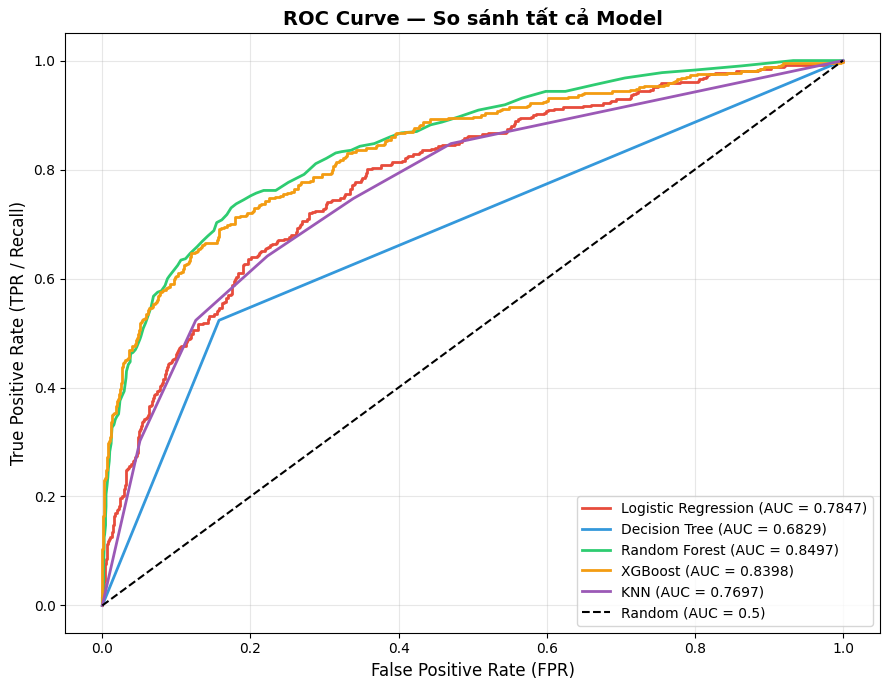

In [ ]:
# ROC curve
plt.figure(figsize=(9, 7))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for (name, metrics), color in zip(eval_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_pred_proba'])
    auc_val = metrics['AUC-ROC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})',
             color=color, linewidth=2)

# Đường baseline (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('ROC Curve — So sánh tất cả Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**NHẬN XÉT:** Đường càng phình lên góc trên-trái → AUC càng cao → model càng tốt
- Theo đó, mô hình RF tốt nhất (AUC = 0.85)

## **5.3 Confusion matrix**
**Confusion Matrix cho thấy cụ thể**:
- True Negative  (TN): Predict 0, thực tế 0 ✅
- False Positive (FP): Predict 1, thực tế 0 ❌ (tốn chi phí giữ chân nhầm)
- False Negative (FN): Predict 0, thực tế 1 ❌❌ (bỏ sót KH churn — nguy hiểm nhất)
- True Positive  (TP): Predict 1, thực tế 1 ✅

**Theo business context: FN nguy hiểm hơn FP** → Muốn FN càng nhỏ càng tốt = Recall càng cao càng tốt

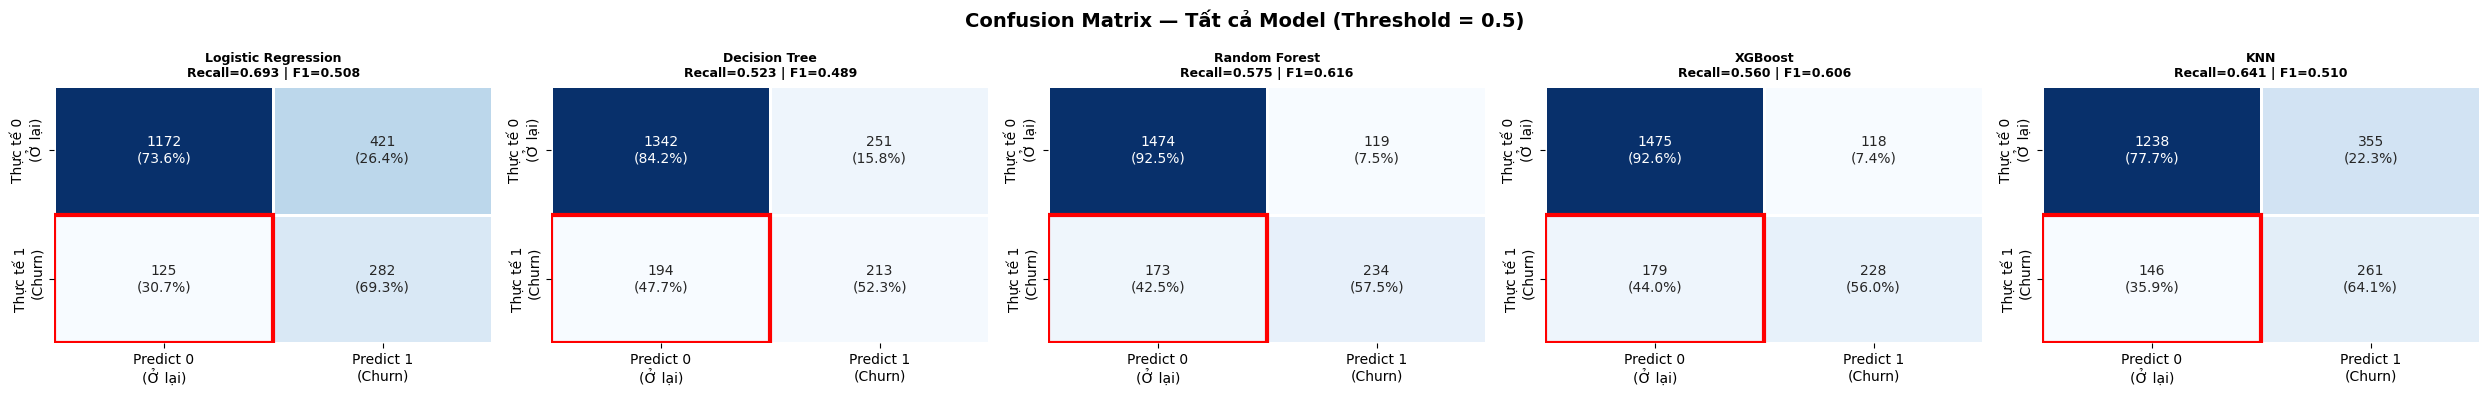

In [ ]:
n_models = len(trained_models) # Đếm số trained models
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4)) # Tạo subplot
fig.suptitle('Confusion Matrix — Tất cả Model (Threshold = 0.5)',
             fontsize=14, fontweight='bold')

for ax, (name, metrics) in zip(axes, eval_results.items()): # Confusion matrix
    cm = confusion_matrix(y_test, metrics['y_pred'])

    # Tính % theo từng hàng (theo thực tế) để dễ đọc
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Tạo annotation: số lượng + phần trăm
    annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
                       for j in range(2)] for i in range(2)])

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                ax=ax, linewidths=1, linecolor='white',
                xticklabels=['Predict 0\n(Ở lại)', 'Predict 1\n(Churn)'],
                yticklabels=['Thực tế 0\n(Ở lại)', 'Thực tế 1\n(Churn)'],
                cbar=False)

    recall_val = metrics['Recall (class 1)']
    f1_val     = metrics['F1 (class 1)']
    ax.set_title(f'{name}\nRecall={recall_val:.3f} | F1={f1_val:.3f}',
                 fontsize=9, fontweight='bold')

    # Highlight ô FN (hàng 1, cột 0) — ô nguy hiểm nhất
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False,
                                edgecolor='red', linewidth=3))

plt.tight_layout()
plt.show()

**NHẬN XÉT:**
- Theo confusion matrix, model Logistic Regression có recall cao nhất -> ưu tiên nhất để tránh mất KH mà không có cơ hội giữ chân.
- Tuy nhiên, LR cũng phải đánh đổi các giá trị dự đoán so với các mô hình khác ==> LR chưa thật sự hiệu quả nhất

## **5.4 Classification report chi tiết** - Random Forest

In [ ]:
rf_pred = eval_results['Random Forest']['y_pred']

print('=== Classification Report — Random Forest ===')
print(classification_report(
    y_test, rf_pred,
    target_names=['Ở lại (0)', 'Churn (1)'],
    digits=4
))

=== Classification Report — Random Forest ===
              precision    recall  f1-score   support

   Ở lại (0)     0.8950    0.9253    0.9099      1593
   Churn (1)     0.6629    0.5749    0.6158       407

    accuracy                         0.8540      2000
   macro avg     0.7789    0.7501    0.7628      2000
weighted avg     0.8477    0.8540    0.8500      2000



**NHẬN XÉT:**
Model RF cho thấy,
1. Trong số KH model dự báo là churn thì có 66% thật sự churn
2. Và trong số KH thật sự churn, model chỉ bắt được 57%

## **5.5 Visualize tổng hợp metrics cho tất cả models**

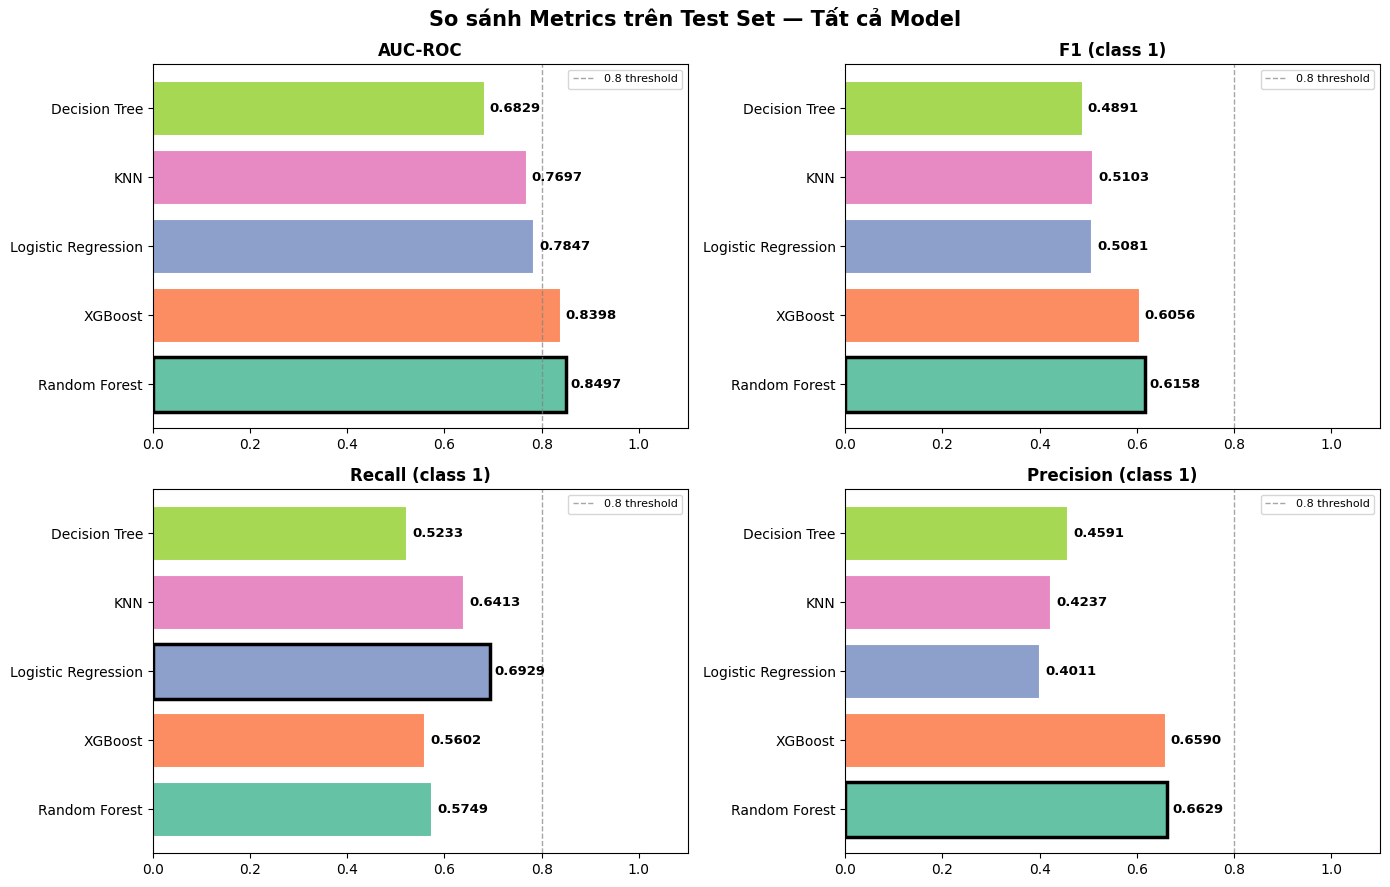

In [ ]:
#  BIỂU ĐỒ SO SÁNH 4 METRICS — TẤT CẢ MODEL
metrics_to_plot = ['AUC-ROC', 'F1 (class 1)', 'Recall (class 1)', 'Precision (class 1)']
model_names     = list(eval_df.index)  # Đã sort theo AUC-ROC
colors          = sns.color_palette('Set2', len(model_names))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('So sánh Metrics trên Test Set — Tất cả Model',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    values = eval_df[metric].values
    bars = ax.barh(model_names, values,
                   color=colors, edgecolor='white', linewidth=1.5)

    # Highlight model tốt nhất
    best_idx = values.argmax()
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)

    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlim(0, 1.1)
    ax.axvline(x=0.8, color='gray', linestyle='--',
               linewidth=1, alpha=0.7, label='0.8 threshold')

    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9.5, fontweight='bold')

    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Nhận xét tổng quan**:
- Random Forest và XGBoost thường dẫn đầu về AUC-ROC và F1
     → Phù hợp với kỳ vọng: ensemble methods mạnh hơn single model
- Logistic Regression tuy đơn giản nhưng là baseline quan trọng để đánh giá xem các model phức tạp có thực sự cải thiện không
- KNN, Logistic Regression thường có Recall cao nhưng Precision thấp hơn
      → Bắt được nhiều churn nhưng cũng báo nhầm nhiều hơn

→ Random Forest được chọn để Fine Tune vì cân bằng tốt giữa các metrics và có Feature Importance dễ interpret với business

## **Tổng kết model evaluation**

In [ ]:
# Tổng kết model evaluation

rf_auc    = eval_results['Random Forest']['AUC-ROC']
rf_recall = eval_results['Random Forest']['Recall (class 1)']
rf_f1     = eval_results['Random Forest']['F1 (class 1)']


print('TỔNG KẾT EVALUATION')
print('Performance Random Forest (baseline, chưa tune):')
print(f'  AUC-ROC            : {rf_auc:.4f}')
print(f'  Recall  (class 1)  : {rf_recall:.4f}')
print(f'  F1-Score (class 1) : {rf_f1:.4f}')

TỔNG KẾT EVALUATION
Performance Random Forest (baseline, chưa tune):
  AUC-ROC            : 0.8497
  Recall  (class 1)  : 0.5749
  F1-Score (class 1) : 0.6158


# **6. FINE TUNING**

## **6.1 Hyperparamater Tuning với RandomizedSearchCV**
**1. Lý do sử dụng RandomizedSearchCV thay vì GridSearchCV**:
-  GridSearchCV thử **tất cả** tổ hợp hyperparameter → rất chậm với Random Forest có nhiều param
- RandomizedSearchCV **lấy mẫu ngẫu nhiên** n tổ hợp từ không gian tìm kiếm → nhanh hơn nhiều và nghiên cứu thực nghiệm cho thấy kết quả tương đương GridSearch với n đủ lớn.

**2. Giải thích các hyperparamater:**
- n_estimators: số lượng cây trong rừng. Nhiều cây hơn → ổn định hơn nhưng chậm hơn
- max_depth: độ sâu tối đa mỗi cây. Nếu None -> dễ overfit. Giới hạn depth -> regularization, tránh overfit
- min_samples_split: số mẫu tối thiểu để split 1 node. Càng cao → cây đơn giản hơn, tránh overfit
- max_features: số feature xem xét tại mỗi split
- class_weight: xử lý imbalance ở tầng model

In [ ]:
# Truyền các ngưỡng hyperparamater
param_distributions = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf' : [1, 2, 4, 8],
    'max_features'     : ['sqrt', 'log2'], #'sqrt' = sqrt(n_features) — mặc định tốt cho classification; 'log2' = log2(n_features) — ít feature hơn, đa dạng hơn
    'class_weight'     : [None, 'balanced'] # Dù đã SMOTE, thêm class_weight='balanced' như một lớp bảo vệ thêm — thử cả None để so sánh
}

In [ ]:
# Tính tổng số tổ hợp nếu dùng GridSearch
total_combinations = (4 * 5 * 4 * 4 * 2 * 2)
print(f'Tổng số tổ hợp nếu GridSearch: {total_combinations:,}')
print(f'RandomizedSearchCV chỉ thử  : 50 tổ hợp ngẫu nhiên')
print(f'Tiết kiệm: {(1 - 50/total_combinations)*100:.1f}% thời gian\n')

Tổng số tổ hợp nếu GridSearch: 1,280
RandomizedSearchCV chỉ thử  : 50 tổ hợp ngẫu nhiên
Tiết kiệm: 96.1% thời gian



In [ ]:
# Chạy RandomizedSearchCV
#  Lý do chọn AUC-ROC thay vì recall để tối ưu:
  ## - AUC-ROC đánh giá model trên toàn bộ threshold range
  ## - Tối ưu recall trực tiếp trong CV có thể dẫn đến model bị bias — predict tất cả là 1 để maximize recall
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator          = rf_base,
    param_distributions= param_distributions,
    n_iter             = 50, # n_iter=50: thử 50 tổ hợp ngẫu nhiên
    scoring            = 'roc_auc', # tối ưu theo AUC-ROC trong quá trình search
    cv                 = cv, # 5-fold cross validation
    n_jobs             = -1, # n_jobs=-1: dùng tất cả CPU cores để chạy song song
    random_state       = 42,
    verbose            = 1,       # In progress khi đang chạy
    refit              = True     # Tự động refit model tốt nhất trên toàn bộ train
)

print('Đang chạy RandomizedSearchCV (50 iterations × 5-fold)...')
print('Quá trình có thể mất vài phút')

random_search.fit(X_train_smote, y_train_smote)
print(f'\n✅ RandomizedSearchCV hoàn tất!')
print(f'   Best AUC-ROC (CV): {random_search.best_score_:.4f}') # Xem best AUC-ROC
print(f'\nBest parameters:') # Xem best paramaters
for param, value in random_search.best_params_.items():
    print(f'  {param:<25}: {value}')

Đang chạy RandomizedSearchCV (50 iterations × 5-fold)...
Quá trình có thể mất vài phút
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ RandomizedSearchCV hoàn tất!
   Best AUC-ROC (CV): 0.9682

Best parameters:
  n_estimators             : 300
  min_samples_split        : 2
  min_samples_leaf         : 1
  max_features             : log2
  max_depth                : None
  class_weight             : balanced


In [ ]:
# Lấy model tốt nhất và so sánh với baseline

rf_tuned = random_search.best_estimator_
rf_base_trained = trained_models['Random Forest']  # Model chưa tune từ Bước 4

# Predict cả 2 model trên test set
    ## Mô hình baseline, chưa tune
y_pred_base  = rf_base_trained.predict(X_test_processed)
y_proba_base = rf_base_trained.predict_proba(X_test_processed)[:, 1]
    ## Mô hình đã tune
y_pred_tuned  = rf_tuned.predict(X_test_processed)
y_proba_tuned = rf_tuned.predict_proba(X_test_processed)[:, 1]

In [ ]:
# Bảng so sánh trước/sau tuning
comparison = pd.DataFrame({
    'RF Baseline (chưa tune)': {
        'AUC-ROC'            : roc_auc_score(y_test, y_proba_base),
        'F1 (class 1)'       : f1_score(y_test, y_pred_base),
        'Recall (class 1)'   : recall_score(y_test, y_pred_base),
        'Precision (class 1)': precision_score(y_test, y_pred_base)
    },
    'RF Tuned (sau tune)': {
        'AUC-ROC'            : roc_auc_score(y_test, y_proba_tuned),
        'F1 (class 1)'       : f1_score(y_test, y_pred_tuned),
        'Recall (class 1)'   : recall_score(y_test, y_pred_tuned),
        'Precision (class 1)': precision_score(y_test, y_pred_tuned)
    }
}).T

In [ ]:
# Tính delta cải thiện
comparison['Delta (↑)'] = comparison['AUC-ROC'] - comparison['AUC-ROC'].iloc[0] #iloc[0] để lấy hàng đầu tiên

print('=== So sánh RF Baseline vs RF Tuned (threshold = 0.5) ===')
print(comparison.round(4).to_string())

=== So sánh RF Baseline vs RF Tuned (threshold = 0.5) ===
                         AUC-ROC  F1 (class 1)  Recall (class 1)  Precision (class 1)  Delta (↑)
RF Baseline (chưa tune)   0.8497        0.6158            0.5749               0.6629     0.0000
RF Tuned (sau tune)       0.8517        0.6087            0.5676               0.6562     0.0021


**Nhận xét:**
Sau tuned, AUC-ROC cải thiện 0.21%, trade-off các chỉ số khác.
Không có sự khác biệt lớn trước và sau tuning hyperparamater -> chọn mô hình tuned để đạt AUC-ROC tốt nhất

## **6.2 Threshold optimization**
- Mặc định sklearn dùng threshold = 0.5 để phân loại: P(churn) ≥ 0.5 → predict churn=1.
- Nhưng 0.5 không phải lúc nào cũng tối ưu cho bài toán cụ thể.
  + **Hạ threshold xuống** (ví dụ 0.3) → model nhạy hơn → Recall tăng, Precision giảm.  
  + **Nâng threshold lên** (ví dụ 0.7) → model thận trọng hơn → Precision tăng, Recall giảm.
- Mục tiêu: tìm threshold mà **Recall đủ cao** mà **không hy sinh Precision quá nhiều**.

Ngoài ra,
- Precision-Recall Curve cho thấy sự trade-off giữa Precision và Recall ở từng threshold → Giúp chọn threshold phù hợp với business context
- Trả lời câu hỏi từ Bước 5 — sau khi tune threshold, RF có vượt LR không?

Lấy xác suất của LR từ bước 5

In [ ]:
# Lấy xác suất của Logistic Regression từ Bước 5
y_proba_lr = eval_results['Logistic Regression']['y_pred_proba']

Tính precision-recall curve

In [ ]:
# Tính Precision-Recall curve
prec_tuned, rec_tuned, thresholds_tuned = precision_recall_curve(y_test, y_proba_tuned)
prec_lr,    rec_lr,    thresholds_lr    = precision_recall_curve(y_test, y_proba_lr)

Vẽ precision - recall curve

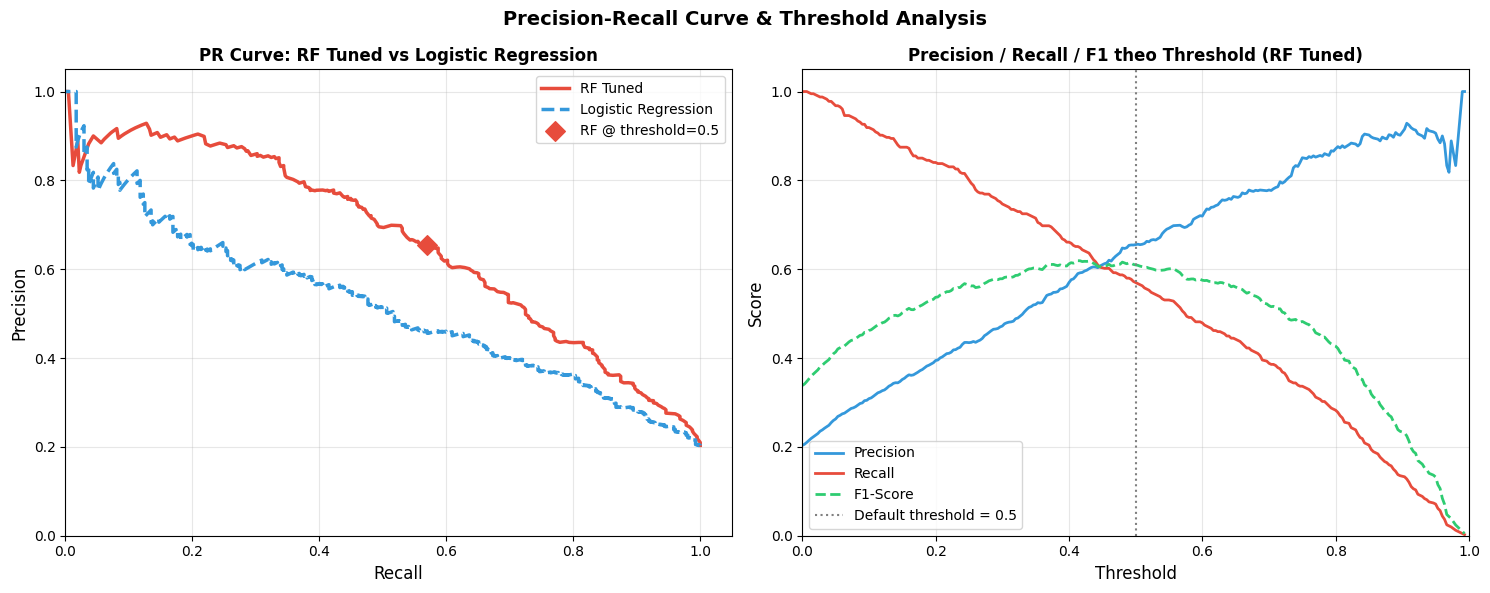

In [ ]:
# Vẽ Precision - Recall curve
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Tạo subplot
fig.suptitle('Precision-Recall Curve & Threshold Analysis', fontsize=14, fontweight='bold')

# --- Plot 1: PR Curve RF Tuned vs Logistic Regression ---
axes[0].plot(rec_tuned, prec_tuned, color='#e74c3c', linewidth=2.5,
             label='RF Tuned')
axes[0].plot(rec_lr, prec_lr, color='#3498db', linewidth=2.5,
             label='Logistic Regression', linestyle='--')

# Đánh dấu điểm threshold = 0.5 hiện tại
idx_05_tuned = np.argmin(np.abs(thresholds_tuned - 0.5))
axes[0].scatter(rec_tuned[idx_05_tuned], prec_tuned[idx_05_tuned],
                color='#e74c3c', s=100, zorder=5, marker='D',
                label=f'RF @ threshold=0.5')

axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('PR Curve: RF Tuned vs Logistic Regression', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 1.05)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Precision, Recall, F1 theo từng threshold ---
# Tính F1 tại mỗi threshold
f1_scores_threshold = [
    f1_score(y_test, (y_proba_tuned >= t).astype(int), zero_division=0)
    for t in thresholds_tuned
]

axes[1].plot(thresholds_tuned, prec_tuned[:-1],
             color='#3498db', linewidth=2, label='Precision')
axes[1].plot(thresholds_tuned, rec_tuned[:-1],
             color='#e74c3c', linewidth=2, label='Recall')
axes[1].plot(thresholds_tuned, f1_scores_threshold,
             color='#2ecc71', linewidth=2, label='F1-Score', linestyle='--')

# Đánh dấu threshold = 0.5
axes[1].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5,
                label='Default threshold = 0.5')

axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision / Recall / F1 theo Threshold (RF Tuned)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**NHẬN XÉT:**
- Đường cong RF Tuned nằm TRÊN đường LR (plot 1) -> RF tốt hơn ở mọi threshold\
-> Tăng recall bằng cách di chuyển hình thoi sang phải, đồng thời hạ threshold (plot 2)

Tìm optimal threshold
1. **Chiến lược**: tìm threshold nhỏ nhất mà tại đó Precision vẫn >= 0.4 (CÓ THỂ THAY ĐỔI ĐƯỢC) VÀ Recall cao nhất có thể

2. **Lý do chọn Precision >= 0.4 làm sàn:**
- Nếu Precision quá thấp (ví dụ 0.2) → cứ 5 KH được identify là churn thì chỉ 1 người thực sự churn → campaign giữ chân tốn kém và kém hiệu quả
- Precision >= 0.4 nghĩa là ít nhất 2/5 KH được target là churn thật → chấp nhận được trong thực tế

In [ ]:
MIN_PRECISION = 0.5   # Precision tối thiểu chấp nhận được; có thể điều chỉnh; ĐÃ ĐIỀU CHỈNH BẰNG 0.5

In [ ]:
# Lọc những threshold thỏa điều kiện Precision >= MIN_PRECISION
valid_mask = prec_tuned[:-1] >= MIN_PRECISION
valid_thresholds = thresholds_tuned[valid_mask]
valid_recalls    = rec_tuned[:-1][valid_mask]
valid_precisions = prec_tuned[:-1][valid_mask]
valid_f1s        = np.array(f1_scores_threshold)[valid_mask]

if len(valid_thresholds) == 0:
    print('⚠️ Không có threshold nào thỏa điều kiện Precision >= {MIN_PRECISION}')
    print('   → Hạ MIN_PRECISION xuống hoặc dùng threshold = 0.5 mặc định')
    optimal_threshold = 0.5
else:
    # Trong các threshold thỏa Precision >= 0.4, chọn cái có Recall cao nhất
    best_idx          = valid_recalls.argmax()
    optimal_threshold = valid_thresholds[best_idx]
    optimal_recall    = valid_recalls[best_idx]
    optimal_precision = valid_precisions[best_idx]
    optimal_f1        = valid_f1s[best_idx]

    print(f'=== Optimal Threshold (Precision >= {MIN_PRECISION}) ===')
    print(f'  Threshold tối ưu : {optimal_threshold:.4f}')
    print(f'  Recall           : {optimal_recall:.4f}')
    print(f'  Precision        : {optimal_precision:.4f}')
    print(f'  F1-Score         : {optimal_f1:.4f}')

    # So sánh với threshold = 0.5
    recall_05    = recall_score(y_test, (y_proba_tuned >= 0.5).astype(int))
    precision_05 = precision_score(y_test, (y_proba_tuned >= 0.5).astype(int))

    print(f'\n=== So sánh Threshold ===')
    print(f'  Threshold = 0.5      → Recall={recall_05:.4f} | Precision={precision_05:.4f}')
    print(f'  Threshold = {optimal_threshold:.2f} (opt) → Recall={optimal_recall:.4f} | Precision={optimal_precision:.4f}')
    print(f'  Recall cải thiện: +{(optimal_recall - recall_05):.4f}')

=== Optimal Threshold (Precision >= 0.5) ===
  Threshold tối ưu : 0.3333
  Recall           : 0.7248
  Precision        : 0.5043
  F1-Score         : 0.5948

=== So sánh Threshold ===
  Threshold = 0.5      → Recall=0.5700 | Precision=0.6554
  Threshold = 0.33 (opt) → Recall=0.7248 | Precision=0.5043
  Recall cải thiện: +0.1548


Predict với optimal threshold

In [ ]:
y_pred_optimal = (y_proba_tuned >= optimal_threshold).astype(int)

print(f'=== Classification Report — RF Tuned (threshold = {optimal_threshold:.2f}) ===')
print(classification_report(
    y_test, y_pred_optimal,
    target_names=['Ở lại (0)', 'Churn (1)'],
    digits=4
))

=== Classification Report — RF Tuned (threshold = 0.33) ===
              precision    recall  f1-score   support

   Ở lại (0)     0.9208    0.8180    0.8664      1593
   Churn (1)     0.5043    0.7248    0.5948       407

    accuracy                         0.7990      2000
   macro avg     0.7126    0.7714    0.7306      2000
weighted avg     0.8361    0.7990    0.8111      2000



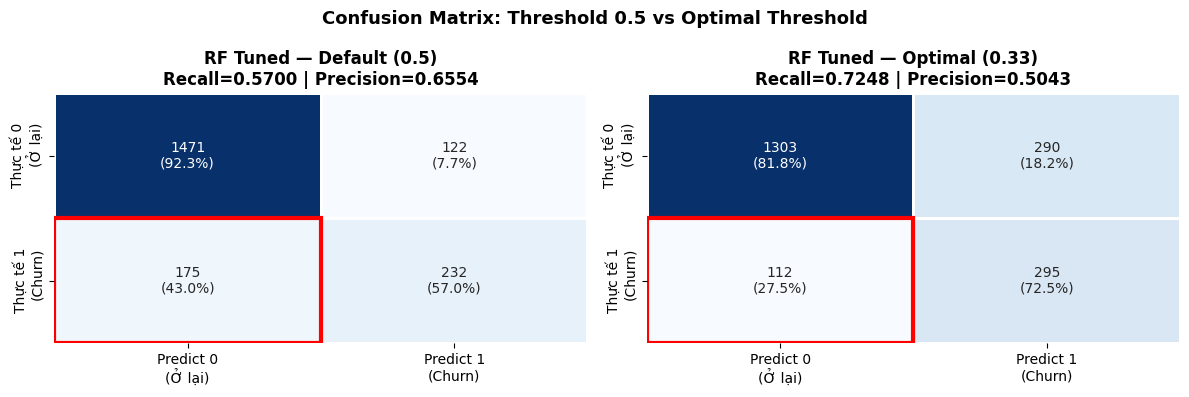

In [ ]:
# Confusion Matrix so sánh 2 threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrix: Threshold 0.5 vs Optimal Threshold',
             fontsize=13, fontweight='bold')

for ax, (threshold, y_pred_t, label) in zip(
    axes,
    [
        (0.5,               (y_proba_tuned >= 0.5).astype(int),    'Default (0.5)'),
        (optimal_threshold, y_pred_optimal,                         f'Optimal ({optimal_threshold:.2f})')
    ]
):
    cm = confusion_matrix(y_test, y_pred_t)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
                        for j in range(2)] for i in range(2)])

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                linewidths=1, linecolor='white', cbar=False,
                xticklabels=['Predict 0\n(Ở lại)', 'Predict 1\n(Churn)'],
                yticklabels=['Thực tế 0\n(Ở lại)', 'Thực tế 1\n(Churn)'])

    rec_t = recall_score(y_test, y_pred_t)
    pre_t = precision_score(y_test, y_pred_t)
    ax.set_title(f'RF Tuned — {label}\nRecall={rec_t:.4f} | Precision={pre_t:.4f}',
                 fontweight='bold')
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False,
                                edgecolor='red', linewidth=3))

plt.tight_layout()
plt.show()

**NHẬN XÉT:**
- Việc tối ưu threshold để đạt recall cao hơn để tránh bỏ sót những KH thật sự churn nhưng dự báo không churn
- Đồng thời phải trade-off precision giảm, tức là giảm những dự báo chính xác

==> Tùy mức precision muốn trade-off để NH có thể đạt được mức recall mong muốn
- Ở đây, đã chạy thử các mức min precision từ 0.4 - 0.6 và xem xét sự trade-off, quyết định đề xuất sử dụng min precision = 0.5 để đạt được recall và precision phù hợp với business context, không bỏ lầm và cũng không dự báo quá nhầm (không tập trung trade-off precision cho recall và ngược lại)

## **6.3 Permutation Importance**
**Permutation Importance** đo bằng cách: shuffle ngẫu nhiên từng feature trên **test set**, rồi đo performance giảm bao nhiêu → feature nào bị shuffle mà performance giảm nhiều = quan trọng thật sự.

In [ ]:
# Tính permutation importance trên test set
print('Đang tính Permutation Importance (n_repeats=30)...')
perm_result = permutation_importance(
    rf_tuned,
    X_test_processed,
    y_test,
    n_repeats   = 30, # shuffle mỗi feature 30 lần và lấy trung bình -> ít bị ảnh hưởng bởi may mắn của một lần shuffle
    random_state= 42,
    scoring     = 'roc_auc',
    n_jobs      = -1
)

Đang tính Permutation Importance (n_repeats=30)...


In [ ]:
# Tạo DataFrame kết quả
perm_df = pd.DataFrame({
    'Feature'          : all_feature_names,
    'Importance Mean'  : perm_result.importances_mean,
    'Importance Std'   : perm_result.importances_std
}).sort_values('Importance Mean', ascending=False).reset_index(drop=True)

print('=== Permutation Importance — Top 10 Features ===')
print(perm_df.head(10).round(4).to_string(index=False))
print()
print('=== Features ít quan trọng (có thể xem xét bỏ) ===')
print(perm_df[perm_df['Importance Mean'] <= 0].round(4).to_string(index=False))

=== Permutation Importance — Top 10 Features ===
            Feature  Importance Mean  Importance Std
    products_number           0.1142          0.0116
                age           0.0648          0.0068
    country_Germany           0.0285          0.0036
      active_member           0.0266          0.0058
balance_per_product           0.0126          0.0041
    age_group_36-50           0.0114          0.0036
            balance           0.0112          0.0041
        gender_Male           0.0086          0.0032
    age_group_51-62           0.0061          0.0029
        has_balance           0.0030          0.0024

=== Features ít quan trọng (có thể xem xét bỏ) ===
      Feature  Importance Mean  Importance Std
       tenure          -0.0003          0.0019
country_Spain          -0.0012          0.0017
age_group_62+          -0.0014          0.0006


In [ ]:
# Xem toàn bộ kết quả của permutation importance
perm_df

,Feature,Importance Mean,Importance Std
0,products_number,0.114169,0.011580
1,age,0.064782,0.006833
2,country_Germany,0.028476,0.003612
3,active_member,0.026563,0.005751
4,balance_per_product,0.012642,0.004145
5,age_group_36-50,0.011408,0.003640
6,balance,0.011192,0.004115
7,gender_Male,0.008571,0.003229
8,age_group_51-62,0.006133,0.002904
9,has_balance,0.003032,0.002393


**NHẬN XÉT:**
1. Có 3 features ít quan trọng là country_Spain, age_group_62+ và tenure (PM < 0) -> Model không phụ thuộc vào các biến này
2. **Quyết định giữ 3 features này** vì không làm hại model và tránh phải retrain toàn bộ pipeline.
- Ngoài ra, mô hình RF (performance tốt nhất) đã tự 'bỏ qua' những features ít quan trọng khi chọn split point

### a. So sánh Permutation Importance với Feature Importance (MDI)

In [ ]:
# MDI Feature Importance từ model
mdi_importance = rf_tuned.feature_importances_
mdi_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'MDI'       : mdi_importance
}).sort_values('MDI', ascending=False)

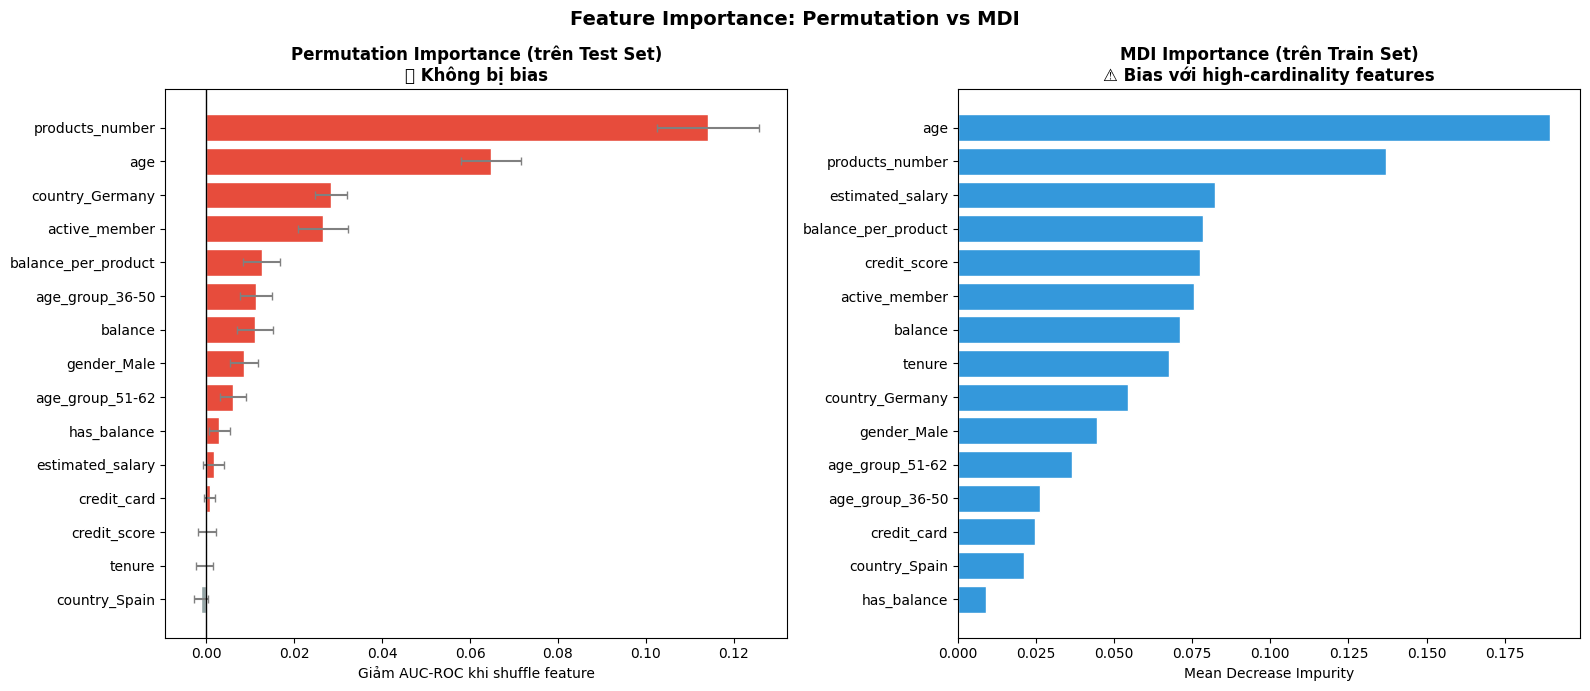

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance: Permutation vs MDI', fontsize=14, fontweight='bold')

# --- Plot 1: Permutation Importance ---
perm_plot = perm_df.head(15)  # Top 15
colors_perm = ['#e74c3c' if v > 0 else '#95a5a6'
               for v in perm_plot['Importance Mean']]

axes[0].barh(
    perm_plot['Feature'][::-1],
    perm_plot['Importance Mean'][::-1],
    xerr=perm_plot['Importance Std'][::-1],
    color=colors_perm[::-1],
    edgecolor='white',
    error_kw={'ecolor': 'gray', 'capsize': 3}
)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Permutation Importance (trên Test Set)\n✅ Không bị bias', fontweight='bold')
axes[0].set_xlabel('Giảm AUC-ROC khi shuffle feature')

# --- Plot 2: MDI Importance ---
mdi_plot = mdi_df.head(15)
axes[1].barh(
    mdi_plot['Feature'][::-1],
    mdi_plot['MDI'][::-1],
    color='#3498db',
    edgecolor='white'
)
axes[1].set_title('MDI Importance (trên Train Set)\n⚠️ Bias với high-cardinality features', fontweight='bold')
axes[1].set_xlabel('Mean Decrease Impurity')

plt.tight_layout()
plt.show()

**NHẬN XÉT:**
1. MDI thường đánh giá cao các biến numeric liên tục (balance, age, estimated_salary) do chúng có nhiều điểm split hơn → tạo ảo giác quan trọng hơn thực tế
2. Permutation Importance phản ánh đúng hơn vì đo trực tiếp impact lên performance
3. Feature có Importance Mean ≤ 0: shuffle xong performance không giảm (hoặc tăng nhẹ do noise) → feature đó gần như không đóng góp vào model

### b. Business insights từ permutation importance

In [ ]:
top5 = perm_df.head(5)

In [ ]:
business_meaning = {
    'age'                 : 'Tuổi KH — nhóm trung niên 36–62 có nguy cơ churn cao nhất',
    'active_member'       : 'Mức độ hoạt động — KH inactive là dấu hiệu cảnh báo sớm',
    'balance'             : 'Số dư tài khoản — KH có tiền gửi dễ churn hơn (có thứ để mang đi)',
    'has_balance'         : 'Flag có/không có tiền gửi — phân biệt 2 hành vi hoàn toàn khác nhau',
    'products_number'     : 'Số sản phẩm — KH dùng 3-4 sản phẩm có churn rate bất thường cao',
    'country_Germany'     : 'KH tại Germany — churn rate cao gấp đôi France và Spain',
    'gender_Male'         : 'Giới tính — Female có xu hướng churn cao hơn Male',
    'credit_score'        : 'Điểm tín dụng — tương quan yếu với churn',
    'estimated_salary'    : 'Lương ước tính — phân phối đều, ít phân biệt churn',
    'balance_per_product' : 'Số dư bình quân mỗi sản phẩm',
    'tenure'              : 'Số năm gắn bó — KH lâu năm ít churn hơn',
    'credit_card'         : 'Có thẻ tín dụng — ảnh hưởng nhỏ đến churn',
    'age_group_36-50'     : 'Nhóm tuổi 36-50 — nhóm churn nhiều nhất',
    'age_group_51-62'     : 'Nhóm tuổi 51-62 — bắt đầu ổn định hơn',
    'age_group_62+'       : 'Nhóm >62 tuổi — xu hướng ở lại cao hơn'
}

print('=== Top 5 Features Quan Trọng Nhất (Permutation Importance) ===')
print()
for rank, (_, row) in enumerate(top5.iterrows(), 1):
    feature = row['Feature']
    meaning = business_meaning.get(feature, 'Xem thêm trong phân tích')
    print(f'  #{rank} {feature:<25} (Importance: {row["Importance Mean"]:.4f} ± {row["Importance Std"]:.4f})')
    print(f'     → {meaning}')
    print()

=== Top 5 Features Quan Trọng Nhất (Permutation Importance) ===

  #1 products_number           (Importance: 0.1142 ± 0.0116)
     → Số sản phẩm — KH dùng 3-4 sản phẩm có churn rate bất thường cao

  #2 age                       (Importance: 0.0648 ± 0.0068)
     → Tuổi KH — nhóm trung niên 36–62 có nguy cơ churn cao nhất

  #3 country_Germany           (Importance: 0.0285 ± 0.0036)
     → KH tại Germany — churn rate cao gấp đôi France và Spain

  #4 active_member             (Importance: 0.0266 ± 0.0058)
     → Mức độ hoạt động — KH inactive là dấu hiệu cảnh báo sớm

  #5 balance_per_product       (Importance: 0.0126 ± 0.0041)
     → Số dư bình quân mỗi sản phẩm



## **Tổng kết Fine tuning**

In [ ]:
# Tính metrics ở 3 giai đoạn
y_pred_05_base    = (y_proba_base  >= 0.5).astype(int)
y_pred_05_tuned   = (y_proba_tuned >= 0.5).astype(int)
y_pred_opt_tuned  = (y_proba_tuned >= optimal_threshold).astype(int)

summary = pd.DataFrame({
    'RF Baseline (threshold=0.5)': {
        'AUC-ROC'  : roc_auc_score(y_test, y_proba_base),
        'Recall'   : recall_score(y_test, y_pred_05_base),
        'Precision': precision_score(y_test, y_pred_05_base),
        'F1'       : f1_score(y_test, y_pred_05_base)
    },
    f'RF Tuned (threshold=0.5)': {
        'AUC-ROC'  : roc_auc_score(y_test, y_proba_tuned),
        'Recall'   : recall_score(y_test, y_pred_05_tuned),
        'Precision': precision_score(y_test, y_pred_05_tuned),
        'F1'       : f1_score(y_test, y_pred_05_tuned)
    },
    f'RF Tuned (threshold={optimal_threshold:.2f})': {
        'AUC-ROC'  : roc_auc_score(y_test, y_proba_tuned),  # AUC không đổi theo threshold
        'Recall'   : recall_score(y_test, y_pred_opt_tuned),
        'Precision': precision_score(y_test, y_pred_opt_tuned),
        'F1'       : f1_score(y_test, y_pred_opt_tuned)
    }
}).T

print('=== Tổng kết cải thiện qua từng bước ===')
print(summary.round(4).to_string())

=== Tổng kết cải thiện qua từng bước ===
                             AUC-ROC  Recall  Precision      F1
RF Baseline (threshold=0.5)   0.8497  0.5774     0.6492  0.6112
RF Tuned (threshold=0.5)      0.8517  0.5700     0.6554  0.6097
RF Tuned (threshold=0.33)     0.8517  0.7248     0.5043  0.5948


In [ ]:
# Objects sử dụng cho bước 7
print(f'  rf_tuned           : model Random Forest đã tune')
print(f'  optimal_threshold  : {optimal_threshold:.4f}')
print(f'  y_pred_opt_tuned   : predictions với optimal threshold')
print(f'  y_proba_tuned      : xác suất churn từ RF Tuned')
print(f'  perm_df            : Permutation Importance results')

  rf_tuned           : model Random Forest đã tune
  optimal_threshold  : 0.3333
  y_pred_opt_tuned   : predictions với optimal threshold
  y_proba_tuned      : xác suất churn từ RF Tuned
  perm_df            : Permutation Importance results


# **7. Post-prediction Clustering & Business insights**

## **7.1 Tạo result_df - ghép customer_id với kết quả predict**
Dùng test_index (lưu từ phần 3) để ghép đúng KH với đúng xác suất — không bị lệch thứ tự

In [ ]:
# Predict với optimal threshold từ phần 6
y_pred_final  = (y_proba_tuned >= optimal_threshold).astype(int)

In [ ]:
# Lấy customer_id theo đúng index của test set
customer_ids_test = df_model.loc[test_index, 'customer_id'].values

In [ ]:
# Lấy features gốc (chưa scale) của test set để phân tích profile
# Dùng df_model (có feature engineering) theo test_index
X_test_original = df_model.loc[test_index].drop(columns=['churn', 'customer_id'])

In [ ]:
# Tạo result_df
result_df = pd.DataFrame({
    'customer_id'      : customer_ids_test,
    'churn_actual'     : y_test.values,
    'churn_predicted'  : y_pred_final,
    'churn_probability': y_proba_tuned.round(4)
})
result_df.head()

,customer_id,churn_actual,churn_predicted,churn_probability
0,15749540,0,0,0.0233
1,15807340,0,0,0.0433
2,15801062,0,0,0.1000
3,15572801,0,0,0.0300
4,15600708,0,0,0.1033


In [ ]:
# Ghép thêm features gốc vào result_df
result_df = pd.concat(
    [result_df.reset_index(drop=True),
     X_test_original.reset_index(drop=True)],
    axis=1
)
result_df.head()

,customer_id,churn_actual,churn_predicted,churn_probability,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,has_balance,age_group,balance_per_product
0,15749540,0,0,0.0233,585,France,Male,36,7,0.00,2,1,0,94283.09,0,36-50,0.000
1,15807340,0,0,0.0433,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,1,18-35,65511.880
2,15801062,0,0,0.1000,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0,36-50,0.000
3,15572801,0,0,0.0300,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,1,18-35,69696.595
4,15600708,0,0,0.1033,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,1,18-35,77826.800


In [ ]:
print(f'result_df shape: {result_df.shape}')
print(f'\nPhân phối predicted churn:')
print(f'  Predicted Ở lại (0): {(result_df["churn_predicted"]==0).sum():,}')
print(f'  Predicted Churn (1) : {(result_df["churn_predicted"]==1).sum():,}')
print(f'\nTop 5 KH có xác suất churn cao nhất:')
print(result_df.nlargest(5, 'churn_probability')[[
    'customer_id', 'churn_actual', 'churn_predicted', 'churn_probability'
]])

result_df shape: (2000, 17)

Phân phối predicted churn:
  Predicted Ở lại (0): 1,415
  Predicted Churn (1) : 585

Top 5 KH có xác suất churn cao nhất:
      customer_id  churn_actual  churn_predicted  churn_probability
232      15704583             1                1             0.9933
1174     15707637             1                1             0.9900
860      15634551             1                1             0.9800
920      15712551             1                1             0.9800
1624     15806049             0                1             0.9800


## **7.2 Cluster nhóm predicted churn = 1**

### a. Lọc churn = 1 và chọn các features clustering

In [ ]:
# Lọc nhóm predicted churn=1 để cluster
churn_predicted_df = result_df[result_df['churn_predicted'] == 1].copy() # Thực hiện trên bản sao result_df

print(f'Số KH predicted churn: {len(churn_predicted_df):,}')
print(f'Tỷ lệ so với test set: {len(churn_predicted_df)/len(result_df)*100:.1f}%')

Số KH predicted churn: 585
Tỷ lệ so với test set: 29.2%


In [ ]:
# Chọn features để clustering
  ## Lý do: dùng features gốc (chưa scale) để dễ interpret profile sau
  ## Chỉ dùng numeric features — không dùng binary/categorical
  ## vì KMeans dựa vào khoảng cách Euclidean, nhạy cảm với scale
cluster_features = [
    'age', 'credit_score', 'balance', 'tenure',
    'estimated_salary', 'products_number', 'active_member'
]

X_cluster = churn_predicted_df[cluster_features].copy()
X_cluster.head()

,age,credit_score,balance,tenure,estimated_salary,products_number,active_member
8,49,505,80001.23,7,135180.11,1,0
10,54,699,111009.32,3,155905.79,1,1
18,58,617,119024.75,3,35199.24,2,0
19,35,572,139979.07,1,185662.84,1,0
20,52,551,0.00,1,63584.55,1,0


In [ ]:
# Scale về [0,1] trước khi clustering
    ## Lý do: balance (0-200k) sẽ dominate khoảng cách nếu không scale
    # MinMaxScaler thay vì StandardScaler vì KMeans không cần
    # phân phối chuẩn, chỉ cần đưa về cùng scale
minmax = MinMaxScaler()
X_cluster_scaled = minmax.fit_transform(X_cluster)

print(f'\nFeatures dùng để clustering: {cluster_features}')


Features dùng để clustering: ['age', 'credit_score', 'balance', 'tenure', 'estimated_salary', 'products_number', 'active_member']


### b. Chọn số cluster K tối ưu
**Dùng 2 phương pháp kết hợp:**
1. Elbow Method (Inertia): tìm điểm "khuỷu tay" — điểm mà thêm cluster không còn giảm inertia đáng kể
2. Silhouette Score: đo mức độ "gọn" của cluster Score = 1: cluster rất tốt, -1: cluster rất tệ → Chọn K có Silhouette Score cao nhất

In [ ]:
K_range     = range(2, 9)
inertias    = []
silhouettes = []

print('Đang tính Elbow + Silhouette cho K = 2 đến 8...')

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))
    print(f'  K={k}: Inertia={km.inertia_:.0f} | Silhouette={silhouettes[-1]:.4f}')

Đang tính Elbow + Silhouette cho K = 2 đến 8...
  K=2: Inertia=202 | Silhouette=0.3875
  K=3: Inertia=179 | Silhouette=0.2454
  K=4: Inertia=163 | Silhouette=0.1837
  K=5: Inertia=149 | Silhouette=0.1819
  K=6: Inertia=139 | Silhouette=0.1789
  K=7: Inertia=128 | Silhouette=0.1964
  K=8: Inertia=119 | Silhouette=0.1976


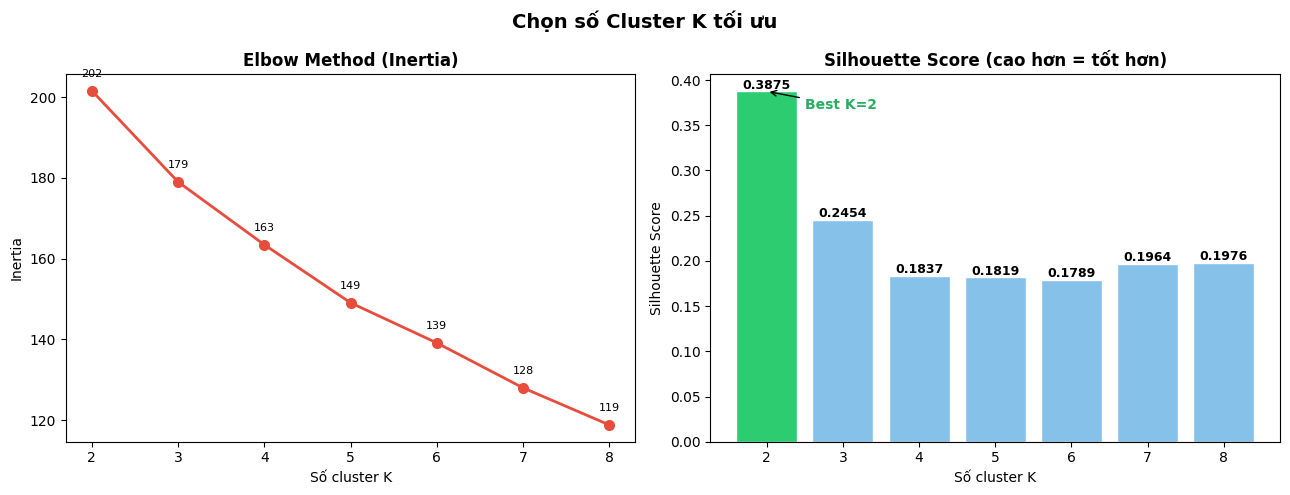


✅ K tối ưu theo Silhouette Score: K = 2


In [ ]:
# Vẽ
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chọn số Cluster K tối ưu', fontsize=14, fontweight='bold')

# Elbow
axes[0].plot(list(K_range), inertias, 'o-', color='#e74c3c',
             linewidth=2, markersize=7)
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Số cluster K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))
for k, v in zip(K_range, inertias):
    axes[0].annotate(f'{v:.0f}', (k, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=8)

# Silhouette
bars = axes[1].bar(list(K_range), silhouettes,
                   color=['#2ecc71' if s == max(silhouettes) else '#85c1e9'
                          for s in silhouettes],
                   edgecolor='white')
axes[1].set_title('Silhouette Score (cao hơn = tốt hơn)', fontweight='bold')
axes[1].set_xlabel('Số cluster K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
for bar, v in zip(bars, silhouettes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

  # Chọn best K theo silhouette
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].annotate(f'Best K={best_k}', xy=(best_k, max(silhouettes)),
                 xytext=(best_k + 0.5, max(silhouettes) - 0.02),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10, fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.show()

print(f'\n✅ K tối ưu theo Silhouette Score: K = {best_k}')

Fit KMeans với K tối ưu

In [ ]:
# Fit KMeans với K tối ưu
FINAL_K = best_k # Có thể thay đổi; ĐÃ THỬ K=3 NHƯNG KHÔNG CÓ SỰ PHÂN BIỆT RÕ RÀNG HƠN GIỮA CÁC CLUSTER -> SỬ DỤNG BEST K = 2

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)   # n_init=20: chạy 20 lần với centroid khởi tạo khác nhau
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

In [ ]:
# Gán cluster label vào churn_predicted_df
churn_predicted_df['cluster'] = cluster_labels

In [ ]:
# Gán ngược lại vào result_df
result_df['cluster'] = -1  # -1 = không thuộc nhóm predicted churn
result_df.loc[result_df['churn_predicted'] == 1, 'cluster'] = cluster_labels

In [ ]:
print(f'KMeans với K={FINAL_K} đã được fit!')
print(f'\nPhân phối cluster:')
cluster_counts = churn_predicted_df['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f'  Cluster {cluster_id}: {count:,} KH ({count/len(churn_predicted_df)*100:.1f}%)')

KMeans với K=2 đã được fit!

Phân phối cluster:
  Cluster 0: 362 KH (61.9%)
  Cluster 1: 223 KH (38.1%)


## **7.3 Phân tích profile từng cluster**

### a. Tính profile trung bình từng cluster

In [ ]:
# Tính profile trung bình từng cluster
profile_features = [
    'age', 'credit_score', 'balance', 'tenure',
    'estimated_salary', 'products_number', 'active_member',
    'has_balance', 'churn_probability'
]

# Profile trung bình của từng cluster
cluster_profile = churn_predicted_df.groupby('cluster')[profile_features].mean()
cluster_profile

,age,credit_score,balance,tenure,estimated_salary,products_number,active_member,has_balance,churn_probability
cluster,,,,,,,,,
0,44.223757,643.118785,95067.720994,4.933702,104878.605856,1.364641,0.0,0.770718,0.641454
1,46.246637,650.201794,92115.401704,4.704036,98313.973901,1.443946,1.0,0.784753,0.542376


### b. Thêm thông tin

In [ ]:
# Thêm hàng Overall (toàn bộ predicted churn)
overall = churn_predicted_df[profile_features].mean()
overall.name = 'Overall (predicted churn)'
cluster_profile = pd.concat([cluster_profile, overall.to_frame().T])

print('=== Profile trung bình từng Cluster (Predicted Churn = 1) ===')
cluster_profile.round(2)

=== Profile trung bình từng Cluster (Predicted Churn = 1) ===


,age,credit_score,balance,tenure,estimated_salary,products_number,active_member,has_balance,churn_probability
0,44.22,643.12,95067.72,4.93,104878.61,1.36,0.00,0.77,0.64
1,46.25,650.20,92115.40,4.70,98313.97,1.44,1.00,0.78,0.54
Overall (predicted churn),44.99,645.82,93942.31,4.85,102376.19,1.39,0.38,0.78,0.60


In [ ]:
# Thêm thông tin categorical
print('\n=== Tỷ lệ Country và Gender theo Cluster ===')
for c in range(FINAL_K):
    sub = churn_predicted_df[churn_predicted_df['cluster'] == c]
    country_pct = sub['country'].value_counts(normalize=True).mul(100).round(1)
    gender_pct  = sub['gender'].value_counts(normalize=True).mul(100).round(1)
    print(f'\nCluster {c} (n={len(sub):,}):')
    print(f'  Country: {country_pct.to_dict()}')
    print(f'  Gender : {gender_pct.to_dict()}')


=== Tỷ lệ Country và Gender theo Cluster ===

Cluster 0 (n=362):
  Country: {'France': 41.4, 'Germany': 40.1, 'Spain': 18.5}
  Gender : {'Female': 52.8, 'Male': 47.2}

Cluster 1 (n=223):
  Country: {'Germany': 45.7, 'France': 37.2, 'Spain': 17.0}
  Gender : {'Female': 62.8, 'Male': 37.2}


### c. Visualize profile cluster

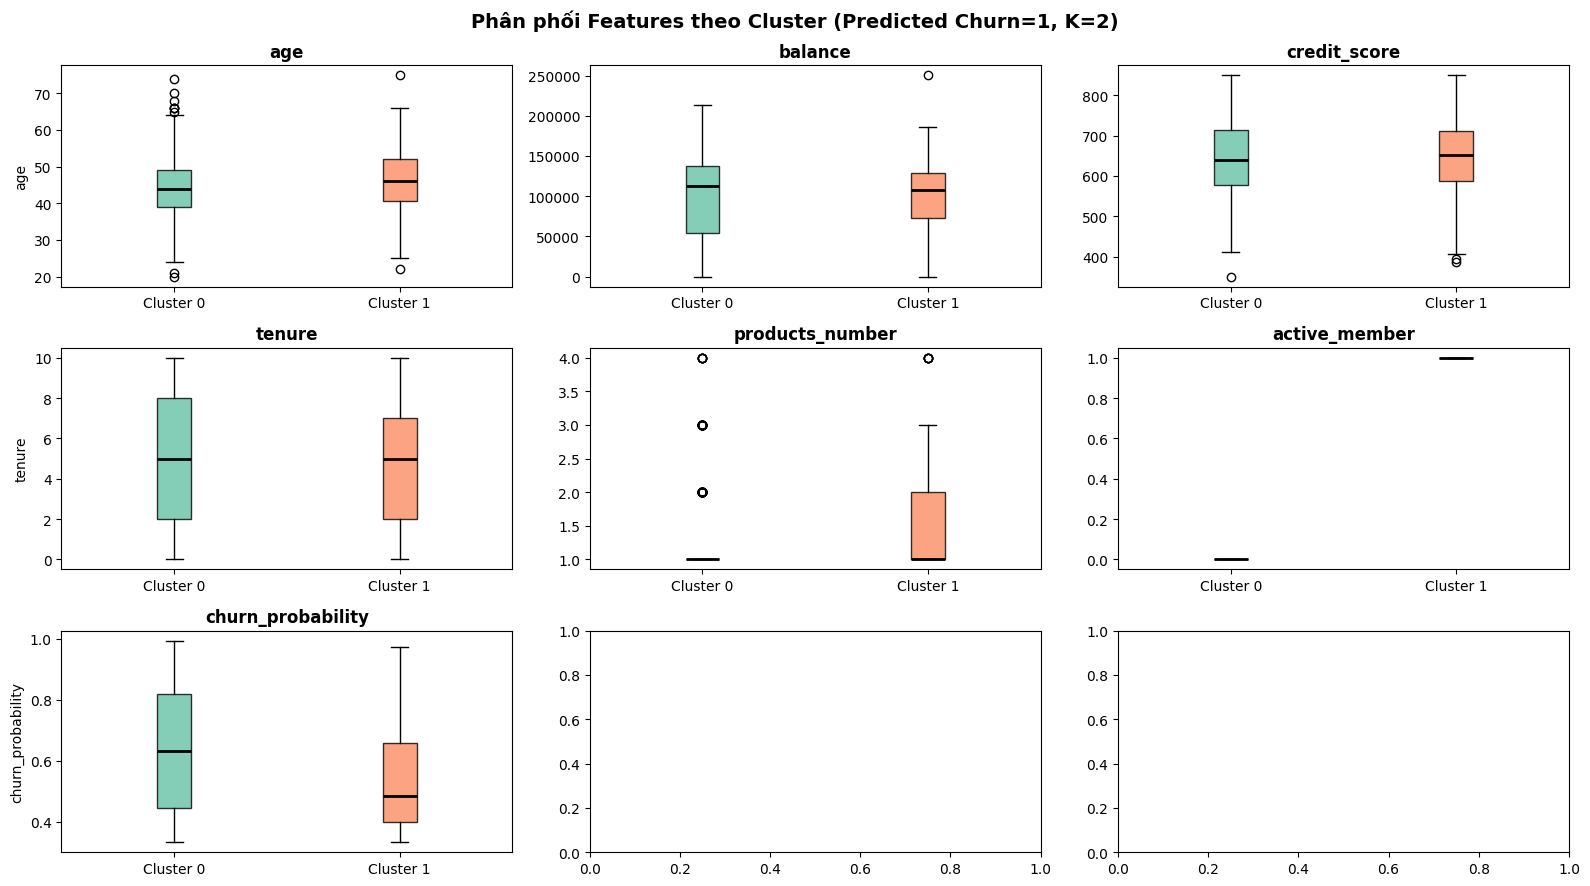

In [ ]:
# Vẽ boxplot xem phân phối của từng cluster
viz_features = ['age', 'balance', 'credit_score', 'tenure',
                'products_number', 'active_member', 'churn_probability']

fig, axes = plt.subplots(3, 3, figsize=(16, 9))
fig.suptitle(f'Phân phối Features theo Cluster (Predicted Churn=1, K={FINAL_K})',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

palette = sns.color_palette('Set2', FINAL_K)

for i, (ax, feature) in enumerate(zip(axes, viz_features)):
    data_by_cluster = [
        churn_predicted_df[churn_predicted_df['cluster'] == c][feature].values
        for c in range(FINAL_K)
    ]

    bp = ax.boxplot(
        data_by_cluster,
        patch_artist=True,
        labels=[f'Cluster {c}' for c in range(FINAL_K)],
        medianprops=dict(color='black', linewidth=2)
    )

    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_title(feature, fontweight='bold')
    # Only show y-label for the first plot in each row
    if i % 3 == 0:
        ax.set_ylabel(feature)
    else:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()

**NHẬN XÉT:**

**Cluster 0:**
- age:  median = 44; phổ IQR thấp hơn, tập trung chủ yếu ở khoảng 38-48 tuổi (nhóm có nguy cơ churn cao); có nhiều outliers trên (KH lớn tuổi) -> cluster 0 thiên về những KH tuổi trung niên
- balance: median ~ 111k, phổ IQR rộng hơn, và thấp hơn, không có outliers trên -> cluster 0 thiên về những KH có số dư thấp hơn, biến động hơn
- products_number: median = 1, chủ yếu sử dụng 1 sp/dv. Có sử dụng 3-4 sp/dv -> cluster 0 sử dụng ít sp/dv
- credit_score: median = 639, phổ IQR tương đồng với cluster 0 nhưng thấp hơn một xíu, có outliers dưới thấp -> cluster 0 có điểm tín dụng thấp hơn
- tenure: phổ IQR rộng hơn -> cluster 0 gắn bó lâu năm hơn
- **churn_probability** (sự khác biệt rõ ràng nhất): median ~ 0.62, IQR rộng trong khoảng từ 0.45-0.83 -> xác xuất churn từ trung bình đến cao


**Cluster 1:**
- age: median = 46, phổ IQR cao hơn cluster 0; phân phối rộng hơn, chủ yếu từ 41-54 tuổi, ít outliers -> cluster 1 đa dạng tuổi hơn
- balance: median ~ 108k, phổ IQR hẹp và cao hơn cluster 0; phân phối hẹp hơn, và có outliers trên: -> cluster 1 có số dư tài khoản cao đáng kể, ổn định hơn
- products_number: median = 1 nhưng có sử dụng nhiều dịch vụ hơn -> cluster 1 sử dụng đa dạng sp/dv hơn
- credit_score: phân phối gần giống với cluster 0
- tenure: phổ IQR hẹp hơn, gần giống với cluster 0
- **churn_probability** (sự khác biệt rõ ràng nhất): median ~ 0.47, IQR trong khoảng từ 0.4-0.65 -> xác xuất churn thấp hơn hẳn, phân phối tập trung ở vùng thấp



### d. Phân tích country và gender theo cluster

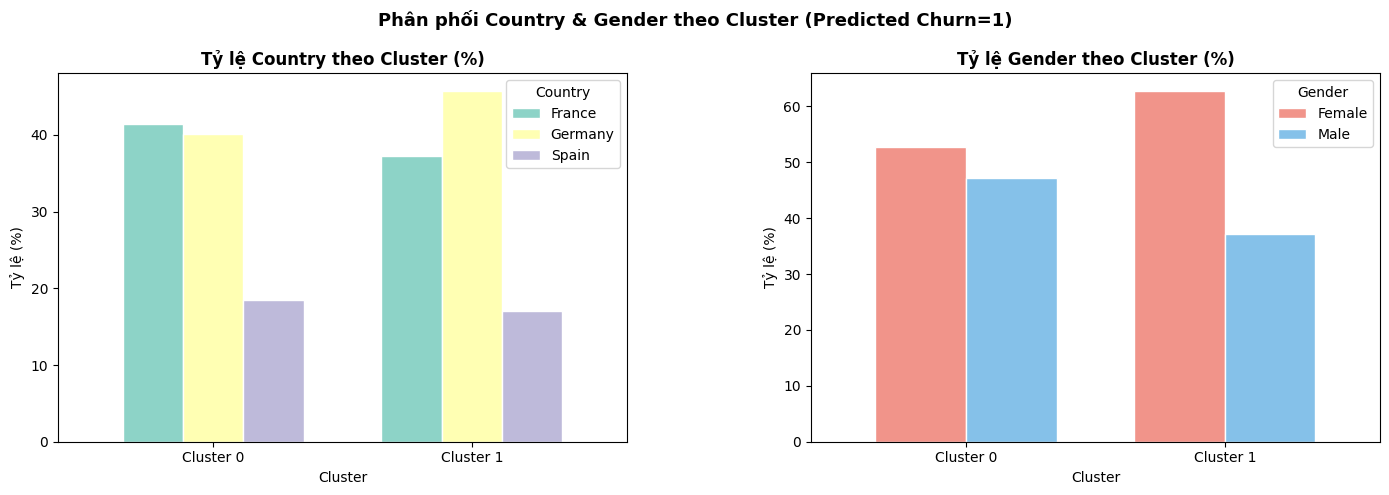

In [ ]:
# Phân tích country và gender theo cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân phối Country & Gender theo Cluster (Predicted Churn=1)',
             fontsize=13, fontweight='bold')

# Country
country_cluster = churn_predicted_df.groupby(['cluster', 'country']).size().unstack(fill_value=0)
country_cluster_pct = country_cluster.div(country_cluster.sum(axis=1), axis=0) * 100
country_cluster_pct.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set3', 3),
                          edgecolor='white', width=0.7)
axes[0].set_title('Tỷ lệ Country theo Cluster (%)', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].set_xticklabels([f'Cluster {c}' for c in range(FINAL_K)], rotation=0)
axes[0].legend(title='Country', bbox_to_anchor=(1, 1))

# Gender
gender_cluster = churn_predicted_df.groupby(['cluster', 'gender']).size().unstack(fill_value=0)
gender_cluster_pct = gender_cluster.div(gender_cluster.sum(axis=1), axis=0) * 100
gender_cluster_pct.plot(kind='bar', ax=axes[1],
                         color=['#f1948a', '#85c1e9'],
                         edgecolor='white', width=0.7)
axes[1].set_title('Tỷ lệ Gender theo Cluster (%)', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_xticklabels([f'Cluster {c}' for c in range(FINAL_K)], rotation=0)
axes[1].legend(title='Gender', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

**NHẬN XÉT:**
1. **country**:
- cả 2 cluster đều có tỷ lệ KH từ Germany rất cao, trong khi thực tế số lượng KH từ Germany tương đương với Spain (chỉ chiếm 25% tổng dataset) -> Reconfirm KH Germany có churn rate cao nhất
- Tuy nhiên, không phải tất cả các KH đến từ Germany sẽ churn. Bằng chứng ở cluster 1 cỏ churn probability thấp hơn nhưng KH Germany lại chiếm 40%.

2. **gender**:
- cluster 0: tỷ lệ giới tính giá cân bằng
- cluster 1: Female áp đảo rõ rệt

-> *Có sự counterintuitive khi cluster 1 có churn probability thấp hơn nhưng nhiều Female hơn*.

Điều này có thể giải thích bằng việc **model đã học tốt**: mặc dù cluster 1 có nhiều Female hơn nhưng họ có những đặc điểm khác (trẻ hơn, tenure ngắn hơn, balance biến động hơn hoặc không còn hoạt động) khiến model đánh giá xác suất churn của họ thấp hơn cluster 0.\
-> **gender không phải là yếu tố quyết định một mình**


## **7.4 Radar chart so sánh các cluster**

### a. Normalize [0,1] trước khi vẽ chart
Lý do normalize về [0,1] trước khi vẽ:
- Các features có đơn vị khác nhau (age: 18-92, balance: 0-200k) -> Cần normalize để biểu đồ có ý nghĩa và so sánh được

In [ ]:
# Chọn các feature cho radar chart
radar_features = ['age', 'credit_score', 'balance',
                  'tenure', 'products_number', 'active_member']

In [ ]:
# Normalize về [0,1] dựa trên toàn bộ predicted churn group
radar_df = churn_predicted_df.groupby('cluster')[radar_features].mean()
radar_normalized = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

### b. Radar chart

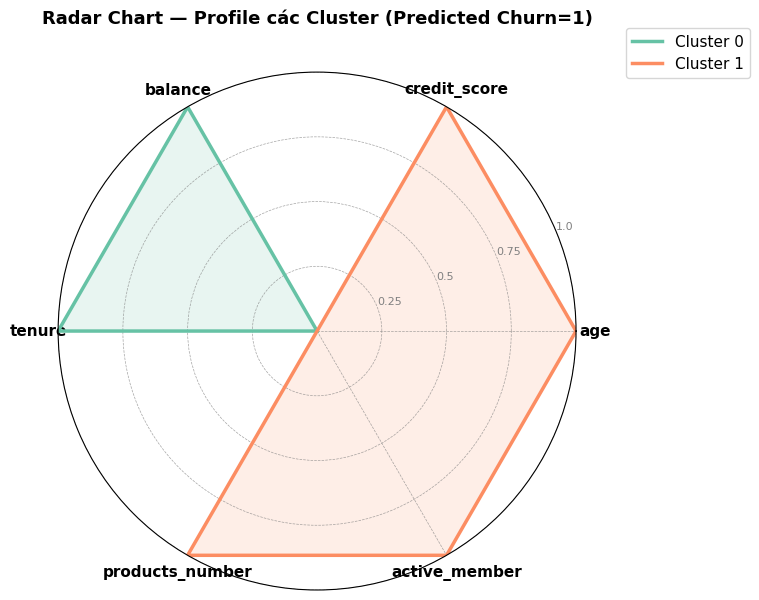

In [ ]:
# Vẽ Radar Chart
N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Đóng vòng tròn

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = sns.color_palette('Set2', FINAL_K)

for cluster_id in range(FINAL_K):
    values = radar_normalized.loc[cluster_id].tolist()
    values += values[:1]  # Đóng vòng tròn

    ax.plot(angles, values, color=colors[cluster_id],
            linewidth=2.5, linestyle='solid', label=f'Cluster {cluster_id}')
    ax.fill(angles, values, color=colors[cluster_id], alpha=0.15)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8, color='gray')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.set_title(f'Radar Chart — Profile các Cluster (Predicted Churn=1)\n',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

**NHẬN XÉT RADAR CHART:**

**Cluster 0:**
- Đặc điểm:
1. Phình to ở các features balance và tenure
2. Co lại ở các features products_number, active_member, credit_score và age (các đặc điểm khó phân biệt được cluster 0)

=> Cluster 0 được định nghĩa là nhóm KH có số dư tài khoản lớn, và là những KH gắn bó lâu năm (đặc điểm phình to)

**Cluster 1:**
- Đặc điểm:
1. Phình to ở các features products_number, active_member, credit_score và age
2. Co lại ở các features balance và tenure

=> Cluster 1 được định nghĩa là nhóm KH có độ tuổi cao hơn, có điểm tín dụng cao hơn và hoạt động hơn (đặc điểm phình to) nhưng ít tiền gửi hơn và là KH gắn bó ngắn hơn



## **7.5 Business Recommendation**

### a. Đặt tên cluster dựa theo profile

In [ ]:
cluster_names = {
    0: '💰 Nhóm Tài Sản Cao - Inactive',       # Balance cao, tenure cao
    1: '👴 Nhóm Trung Niên - Active', # Tuổi cao, active
}

In [ ]:
# Đặt tên
for c in range(FINAL_K):
    sub    = churn_predicted_df[churn_predicted_df['cluster'] == c]
    name   = cluster_names.get(c, f'Cluster {c}')
    n      = len(sub)
    pct    = n / len(churn_predicted_df) * 100

    print(f'{'='*55}')
    print(f'Cluster {c} — {name}')
    print(f'Số lượng: {n:,} KH ({pct:.1f}% nhóm predicted churn)')
    print(f'-'*55)
    print(f'  Tuổi trung bình      : {sub["age"].mean():.1f}')
    print(f'  Balance trung bình   : {sub["balance"].mean():,.0f}')
    print(f'  Credit Score TB      : {sub["credit_score"].mean():.0f}')
    print(f'  Tenure trung bình    : {sub["tenure"].mean():.1f} năm')
    print(f'  Tỷ lệ Active Member  : {sub["active_member"].mean()*100:.1f}%')
    print(f'  Tỷ lệ có Balance     : {sub["has_balance"].mean()*100:.1f}%')
    print(f'  Products TB          : {sub["products_number"].mean():.2f}')
    top_country = sub['country'].value_counts().index[0]
    top_gender  = sub['gender'].value_counts().index[0]
    print(f'  Country nhiều nhất   : {top_country}')
    print(f'  Gender nhiều nhất    : {top_gender}')
    print(f'  Xác suất churn TB    : {sub["churn_probability"].mean():.4f}')
    print()

Cluster 0 — 💰 Nhóm Tài Sản Cao - Inactive
Số lượng: 362 KH (61.9% nhóm predicted churn)
-------------------------------------------------------
  Tuổi trung bình      : 44.2
  Balance trung bình   : 95,068
  Credit Score TB      : 643
  Tenure trung bình    : 4.9 năm
  Tỷ lệ Active Member  : 0.0%
  Tỷ lệ có Balance     : 77.1%
  Products TB          : 1.36
  Country nhiều nhất   : France
  Gender nhiều nhất    : Female
  Xác suất churn TB    : 0.6415

Cluster 1 — 👴 Nhóm Trung Niên - Active
Số lượng: 223 KH (38.1% nhóm predicted churn)
-------------------------------------------------------
  Tuổi trung bình      : 46.2
  Balance trung bình   : 92,115
  Credit Score TB      : 650
  Tenure trung bình    : 4.7 năm
  Tỷ lệ Active Member  : 100.0%
  Tỷ lệ có Balance     : 78.5%
  Products TB          : 1.44
  Country nhiều nhất   : Germany
  Gender nhiều nhất    : Female
  Xác suất churn TB    : 0.5424



### b. Business recommendation

In [ ]:
recommendations = {
    0: {
        'name'   : cluster_names.get(0, 'Cluster 0'),
        'risk'   : '🔴 Rủi ro CAO',
        'insight': (
            'Nhóm có balance lớn nhưng mức độ active thấp. '
            'Đây là nhóm có "thứ để mang đi" và đang dần rút lui. '
            'Từ EDA: KH có tiền gửi cao là mục tiêu của các ngân hàng cạnh tranh.'
        ),
        'actions': [
            'Chương trình lãi suất tiền gửi ưu đãi cá nhân hóa',
            'Gọi điện tư vấn tài chính chủ động từ Relationship Manager',
            'Mời tham gia gói khách hàng VIP / Priority Banking',
            'Gửi báo cáo tài chính cá nhân hàng tháng để tăng engagement -> thúc đẩy active'
        ]
    },
    1: {
        'name'   : cluster_names.get(1, 'Cluster 1'),
        'risk'   : '🟠 Rủi ro TRUNG BÌNH - CAO',
        'insight': (
            'Nhóm trung niên đến cao tuổi, tài khoản hoạt động nhiều. '
            'Từ EDA: median tuổi nhóm churn ~45 cao hơn nhóm ở lại ~36. '
        ),
        'actions': [
            'Workshop tài chính cá nhân cho nhóm khách hàng trung niên',
            'Khảo sát NPS để hiểu lý do cụ thể tại thị trường Đức',
            'Giới thiệu sản phẩm phù hợp lứa tuổi: quỹ hưu trí, bảo hiểm nhân thọ',
            'Ưu đãi cross-sell sản phẩm mới (đầu tư, bảo hiểm xe) với phí thấp',
            'Chương trình loyalty points / cashback cho giao dịch hàng ngày',
            'Ứng dụng mobile banking cải thiện UX — nhóm này digital-native'
        ]
    },
}

print('=' * 65)
print('        BUSINESS RECOMMENDATIONS THEO CLUSTER')
print('=' * 65)

for c in range(FINAL_K):
    if c not in recommendations:
        continue
    rec = recommendations[c]
    print(f'\n📌 Cluster {c} — {rec["name"]} | {rec["risk"]}')
    print(f'   Insight: {rec["insight"]}')
    print(f'   Đề xuất hành động:')
    for i, action in enumerate(rec['actions'], 1):
        print(f'   {i}. {action}')

print(f'\n{"=" * 65}')

        BUSINESS RECOMMENDATIONS THEO CLUSTER

📌 Cluster 0 — 💰 Nhóm Tài Sản Cao - Inactive | 🔴 Rủi ro CAO
   Insight: Nhóm có balance lớn nhưng mức độ active thấp. Đây là nhóm có "thứ để mang đi" và đang dần rút lui. Từ EDA: KH có tiền gửi cao là mục tiêu của các ngân hàng cạnh tranh.
   Đề xuất hành động:
   1. Chương trình lãi suất tiền gửi ưu đãi cá nhân hóa
   2. Gọi điện tư vấn tài chính chủ động từ Relationship Manager
   3. Mời tham gia gói khách hàng VIP / Priority Banking
   4. Gửi báo cáo tài chính cá nhân hàng tháng để tăng engagement -> thúc đẩy active

📌 Cluster 1 — 👴 Nhóm Trung Niên - Active | 🟠 Rủi ro TRUNG BÌNH - CAO
   Insight: Nhóm trung niên đến cao tuổi, tài khoản hoạt động nhiều. Từ EDA: median tuổi nhóm churn ~45 cao hơn nhóm ở lại ~36. 
   Đề xuất hành động:
   1. Workshop tài chính cá nhân cho nhóm khách hàng trung niên
   2. Khảo sát NPS để hiểu lý do cụ thể tại thị trường Đức
   3. Giới thiệu sản phẩm phù hợp lứa tuổi: quỹ hưu trí, bảo hiểm nhân thọ
   4. Ưu đ

# **8. TỔNG KẾT TOÀN BỘ PROJECT**

In [ ]:
final_auc  = roc_auc_score(y_test, y_proba_tuned)
final_rec  = recall_score(y_test, y_pred_final)
final_prec = precision_score(y_test, y_pred_final)
final_f1   = f1_score(y_test, y_pred_final)

n_churn_predicted = (y_pred_final == 1).sum()
n_churn_actual    = y_test.sum()
n_caught          = ((y_pred_final == 1) & (y_test == 1)).sum()

print('=' * 65)
print('         TỔNG KẾT DỰ ÁN — BANK CHURN PREDICTION')
print('=' * 65)

print('\n📊 Model cuối cùng: Random Forest (Tuned)')
print(f'   Threshold tối ưu : {optimal_threshold:.4f}')
print(f'   AUC-ROC          : {final_auc:.4f}')
print(f'   Recall (class 1) : {final_rec:.4f}')
print(f'   Precision        : {final_prec:.4f}')
print(f'   F1-Score         : {final_f1:.4f}')

print(f'\n🎯 Kết quả thực tế trên test set ({len(y_test):,} KH):')
print(f'   KH churn thực tế          : {n_churn_actual:,}')
print(f'   KH model predict là churn : {n_churn_predicted:,}')
print(f'   KH churn được bắt đúng    : {n_caught:,} ({n_caught/n_churn_actual*100:.1f}% của nhóm churn thực tế)')
print(f'   KH churn bị bỏ sót (FN)   : {n_churn_actual - n_caught:,}')

print(f'\n🔍 Post-Prediction Clustering ({FINAL_K} clusters):')
for c in range(FINAL_K):
    sub  = churn_predicted_df[churn_predicted_df['cluster'] == c]
    name = cluster_names.get(c, f'Cluster {c}')
    print(f'   Cluster {c} — {name}: {len(sub):,} KH')

print(f'\n💡 Top 3 Insights chính:')
print(f'   1. Số sản phẩm sử dụng là yếu tố mạnh nhất để dự đoán KH churn')
print(f'   2. KH inactive (active_member=0) là dấu hiệu cảnh báo sớm rõ ràng nhất')
print(f'   3. Germany có churn rate gấp đôi France/Spain — cần chiến lược riêng cho thị trường này')

print(f'\n{"=" * 65}')
print('✅ Project hoàn tất!')

         TỔNG KẾT DỰ ÁN — BANK CHURN PREDICTION

📊 Model cuối cùng: Random Forest (Tuned)
   Threshold tối ưu : 0.3333
   AUC-ROC          : 0.8517
   Recall (class 1) : 0.7248
   Precision        : 0.5043
   F1-Score         : 0.5948

🎯 Kết quả thực tế trên test set (2,000 KH):
   KH churn thực tế          : 407
   KH model predict là churn : 585
   KH churn được bắt đúng    : 295 (72.5% của nhóm churn thực tế)
   KH churn bị bỏ sót (FN)   : 112

🔍 Post-Prediction Clustering (2 clusters):
   Cluster 0 — 💰 Nhóm Tài Sản Cao - Inactive: 362 KH
   Cluster 1 — 👴 Nhóm Trung Niên - Active: 223 KH

💡 Top 3 Insights chính:
   1. Số sản phẩm sử dụng là yếu tố mạnh nhất để dự đoán KH churn
   2. KH inactive (active_member=0) là dấu hiệu cảnh báo sớm rõ ràng nhất
   3. Germany có churn rate gấp đôi France/Spain — cần chiến lược riêng cho thị trường này

✅ Project hoàn tất!
